#### Importations

In [ ]:
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap as lsc
import scipy.cluster.hierarchy as sch
import pytesseract
import easyocr
import numpy as np
import os
import sys
import torch
from torchvision.ops import box_iou
from transformers import AutoModel, AutoTokenizer
from ultralytics import YOLO
import networkx as nx
from sklearn.neighbors import NearestNeighbors
import random
import h5py
from deeplsd.utils.tensor import batch_to_device
from deeplsd.models.deeplsd_inference import DeepLSD
from deeplsd.geometry.viz_2d import plot_images, plot_lines

from scipy.spatial.distance import euclidean

from ipywidgets import Button, HBox, Output, VBox, Label
from IPython.display import display, clear_output

import matplotlib.patches as patches

from scipy.spatial import KDTree

from sklearn.cluster import DBSCAN
import torchvision
import re
import unicodedata
import spacy
import pandas as pd

# CONVERT PDF to IMG

# CONFIG

In [2]:
image_path = '../IMAGES/modified_reference.jpg'
img_original = cv2.imread(image_path)
image_height, image_width, _ = img_original.shape

classes = {
    0: "homme",
    1: "femme",
    2: "homme decede",
    3: "femme decede",
    4: "homme atteint decede",
    5: "femme atteinte decedee",
    6: "homme atteint",
    7: "femme atteinte"
}

# FIGURES DETECTION


0: 608x1280 3 hommes, 4 femmes, 2 homme decedes, 3 femme decedes, 1 femme atteinte decedee, 1 homme atteint, 209.7ms
Speed: 6.3ms preprocess, 209.7ms inference, 0.5ms postprocess per image at shape (1, 3, 608, 1280)


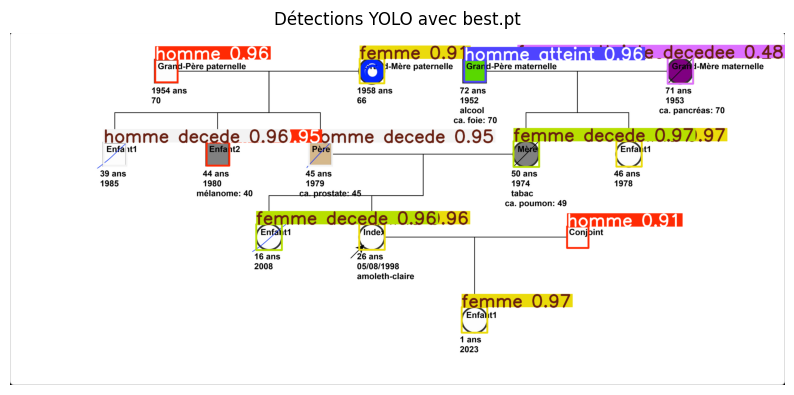

In [3]:
model = YOLO('FiguresDetection/700imgs_300epochs_no_index.pt')
yolo_results = model(img_original)
# visu les prédictions
annotated_img = yolo_results[0].plot()

# l'image avec les prédictions
plt.figure(figsize=(10, 10))
plt.imshow(annotated_img)
plt.title("Détections YOLO avec best.pt")
plt.axis("off")
plt.show()

In [4]:
# pour extraire les bounding boxes (xyxy format) de YOLO
def extraire_bounding_boxes(yolo_results):
    """
    Extrait les bounding boxes des résultats YOLO en format (x_min, y_min, x_max, y_max).
    :param yolo_results: Résultats YOLO.
    :return: Liste des bounding boxes sous forme [(x_min, y_min, x_max, y_max)].
    """
    bounding_boxes = []
    for box in yolo_results[0].boxes.xyxy:  # `xyxy` contient les coordonnées des bounding boxes
        x_min, y_min, x_max, y_max = map(int, box[:4])  # Extraire et convertir en entiers
        bounding_boxes.append((x_min, y_min, x_max, y_max))
    return bounding_boxes

bounding_boxes_yolo = extraire_bounding_boxes(yolo_results)

print(f"Bounding boxes extraites : {bounding_boxes_yolo}")

Bounding boxes extraites : [(3573, 773, 3755, 955), (3205, 1948, 3387, 2129), (4303, 773, 4483, 953), (1747, 1361, 1929, 1544), (1030, 194, 1189, 356), (2478, 1361, 2659, 1542), (3223, 199, 3374, 352), (664, 781, 826, 946), (1395, 783, 1556, 946), (2121, 782, 2285, 946), (2481, 189, 2656, 363), (3953, 1377, 4105, 1529), (4667, 184, 4847, 366), (4667, 185, 4848, 365)]


# TEXT DETECTION

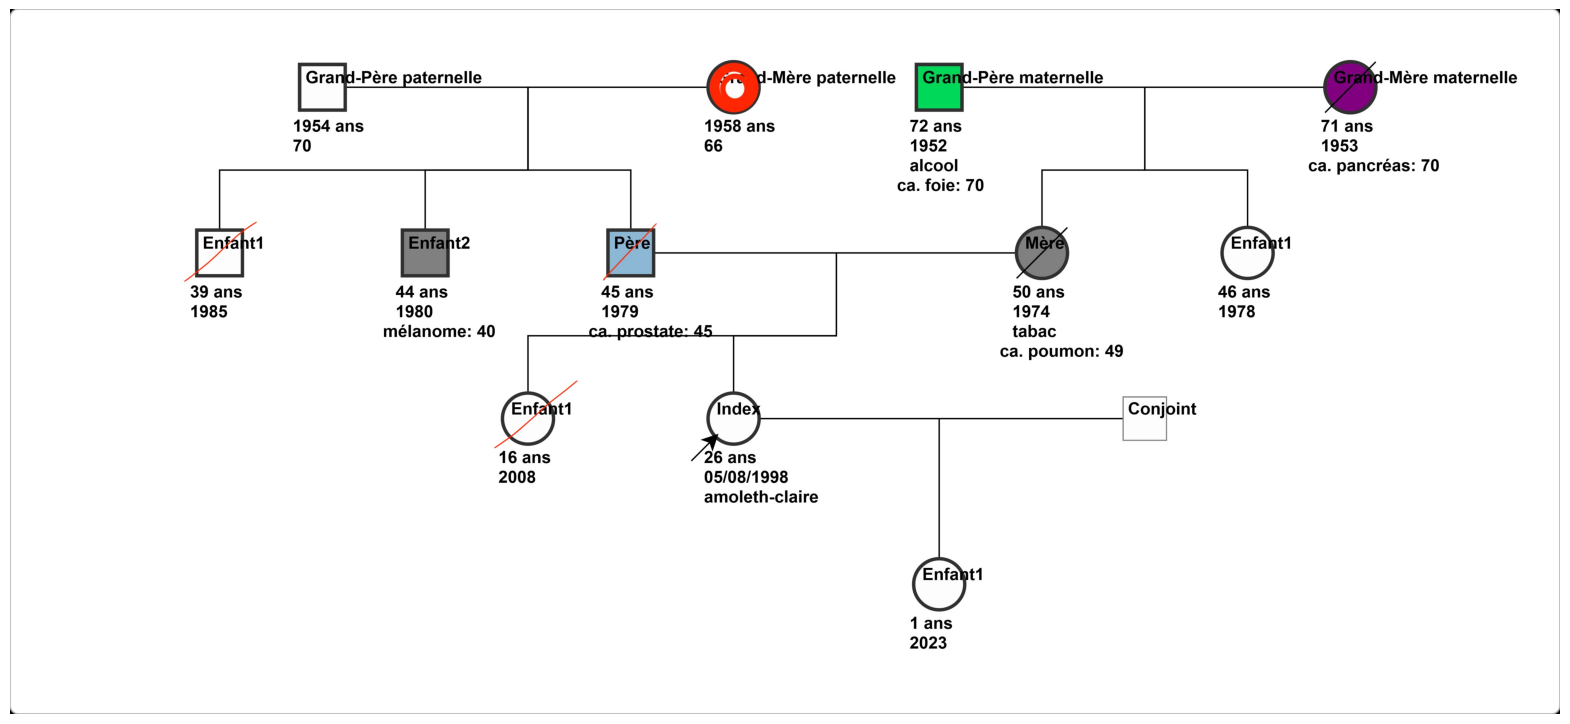

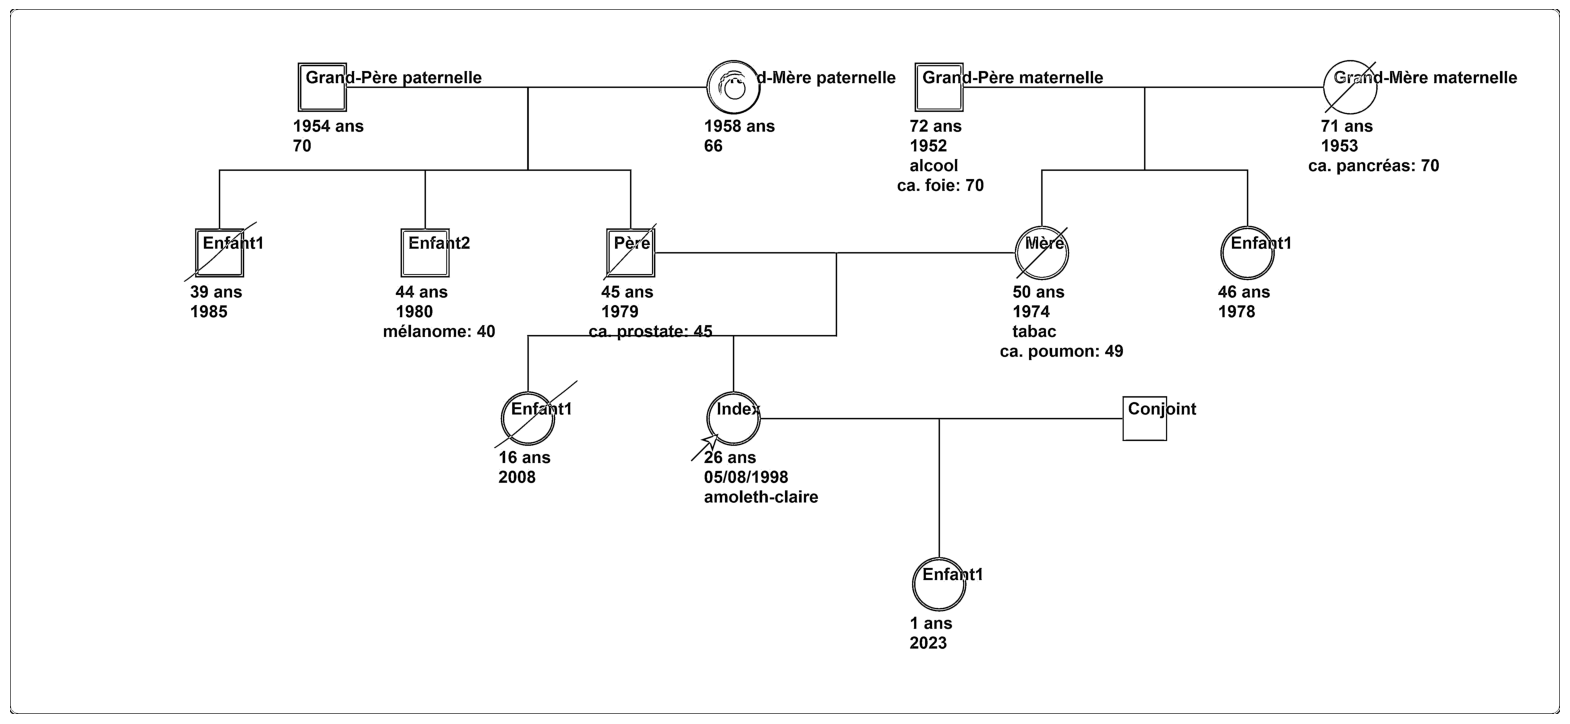

afficher textes détectés : 


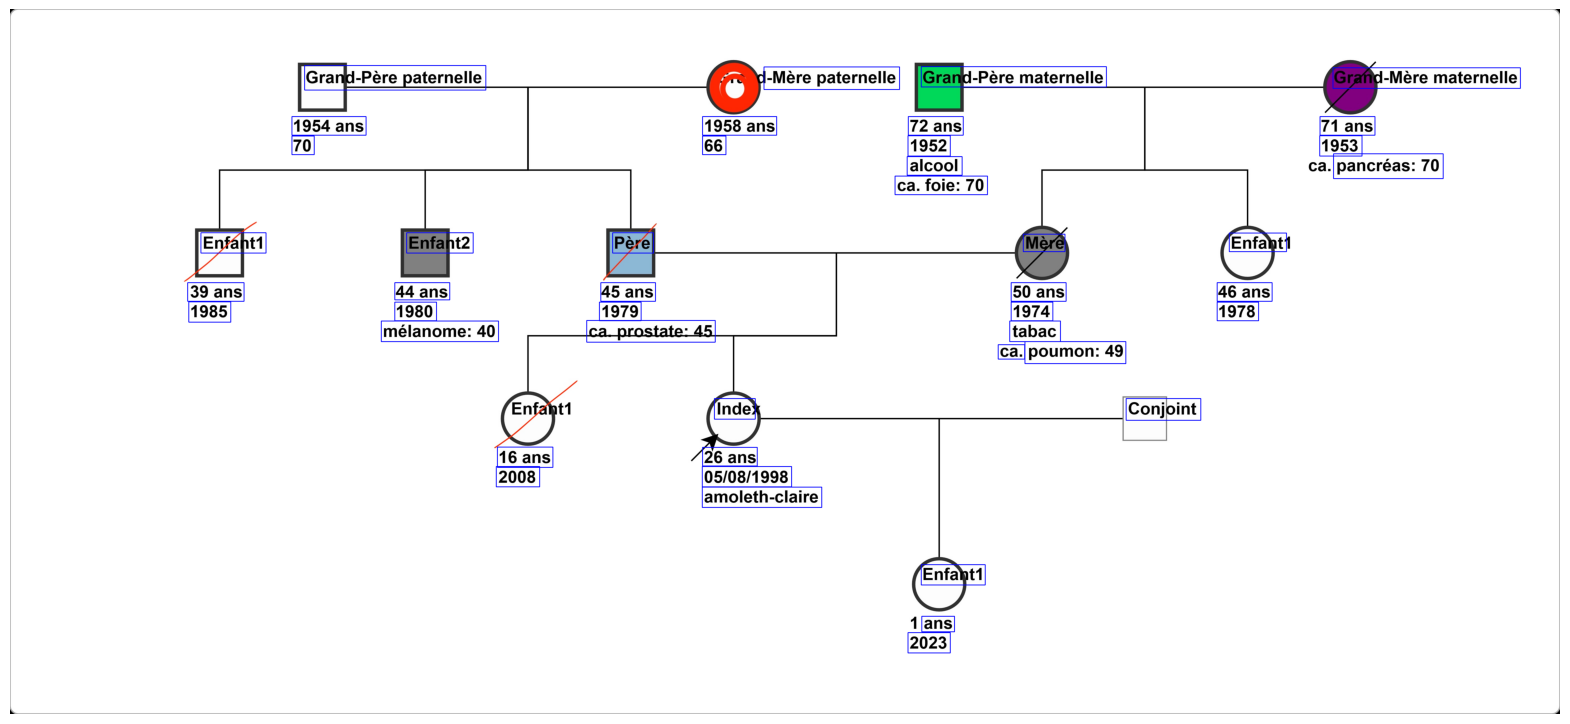

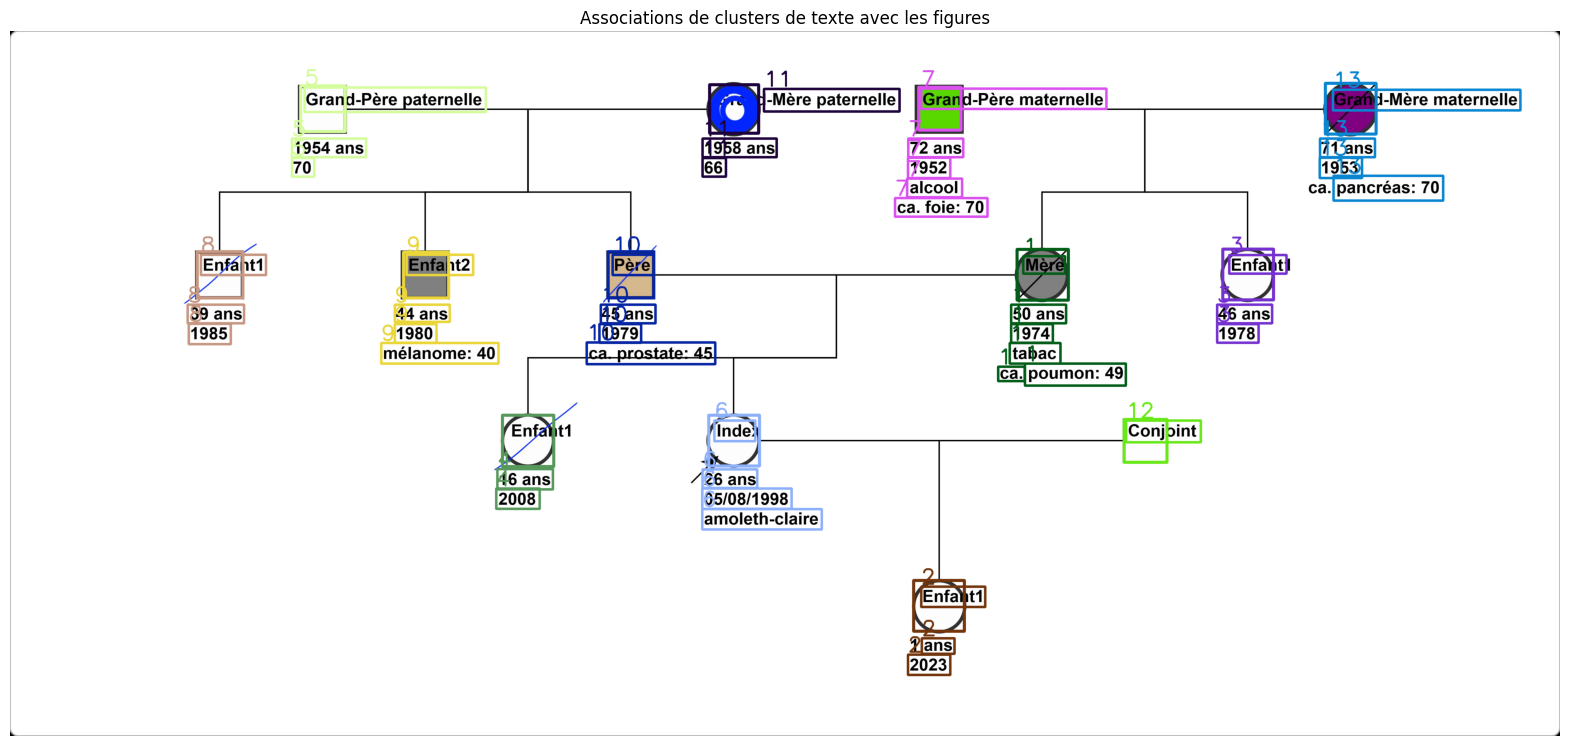

('1', {'color': (1, 93, 23), 'center': (3664, 864), 'bounding_box': ((3573, 774), (3755, 954)), 'coordinates': (3664, 864), 'class': 'femme decede', 'text': 'ca. Mèxê 50 ans 1974 tabac poumon: 49 '})
('2', {'color': (115, 53, 12), 'center': (3296, 2038), 'bounding_box': ((3206, 1948), (3386, 2128)), 'coordinates': (3296, 2038), 'class': 'femme', 'text': 'Enfant1 ans 2023 '})
('3', {'color': (116, 49, 207), 'center': (4393, 863), 'bounding_box': ((4303, 773), (4483, 953)), 'coordinates': (4393, 863), 'class': 'femme', 'text': 'Enfant 46 ans 1978 '})
('4', {'color': (87, 152, 91), 'center': (1838, 1453), 'bounding_box': ((1747, 1362), (1929, 1544)), 'coordinates': (1838, 1453), 'class': 'femme decede', 'text': '16 ans 2008 '})
('5', {'color': (212, 252, 156), 'center': (1110, 275), 'bounding_box': ((1031, 194), (1189, 356)), 'coordinates': (1110, 275), 'class': 'homme', 'text': 'Grand-Père paternelle 1954 ans 70 '})
('6', {'color': (141, 176, 251), 'center': (2569, 1452), 'bounding_box':

In [ ]:
def generate_distinct_color(existing_colors, min_distance=100):
    while True:
        color = tuple(random.choices(range(256), k=3))
        if all(np.linalg.norm(np.array(color) - np.array(existing_color)) >= min_distance for existing_color in existing_colors):
            return color
        
def seuillage_local(image, block_size=15, offset=8):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, block_size, offset)
    image.fill(255)
    image[thresh == 0] = 0

def pretraiter_image(image_path):
    img = cv2.imread(image_path)
    plt.figure(figsize=(20, 12))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    seuillage_local(img)
    # afficher l'image : 
    plt.figure(figsize=(20, 12))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()
    return img

def detecter_phrases_et_positions(image_path, threshold=0.5):
    img = pretraiter_image(image_path)
    reader = easyocr.Reader(['fr'], gpu=torch.backends.mps.is_available())
    text_results = reader.readtext(img)

    texte_positions = {}
    for result in text_results:
        bbox, texte, score = result
        if score > threshold:
            x1, y1 = bbox[0]
            x2, y2 = bbox[2]
            position = (int(x1), int(y1), int(x2), int(y2))
            texte_positions[texte] = position
    return texte_positions

def cluster_text_with_dbscan(text_results, eps=50, min_samples=2):
    """ Utilise DBSCAN pour grouper les textes basés sur leur proximité spatiale. """
    # Extraire les centres des bounding boxes des textes
    text_centers = [(int((bbox[0] + bbox[2]) / 2), int((bbox[1] + bbox[3]) / 2)) for bbox in text_results.values()]
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(text_centers)
    
    clusters = {}
    for idx, label in enumerate(clustering.labels_):
        if label == -1:
            # Ignorer les points considérés comme du bruit
            continue
        if label not in clusters:
            clusters[label] = []
        clusters[label].append(list(text_results.keys())[idx])
    return clusters, text_centers, clustering.labels_

def afficher_clusters(image, text_centers, labels, eps):
    """ Affiche les clusters et les rayons autour des points centraux. """
    clustered_img = image.copy()
    unique_labels = set(labels)
    colors = [generate_distinct_color([]) for _ in unique_labels]
    
    for idx, center in enumerate(text_centers):
        label = labels[idx]
        if label == -1:
            # Couleur pour les bruits
            color = (0, 0, 255)
        else:
            color = colors[label]
        # Dessiner le point
        cv2.circle(clustered_img, center, 5, color, -1)
        # Dessiner le rayon
        if label != -1:
            cv2.circle(clustered_img, center, eps, color, 2)

    # Afficher l'image avec les clusters
    plt.figure(figsize=(20, 12))
    plt.imshow(cv2.cvtColor(clustered_img, cv2.COLOR_BGR2RGB))
    plt.title("Clusters formés par DBSCAN avec les rayons (eps)")
    plt.axis("off")
    plt.show()

def non_max_suppression(yolo_results, iou_threshold=0.4):
    """
    Applique le Non-Maximum Suppression (NMS) pour supprimer les boîtes superposées.
    Gardera la boîte avec la plus haute confiance pour chaque ensemble de boîtes superposées.

    :param yolo_results: Résultats de YOLO sous forme de boîte (x1, y1, x2, y2, confiance, classe).
    :param iou_threshold: Seuil d'IoU pour considérer que les boîtes se superposent.
    :return: Liste des boîtes filtrées après NMS.
    """
    boxes = []
    scores = []
    classes = []

    for box in yolo_results[0].boxes:
        xywh = box.xywh[0]  # x_center, y_center, width, height
        conf = box.conf[0].item()
        cls = box.cls.item()

        # Convertir xywh en xyxy pour NMS
        x1 = xywh[0] - xywh[2] / 2
        y1 = xywh[1] - xywh[3] / 2
        x2 = xywh[0] + xywh[2] / 2
        y2 = xywh[1] + xywh[3] / 2

        # Ajouter la boîte et ses scores à la liste
        boxes.append([x1, y1, x2, y2])
        scores.append(conf)
        classes.append(cls)

    # Convertir en tenseur
    boxes = torch.tensor(boxes)
    scores = torch.tensor(scores)

    # Appliquer NMS
    keep = torchvision.ops.nms(boxes, scores, iou_threshold)

    # Filtrer les boîtes et leurs scores
    filtered_boxes = boxes[keep]
    filtered_scores = scores[keep]
    filtered_classes = [classes[i] for i in keep]

    return filtered_boxes, filtered_scores, filtered_classes

def associate_clusters_with_figures(yolo_results, text_results, clusters, SEUIL=300):
    final_text_associations = {}
    used_colors = []

    # Appliquer NMS pour filtrer les boîtes superposées
    filtered_boxes, filtered_scores, filtered_classes = non_max_suppression(yolo_results)

    for idx, (box, score, cls) in enumerate(zip(filtered_boxes, filtered_scores, filtered_classes)):
        x_center_px = int((box[0] + box[2]) / 2)
        y_center_px = int((box[1] + box[3]) / 2)
        width_px = int(box[2] - box[0])
        height_px = int(box[3] - box[1])
        
        figure_key = f"{idx+1}"
        figure_color = generate_distinct_color(used_colors)
        used_colors.append(figure_color)

        # Ajouter les informations dans final_text_associations
        final_text_associations[figure_key] = {
            'color': figure_color,
            'center': (x_center_px, y_center_px),
            'bounding_box': ((x_center_px - width_px // 2, y_center_px - height_px // 2),
                             (x_center_px + width_px // 2, y_center_px + height_px // 2)),
            'coordinates': (x_center_px, y_center_px),
            'class': classes[cls],  # On utilise ici l'index de la classe de la boîte filtrée
            'text': "",  # Texte associé au cluster
        }

    # Associer chaque cluster de texte à la figure la plus proche
    for cluster_id, text_keys in clusters.items():
        # Calculer le centre moyen du cluster
        cluster_centers = [((text_results[tk][0] + text_results[tk][2]) // 2, 
                            (text_results[tk][1] + text_results[tk][3]) // 2) for tk in text_keys]
        cluster_center = np.mean(cluster_centers, axis=0).astype(int)

        min_dist = float('inf')
        associated_figure = None

        for figure_key, figure_data in final_text_associations.items():
            figure_center = figure_data['center']
            dist = np.linalg.norm(np.array(cluster_center) - np.array(figure_center))
            if dist < min_dist:
                min_dist = dist
                associated_figure = figure_key

        # Associer le cluster et colorier les textes et la figure
        if associated_figure:
            figure_color = final_text_associations[associated_figure]['color']
            # Ajouter chaque texte au dictionnaire final
            for text_key in text_keys:
                final_text_associations[associated_figure]['text'] += f"{text_key} "

            # Supprimer l'annotation Yolo (ici, nous n'affichons plus le texte Yolo et ajoutons l'ID de la figure)
            for text_key in text_keys:
                x1, y1, x2, y2 = text_results[text_key]
                # Dessiner le rectangle autour du texte avec la couleur de la figure associée
                cv2.rectangle(img_original, (x1, y1), (x2, y2), figure_color, 7)
                # Afficher l'ID de la figure au lieu du texte Yolo, dans la même couleur que le cluster associé
                cv2.putText(img_original, associated_figure, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 2.5, figure_color, 6)

            # Dessiner le cadre de la figure associée
            cv2.rectangle(img_original, final_text_associations[associated_figure]['bounding_box'][0], 
                          final_text_associations[associated_figure]['bounding_box'][1], figure_color, 10)

    # Afficher l'image annotée
    plt.figure(figsize=(20, 12))
    plt.imshow(img_original)
    plt.title("Associations de clusters de texte avec les figures")
    plt.axis("off")
    plt.show()

    return final_text_associations

texte_positions = detecter_phrases_et_positions(image_path, threshold=0.3)

bounding_boxes_texts = []
for text, position in texte_positions.items():
    x1, y1, x2, y2 = position
    bounding_boxes_texts.append(((x1, y1), (x2, y2)))

# afficher les textes détectées avec leur région boundingbox en bleu : 
print("afficher textes détectés : ")
img_original_copy2 = cv2.imread(image_path)
for box in bounding_boxes_texts:
    cv2.rectangle(img_original_copy2, box[0], box[1], (255, 0, 0), 2)
plt.figure(figsize=(20, 12))
plt.imshow(cv2.cvtColor(img_original_copy2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
    
clusters, text_centers, labels = cluster_text_with_dbscan(texte_positions, eps=300, min_samples=1)

# Associer les clusters aux figures
final_text_associations = associate_clusters_with_figures(yolo_results, texte_positions, clusters, SEUIL=300)

# Affichage des résultats finaux dans le terminal
#print("\nRésultat des associations cluster-figure :")
#for figure, texts in final_text_associations.items():
#    print(f"Figure '{figure}' a les textes suivants : {texts}")
#    print(type(texts))
#    print(texts)

# Affichage des figures avec leur position
#for figure, texts in final_text_associations.items():
#    print(f"Figure '{figure}' a les textes suivants : {texts}")
#    print("Sa classe est :", texts['class'])
for text_association in final_text_associations.items():
    print(text_association)

In [6]:
final_text_associations.items()

dict_items([('1', {'color': (1, 93, 23), 'center': (3664, 864), 'bounding_box': ((3573, 774), (3755, 954)), 'coordinates': (3664, 864), 'class': 'femme decede', 'text': 'ca. Mèxê 50 ans 1974 tabac poumon: 49 '}), ('2', {'color': (115, 53, 12), 'center': (3296, 2038), 'bounding_box': ((3206, 1948), (3386, 2128)), 'coordinates': (3296, 2038), 'class': 'femme', 'text': 'Enfant1 ans 2023 '}), ('3', {'color': (116, 49, 207), 'center': (4393, 863), 'bounding_box': ((4303, 773), (4483, 953)), 'coordinates': (4393, 863), 'class': 'femme', 'text': 'Enfant 46 ans 1978 '}), ('4', {'color': (87, 152, 91), 'center': (1838, 1453), 'bounding_box': ((1747, 1362), (1929, 1544)), 'coordinates': (1838, 1453), 'class': 'femme decede', 'text': '16 ans 2008 '}), ('5', {'color': (212, 252, 156), 'center': (1110, 275), 'bounding_box': ((1031, 194), (1189, 356)), 'coordinates': (1110, 275), 'class': 'homme', 'text': 'Grand-Père paternelle 1954 ans 70 '}), ('6', {'color': (141, 176, 251), 'center': (2569, 1452)

In [ ]:
nlp = spacy.load("fr_core_news_sm")

# Fonction de lemmatisation avec spaCy
def lemmatize_text(text):
    doc = nlp(text)  # Applique le modèle spaCy pour analyser le texte
    lemmatized_text = " ".join([token.lemma_ for token in doc])  # Utilise les lemmes des tokens
    return lemmatized_text

# Dictionnaire de motifs pour classifier les maladies
disease_patterns = {
    "cancer du sein": [
        r"ca\. sein", r"cancer du sein", r"cancer mammaire", r"carcinome mammaire", r"tumeur mammaire", 
        r"carcinome infiltrant", r"tumeur du sein", r"cancer de la glande mammaire", r"mammographie suspecte", 
        r"cancer du sein métastatique", r"triple négatif", r"cancer hormonodépendant", r"cancer du sein HER2", 
        r"cancer de la poitrine", r"carcinome ductal", r"carcinome lobulaire",
        
        # Ajouts en anglais
        r"ca breast", r"cancer du breast", r"cancer mammary", r"carcinoma mammary", r"tumor mammary", 
        r"carcinoma infiltrant", r"tumor of the breast", r"cancer of the gland mammary", r"mammography suspect", 
        r"cancer du breast metastatic", r"triple negative", r"cancer hormonodependent", r"cancer du breast her2", 
        r"cancer of the chest", r"carcinoma ductal", r"carcinoma lobular"
    ],
    
    "cancer du pancréas": [
        r"ca\. pancréas", r"cancer du pancréas", r"carcinome pancréatique", r"tumeur pancréatique", 
        r"pancréatite chronique", r"pancréas adenocarcinome", r"tumeur de la tête du pancréas", 
        r"cancer pancréatique", r"cancer du pancréas métastatique",

        # Ajouts en anglais
        r"ca pancreas", r"cancer du pancreas", r"carcinoma pancreatic", r"tumor pancreatic", 
        r"chronic pancreatitis", r"pancreas adenocarcinoma", r"tumor of the head of the pancreas", 
        r"cancer pancreatic", r"cancer du pancreas metastatic"
    ],
    
    "cancer de la prostate": [
        r"ca\. prostate", r"cancer de la prostate", r"carcinome prostatique", r"tumeur prostatique", 
        r"cancer de la glande prostatique", r"prostate adenocarcinoma", r"prostate cancer", r"cancer de la prostate métastatique", 
        r"hyperplasie bénigne de la prostate", r"carcinome acinaire", r"prostatite", r"carcinome de la prostate", r"prostate"
    ],
    
    "cancer du poumon": [
        r"ca\. poumon", r"cancer du poumon", r"carcinome pulmonaire", r"tumeur pulmonaire", r"cancer bronchique", 
        r"cancer des voies respiratoires", r"carcinome non à petites cellules", r"cancer pulmonaire non à petites cellules", 
        r"cancer à petites cellules", r"bronchopneumopathie", r"tumeur pulmonaire primitive", r"cancer du poumon métastatique"
    ],
    
    "cancer du côlon": [
        r"ca\. côlon", r"cancer du côlon", r"carcinome colique", r"tumeur colique", r"cancer colorectal", 
        r"cancer du côlon droit", r"cancer du côlon gauche", r"cancer du rectum", r"tumeur bénigne du côlon", 
        r"polype colon", r"cancer du côlon métastatique", r"cancer du côlon héréditaire", r"carcinome du côlon"
    ],
    
    "cancer de la vessie": [
        r"ca\. vessie", r"cancer de la vessie", r"carcinome vésical", r"tumeur vésicale", r"cancer urinaire", 
        r"carcinome urothélial", r"cancer de la paroi vésicale", r"tumeur urothéliale", r"cancer de la vessie métastatique", 
        r"bladder carcinoma"
    ],
    
    "cancer de l'estomac": [
        r"ca\. estomac", r"cancer de l'estomac", r"carcinome gastrique", r"tumeur gastrique", r"cancer de l'ulcère gastrique", 
        r"tumeur de l'estomac", r"cancer de la paroi gastrique", r"cancer gastrique métastatique", 
        r"carcinome adénocellulaire de l'estomac", r"lymphome gastrique"
    ],
    
    "cancer du foie": [
        r"ca\. foie", r"cancer du foie", r"carcinome hépatocellulaire", r"tumeur hépatique", r"hépatocarcinome", 
        r"cancer hépatique primaire", r"carcinome du foie", r"hépatome", r"cirrhose et cancer du foie", 
        r"cancer du foie métastatique", r"tumeur hépatique maligne"
    ],
    
    "cancer du rein": [
        r"ca\. rein", r"cancer du rein", r"carcinome rénal", r"tumeur rénale", r"cancer du rein métastatique", 
        r"néphroblastome", r"carcinome à cellules rénales", r"tumeur rénale maligne", r"cancer du rein héréditaire", 
        r"rein polycystique et cancer"
    ],
    
    "cancer de la peau": [
        r"ca\. peau", r"cancer de la peau", r"carcinome cutané", r"tumeur cutanée", r"mélanome", 
        r"carcinome basocellulaire", r"carcinome spinocellulaire", r"cancer de la peau métastatique", 
        r"carcinome épithélial cutané", r"cancer cutané de la peau"
    ],
    
    "cancer de l'ovaire": [
        r"ovaire", r"ca\. ovaire", r"cancer de l'ovaire", r"carcinome ovarien", r"tumeur ovarienne", 
        r"cancer ovarien", r"tumeur des ovaires", r"cancer épithélial ovarien", r"carcinome à cellules claires de l'ovaire", 
        r"tumeur bénigne de l'ovaire", r"cancer des trompes de Fallope"
    ],

    "cancer du cerveau": [
        r"ca\. cerveau", r"cancer du cerveau", r"carcinome cérébral", r"tumeur cérébrale", 
        r"glioblastome", r"glioblastome multiforme", r"gliome", r"méningiome", r"astrocytome", 
        r"astrocytome pilocytique", r"astrocytome diffus", r"gliome de haut grade", r"gliome de bas grade", 
        r"cancer du système nerveux central", r"tumeur gliale", r"tumeur cérébrale maligne", r"neuroblastome", 
        r"cancer des cellules nerveuses", r"lymphome cérébral", r"médulloblastome", r"tumeur neuroendocrine cérébrale", 
        r"tumeur cérébrale métastatique", r"métastases cérébrales", r"cancer cérébral secondaire", 
        r"métastase du cerveau", r"tumeur intracrânienne", r"tumeur cérébrale primaire", 
        r"cancer du cerveau primitif", r"tumeur glioblastomateuse", r"cancer des cellules gliales",
        
        # Ajouts en anglais
        r"ca brain", r"cancer du brain", r"carcinoma cerebral", r"tumor cerebral", 
        r"glioblastoma", r"glioblastoma multiforme", r"glioma", r"meningioma", r"astrocytoma", 
        r"astrocytoma pilocytic", r"astrocytoma diffuse", r"glioma of high grade", r"glioma of low grade", 
        r"cancer of the central nervous system", r"tumor glial", r"tumor cerebral malignant", r"neuroblastoma", 
        r"cancer of the nerve cells", r"lymphoma cerebral", r"medulloblastoma", r"tumor neuroendocrine cerebral", 
        r"tumor cerebral metastatic", r"metastases cerebral", r"cancer cerebral secondary", 
        r"metastasis of brain", r"intracranial tumor", r"primary tumor cerebral", 
        r"cancer of the primitive brain", r"glioblastoma tumor", r"cancer of glial cells"
    ],
    
    "cancer de la thyroïde": [
        r"ca\. thyroïde", r"cancer de la thyroïde", r"carcinome thyroïdien", r"tumeur thyroïdienne", 
        r"cancer papillaire de la thyroïde", r"carcinome médullaire de la thyroïde", r"cancer anaplasique de la thyroïde", 
        r"tumeur bénigne de la thyroïde", r"cancer folliculaire de la thyroïde"
    ],
    
    "cancer du sang": [
        r"ca\. sang", r"cancer du sang", r"leucémie", r"lymphome", r"hémopathie maligne", r"tumeur sanguine", 
        r"leucémie aiguë", r"leucémie chronique", r"cancer des cellules sanguines", r"myélome", r"lymphome hodgkinien", 
        r"lymphome non hodgkinien", r"cancer du sang métastatique", r"sang", r"cancer du sang"
    ],
    
    "cancer des os": [
        r"ca\. os", r"cancer des os", r"ostéosarcome", r"carcinome osseux", r"tumeur osseuse", 
        r"métastase osseuse", r"tumeur des os", r"cancer du squelette", r"sarcome osseux", r"chondrosarcome"
    ]
}
# lemmatiser les motifs de disease_patterns :
for disease, patterns in disease_patterns.items():
    disease_patterns[disease] = [lemmatize_text(pattern) for pattern in patterns]

# afficher :
for disease, patterns in disease_patterns.items():
    print(f"{disease} : {patterns}")

# Fonction pour classifier les maladies avec motifs et BioBERT si inconnu
def classify_disease(text):
    # Nettoyer le texte (minuscule, suppression des accents)
    text = nettoyer_texte(text)
    print("Text : ", text)
    lemmatized_text = lemmatize_text(text)
    print("Lemmatized Text : ", lemmatized_text)
    # D'abord essayer de classifier avec les motifs
    for disease, patterns in disease_patterns.items():
        if any(re.search(pattern, lemmatized_text, re.IGNORECASE) for pattern in patterns):
            return disease
    return "sain"

# Fonction de nettoyage du texte (minuscule, suppression des accents)
def nettoyer_texte(texte):
    texte = texte.lower()
    texte = unicodedata.normalize('NFD', texte)
    texte = ''.join([c for c in texte if unicodedata.category(c) != 'Mn'])
    return texte

# Fonction d'extraction des informations principales avec gestion des YOB et Age
def extract_person_data(text):
    data = {}
    
    # Nettoyer le texte (minuscule, suppression des accents)
    text = nettoyer_texte(text)
    
    # Extraire les noms, y compris les distinctions paternelle/maternelle
    name_match = re.search(r"(grand-pere|grand-mere)\s*(paternelle|maternelle)|pere|mere|enfaht\d+|index|conjoint", text)
    if name_match:
        data['Name'] = name_match.group(0).replace("ê", "e").replace("â", "a").replace("Mèrê", "Mere").replace("enfaht1", "enfant").replace("enfant2","enfant").replace("pere","pere").replace("mere","mere").replace("enfaht2","enfant")
    else:
        data['Name'] = "Person_Unknown"
        
    # Extraire l'année de naissance (YYYY)
    yob_match = re.search(r"(\d{4})", text)
    if yob_match:
        data['Yob'] = yob_match.group(1)
    else:
        data['Yob'] = None

    # Extraire l'âge (xx ans) ou (50 ans)
    age_match = re.search(r"(\d{1,2})\s*(an|ans)", text)
    if age_match:
        data['Age'] = age_match.group(1)
    else:
        if data['Yob'] != None:
            data['Age'] = 2024 - int(data['Yob'])
        else:
            data['Age'] = None

    # Extraire les maladies (ex. : "alcool", "tabac", "ca. foie", "ca. pancréas")
    data['Diseases'] = [classify_disease(text)]

    # Détection des décès (via la présence d'une barre sur le symbole)
    #if re.search(r"(croix|barre|decede|mort)", text, re.IGNORECASE):
    #    data['Dead'] = 1
    #else:
    #    data['Dead'] = 0
    return data

print()
print()
text = "Mère, 50 ans, cancer sang 1978, decede"
print(nettoyer_texte(text))
person_data = extract_person_data(text)
print(person_data)

cancer du sein : ['ca\\. sein', 'cancer de sein', 'cancer mammaire', 'carcinome mammaire', 'tumeur mammaire', 'carcinome infiltrant', 'tumeur de sein', 'cancer de le gland mammaire', 'mammographie suspecter', 'cancer de sein métastatique', 'triple négatif', 'cancer hormonodépendant', 'cancer de sein HER2', 'cancer de le poitrine', 'carcinome ductal', 'carcinome lobulaire', 'ca breast', 'cancer de breast', 'cancer mammary', 'carcinoma mammary', 'tumor mammary', 'carcinoma infiltrant', 'tumor of the breast', 'cancer of the gland mammary', 'mammography suspect', 'cancer de breast metastatic', 'triple negativ', 'cancer hormonodependent', 'cancer de breast her2', 'cancer of the chest', 'carcinoma ductal', 'carcinoma lobular']
cancer du pancréas : ['ca\\. pancréas', 'cancer de pancréas', 'carcinome pancréatique', 'tumeur pancréatique', 'pancréatite chronique', 'pancréas adenocarcinome', 'tumeur de le tête de pancréas', 'cancer pancréatique', 'cancer de pancréas métastatique', 'ca pancrea', '

In [8]:
# Dictionnaire pour stocker les données de chaque figure
figure_data = {}

def extract_sex_from_class(class_name):
    if "homme" in class_name.lower():
        return "M"
    elif "femme" in class_name.lower():
        return "F"
    else:
        return "Unknown"  # Si la classe ne contient pas "homme" ou "femme"
    
def extract_death_from_class(class_name):
    if "decede" in class_name.lower() or "decedee" in class_name.lower():
        return 1
    else:
        return 0
    
def clarify_disease_and_check(class_name, diseases, sex, confidence):
    # Si la confiance est faible, on considère que YOLO s'est probablement trompé
    if confidence < 0.3:
        # si y a une incohérence entre la classe et les maladies, on doit corriger
        # si y a une maladie mais y a pas de classe "atteint" ou "atteinte", on doit corriger la classe:
        if len(diseases) > 0 and "atteint" not in class_name.lower() and "atteinte" not in class_name.lower():
            # si c'est un homme :
            print("Enfaite c'est là le problème !")
            if sex == "M":
                class_name = class_name.replace("homme", "homme atteint")
            else:
                class_name = class_name.replace("femme", "femme atteinte")
        else:
            # sinon si y a pas de maladie mais y a une classe "atteint" ou "atteinte", on doit corriger la maladie:
            if len(diseases) == 0 and "atteint" in class_name.lower() or "atteinte" in class_name.lower():
                diseases = ["maladie inconnue"]
    else:
        # si on a confiance en yolo : 
        # si la classe est "atteint" ou "atteinte" mais y a pas de maladie, on doit mettre "maladie inconnue"
        if "atteint" in class_name.lower() or "atteinte" in class_name.lower():
            diseases = ["maladie inconnue"]
        # si la classe n'est pas atteint ou atteinte mais qu'il y a une maladie on doit corriger la classe :
        if len(diseases) > 0 and diseases[0] != "sain" and "atteint" not in class_name.lower() and "atteinte" not in class_name.lower():
            # si c'est un homme :
            print("Je rentre ici !")
            print(diseases[0])
            if sex == "M":
                class_name = class_name.replace("homme", "homme atteint")
            else:
                class_name = class_name.replace("femme", "femme atteinte")
    return class_name, diseases
    
# Fonction pour extraire les informations d'une figure à partir du texte
def extract_figure_data(texts, class_name, confidence):
    # Nettoyer et extraire les informations du texte
    cleaned_text = nettoyer_texte(texts)
    person_data = extract_person_data(cleaned_text)
    
    # Extraire le sexe à partir de la classe
    sex = extract_sex_from_class(class_name)
    dead = extract_death_from_class(class_name)
    class_name, diseases = clarify_disease_and_check(class_name, person_data['Diseases'], extract_sex_from_class(class_name), confidence)

    # Ajouter toutes les informations au dictionnaire final
    figure_info = {
        "Name": person_data['Name'],
        "Class" : class_name,
        "Age": person_data['Age'],
        "Yob": person_data['Yob'],
        "Diseases": diseases,
        "Dead": dead,
        "Sex": sex,  # Sexe extrait de la classe
        "Father ID": None,  # Pas d'ID pour le père
        "Mother ID": None,  # Pas d'ID pour la mère
    }

    return figure_info

print("------debug--------")
print(final_text_associations.items())
print("------debug--------")
# Associer les textes aux figures et créer le dictionnaire pour chaque figure
# Associer les textes aux figures et créer le dictionnaire pour chaque figure
for idx, (figure, figure_info) in enumerate(final_text_associations.items()):
    print(f"Processing {figure}...")
    
    # Extraire les données pour chaque figure à partir du texte et de la classe associée
    text = figure_info['text']  # Le texte est une string unique pour chaque figure
    class_name = figure_info['class']  # La classe associée à la figure (ex. : "homme décédé", "femme atteinte", etc.)
    
    # Récupérer la confiance de YOLO pour cette détection en utilisant l'indice de la boucle (idx)
    confidence = yolo_results[0].boxes[idx].conf.item()  # Utilisation de l'indice `idx` pour accéder à la confiance
    print("Confidence : ", confidence)
    
    # Passer le texte et la classe à la fonction extract_figure_data
    figure_data[figure] = extract_figure_data(text, class_name, confidence)

# Afficher les résultats
print("\nDonnées extraites pour chaque figure :")
for figure, data in figure_data.items():
    print(f"\n{figure}:")
    print(data)

------debug--------
dict_items([('1', {'color': (1, 93, 23), 'center': (3664, 864), 'bounding_box': ((3573, 774), (3755, 954)), 'coordinates': (3664, 864), 'class': 'femme decede', 'text': 'ca. Mèxê 50 ans 1974 tabac poumon: 49 '}), ('2', {'color': (115, 53, 12), 'center': (3296, 2038), 'bounding_box': ((3206, 1948), (3386, 2128)), 'coordinates': (3296, 2038), 'class': 'femme', 'text': 'Enfant1 ans 2023 '}), ('3', {'color': (116, 49, 207), 'center': (4393, 863), 'bounding_box': ((4303, 773), (4483, 953)), 'coordinates': (4393, 863), 'class': 'femme', 'text': 'Enfant 46 ans 1978 '}), ('4', {'color': (87, 152, 91), 'center': (1838, 1453), 'bounding_box': ((1747, 1362), (1929, 1544)), 'coordinates': (1838, 1453), 'class': 'femme decede', 'text': '16 ans 2008 '}), ('5', {'color': (212, 252, 156), 'center': (1110, 275), 'bounding_box': ((1031, 194), (1189, 356)), 'coordinates': (1110, 275), 'class': 'homme', 'text': 'Grand-Père paternelle 1954 ans 70 '}), ('6', {'color': (141, 176, 251), 'c

# LINES DETECTION

## Un code pour afficher les lignes interactivement :

In [9]:
# pour regrouper les lignes par proximité et les trier en une seule liste plate
def regrouper_et_trier_lignes_par_proximite(lignes, seuil_proximite=50):
    """
    Regroupe les lignes par proximité et les retourne sous forme d'une liste triée plate.
    
    :param lignes: Liste de lignes (chaque ligne est [x1, y1, x2, y2])
    :param seuil_proximite: Distance maximale pour regrouper deux lignes
    :return: Liste unique de lignes triées par proximité
    """
    sorted_lines = []
    lignes_restantes = lignes[:]

    while lignes_restantes:
        sequence = [lignes_restantes.pop(0)]
        i = 0
        
        while i < len(sequence):
            ligne_actuelle = sequence[i]
            x1, y1, x2, y2 = ligne_actuelle
            
            # comparer avec les lignes restantes pour proximité
            for ligne in lignes_restantes[:]:
                x1_voisin, y1_voisin, x2_voisin, y2_voisin = ligne
                if (euclidean((x1, y1), (x1_voisin, y1_voisin)) < seuil_proximite or
                    euclidean((x1, y1), (x2_voisin, y2_voisin)) < seuil_proximite or
                    euclidean((x2, y2), (x1_voisin, y1_voisin)) < seuil_proximite or
                    euclidean((x2, y2), (x2_voisin, y2_voisin)) < seuil_proximite):
                    
                    sequence.append(ligne)
                    lignes_restantes.remove(ligne)
            i += 1

        sorted_lines.extend(sequence)
    
    return sorted_lines

# pour afficher une seule ligne avec des cercles indiquant le seuil de proximité
def afficher_ligne_avec_seuil(image, ligne, seuil_proximite):
    image_avec_seuil = image.copy()
    x1, y1, x2, y2 = map(int, ligne)
    
    # draw la ligne
    cv2.line(image_avec_seuil, (x1, y1), (x2, y2), (0, 255, 0), 9)
    # draw cercles de proximité autour des points de départ et d'arrivée
    cv2.circle(image_avec_seuil, (x1, y1), seuil_proximite, (255, 0, 0), 2)
    cv2.circle(image_avec_seuil, (x2, y2), seuil_proximite, (255, 0, 0), 2)
    
    plt.figure(figsize=(16, 16))
    plt.imshow(cv2.cvtColor(image_avec_seuil, cv2.COLOR_BGR2RGB))
    plt.title("Ligne actuelle avec seuil de proximité")
    plt.axis("off")
    plt.show()

# classe de navigation interactive pour afficher les lignes triées
class LineNavigator:
    def __init__(self, image, lignes, seuil_proximite=50):
        self.image = image
        self.lignes = regrouper_et_trier_lignes_par_proximite(lignes, seuil_proximite=50)
        self.index = 0
        self.seuil_proximite = seuil_proximite
        
        # widgets interactifs
        self.out = Output()
        self.button_prev = Button(description="⬅️ Précédent")
        self.button_next = Button(description="➡️ Suivant")
        self.button_prev.on_click(self.prev_line)
        self.button_next.on_click(self.next_line)
        
        self.display_line()
        display(HBox([self.button_prev, self.button_next]), self.out)

    def display_line(self):
        with self.out:
            self.out.clear_output(wait=True)
            afficher_ligne_avec_seuil(self.image, self.lignes[self.index], self.seuil_proximite)

    def prev_line(self, _):
        if self.index > 0:
            self.index -= 1
            self.display_line()

    def next_line(self, _):
        if self.index < len(self.lignes) - 1:
            self.index += 1
            self.display_line()

# pour utiliser :
# navigator = LineNavigator(image, lignes, seuil_proximite=50)

## Un pre-processing pour atténuer les lignes de scanner avec un filtre médian :

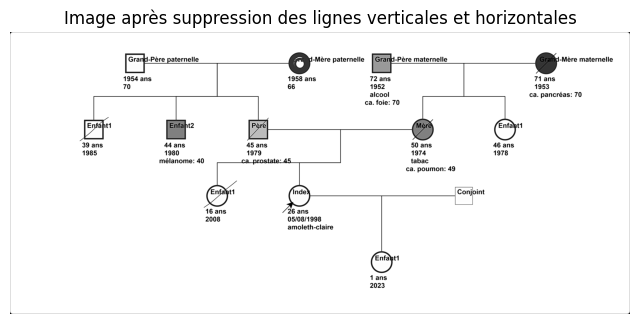

In [10]:
def remove_vertical_line_smoothing(image):
    """
    Supprime la ligne verticale en appliquant un lissage directionnel horizontal.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) if len(image.shape) == 3 else image
    
    kernel_size = (1, 31)  # large noyau horizontal pour lissage vertical
    blurred = cv2.GaussianBlur(gray, kernel_size, 0)
    
    restored = cv2.addWeighted(gray, 1.5, blurred, -0.5, 0)
    denoised = cv2.medianBlur(restored, 3)
    
    return denoised

def remove_horizontal_line_smoothing(image):
    """
    Supprime les lignes horizontales en appliquant un lissage directionnel vertical.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) if len(image.shape) == 3 else image
    
    kernel_size = (31, 1)  # large noyau vertical pour lissage horizontal
    blurred = cv2.GaussianBlur(gray, kernel_size, 0)
    
    restored = cv2.addWeighted(gray, 1.5, blurred, -0.5, 0)
    denoised = cv2.medianBlur(restored, 3)
    
    return denoised

img_original = cv2.imread(image_path)

# apply le lissage pour les lignes verticales et ensuite horizontales
img_denoised = remove_vertical_line_smoothing(img_original)
img_denoised = remove_horizontal_line_smoothing(img_denoised)

plt.figure(figsize=(8, 6))
plt.imshow(img_denoised, cmap='gray')
plt.title('Image après suppression des lignes verticales et horizontales')
plt.axis('off')
plt.show()

## Preprocessing pour améliorer le contraste :

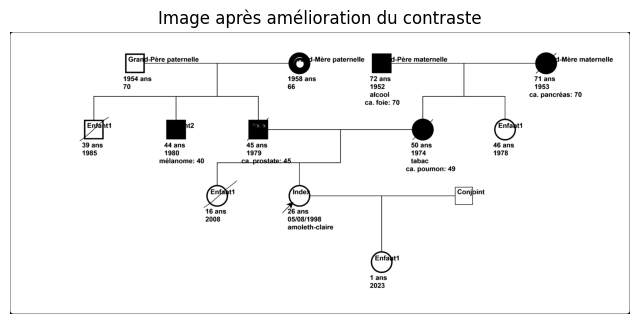

In [11]:
def enhance_contrast(image):
    """
    Remplace tout ce qui n'est pas blanc par du noir pour améliorer le contraste.
    """

    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    _, binary_image = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)
    
    return binary_image

img_contrast = enhance_contrast(img_denoised)

plt.figure(figsize=(8, 6))
plt.imshow(img_contrast, cmap='gray')
plt.title('Image après amélioration du contraste')
plt.axis('off')
plt.show()

## Détection des lignes avec DeepLSD

#### Resize de l'image pour la passer au modèle

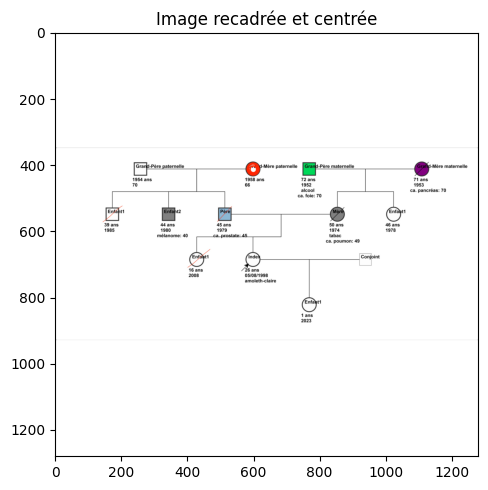

In [12]:
image = cv2.imread(image_path)

# pour détecter les contours et obtenir le rectangle englobant
def detecter_contours_et_rectangle_englobant(image):
    """
    Détecte les contours dans l'image et renvoie les points (x_min, y_min, x_max, y_max)
    correspondant au rectangle englobant toutes les formes dans l'image.
    """
    # convert l'image en niveaux de gris
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # apply un seuillage pour améliorer la détection des contours
    _, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)

    # detecter les contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # trouver les points extrêmes
    x_min, y_min = np.inf, np.inf
    x_max, y_max = -np.inf, -np.inf

    for contour in contours:
        for point in contour:
            x, y = point[0]
            x_min = min(x_min, x)
            y_min = min(y_min, y)
            x_max = max(x_max, x)
            y_max = max(y_max, y)

    return int(x_min), int(y_min), int(x_max), int(y_max)

# pour redimensionner l'image et la centrer dans un cadre 1280x1280 avec fond blanc
def resize_and_center_image(image, target_size=1280):
    """
    Redimensionne et centre l'image dans un cadre de 1280x1280 tout en respectant l'aspect ratio.
    L'image est centrée avec des bordures blanches si nécessaire.
    Retourne l'image centrée, le facteur d'échelle et les offsets.
    """
    height, width = image.shape[:2]

    # calculer le facteur de redimensionnement tout en respectant l'aspect ratio
    scale_factor = min(target_size / width, target_size / height)
    new_width = int(width * scale_factor)
    new_height = int(height * scale_factor)

    # redim l'image tout en respectant l'aspect ratio
    resized_img = cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_AREA)

    # creer une image blanche (fond) de 1280x1280
    centered_img = np.ones((target_size, target_size, 3), dtype=np.uint8) * 255  # Blanc (255, 255, 255)

    # calculer les coordonnées pour centrer l'image redimensionnée
    x_offset = (target_size - new_width) // 2
    y_offset = (target_size - new_height) // 2

    # positionner l'image redimensionnée au centre du cadre 1280x1280
    centered_img[y_offset:y_offset + new_height, x_offset:x_offset + new_width] = resized_img

    return centered_img, scale_factor, x_offset, y_offset

# detecter le rectangle englobant l'arbre généalogique
x_min, y_min, x_max, y_max = detecter_contours_et_rectangle_englobant(image)

# recadrer l'image autour de l'arbre
cropped_img = image[y_min:y_max, x_min:x_max]

# redim l'image et la centrer dans un cadre 1280x1280 avec fond blanc
final_img, scale_factor, x_offset, y_offset = resize_and_center_image(cropped_img, target_size=1280)

# l'image redimensionnée et centrée
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
plt.title(f'Image recadrée et centrée')
plt.tight_layout()
plt.show()

# save le res
result_image = final_img

# enregistrer les informations pour revenir à l'image originale
transform_info = {
    'scale_factor': scale_factor,
    'x_min': x_min,
    'y_min': y_min,
    'x_offset': x_offset,
    'y_offset': y_offset
}

#### Appliquer le modèle sur l'image resize

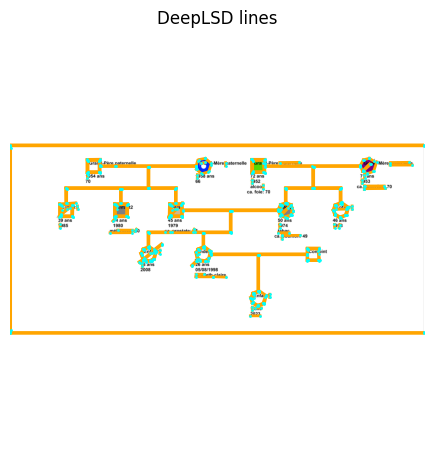

In [13]:
# chargement du modèle

gray_img = cv2.cvtColor(result_image, cv2.COLOR_RGB2GRAY)

# model config
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
conf = {
    'detect_lines': True,  # Whether to detect lines or only DF/AF
    'line_detection_params': {
        'merge': False,  # Whether to merge close-by lines
        'filtering': True,  # Whether to filter out lines based on the DF/AF. Use 'strict' to get an even stricter filtering
        'grad_thresh': 3,
        'grad_nfa': True,  # If True, use the image gradient and the NFA score of LSD to further threshold lines. We recommand using it for easy images, but to turn it off for challenging images (e.g. night, foggy, blurry images)
    }
}

# load the model
#ckpt = '../weights/deeplsd_md.tar'
ckpt = '../../DeepLSD/weights/deeplsd_md.tar'
ckpt = torch.load(str(ckpt), map_location='cpu')
net = DeepLSD(conf)
net.load_state_dict(ckpt['model'])
net = net.to(device).eval()

# apply du modèle sur l'image preprocessée
# detect (and optionally refine) the lines
inputs = {'image': torch.tensor(gray_img, dtype=torch.float, device=device)[None, None] / 255.}
with torch.no_grad():
    out = net(inputs)
    pred_lines = out['lines'][0]

# plot the predictions
plot_images([result_image], ['DeepLSD lines'], cmaps='gray')
plot_lines([pred_lines], indices=range(1))

## Convertir les lignes détectées au format de l'image originale 

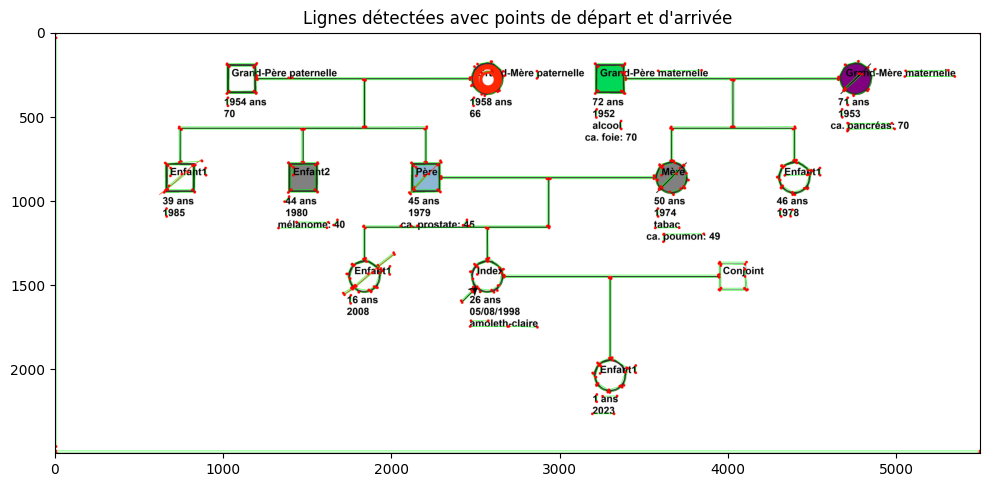

<class 'list'>
[[4776.024898910522, 247.8847929239273, 4692.99155960083, 332.5056993484497], [1387.6384123563766, 272.01597039699556, 1198.61015625, 272.01059503555297], [4652.682117462158, 270.61706535816194, 3389.614297771454, 272.4651408433914], [753.0750930190086, 843.3795264244079, 677.6992838501931, 913.9100372314454], [2193.5385588884355, 853.3551484107971, 2132.8951732635496, 921.6502954959869], [3712.727798509598, 808.1507185935974, 3597.923450946808, 917.0411197185516], [3668.039927816391, 764.7115050315857, 3668.398897075653, 579.963347697258], [3955.147159910202, 1520.807485628128, 3954.6741281032564, 1387.6301526546479], [1760.7254684686661, 1519.7476216793061, 1712.175466132164, 1550.2967185020448], [2465.9575502872467, 270.54849672317505, 1409.114292383194, 272.3083376169205], [2011.487259721756, 1310.334290599823, 1917.843481349945, 1384.4670802116393], [4034.03203125, 283.2462804079056, 4652.66953125, 283.26345534324645], [4709.808836746216, 433.9939655542374, 4708.540

In [14]:
# pour inverser la transformation sur les lignes détectées
def inverser_transformation_lignes(lignes_detectees, transform_info):
    """
    Applique les transformations inverses pour mapper les lignes détectées de l'image redimensionnée
    vers l'image d'origine.
    """
    lignes_orig = []
    
    scale_factor = transform_info['scale_factor']
    x_min = transform_info['x_min']
    y_min = transform_info['y_min']
    x_offset = transform_info['x_offset']
    y_offset = transform_info['y_offset']
    
    # inverser les transformations
    for ligne in lignes_detectees:
        (x1, y1), (x2, y2) = ligne
        
        # inverser le centrage et le redimensionnement
        x1_orig = (x1 - x_offset) / scale_factor + x_min
        y1_orig = (y1 - y_offset) / scale_factor + y_min
        x2_orig = (x2 - x_offset) / scale_factor + x_min
        y2_orig = (y2 - y_offset) / scale_factor + y_min
        
        lignes_orig.append([x1_orig, y1_orig, x2_orig, y2_orig])
    
    return lignes_orig

# pour afficher les lignes détectées sur l'image originale avec points de départ et d'arrivée
def afficher_lignes_sur_image_originale(image_originale, lignes_orig):
    """
    Affiche l'image originale avec les lignes détectées superposées et les points de départ et d'arrivée en rouge.
    
    :param image_originale: Image d'origine (avant redimensionnement et recadrage).
    :param lignes_orig: Lignes détectées mappées sur l'image originale.
    """
    # une copie de l'image originale pour ne pas la modifier
    image_avec_lignes = image_originale.copy()

    # dessinner les lignes sur l'image et les points de départ et d'arrivée
    for ligne in lignes_orig:
        x1, y1, x2, y2 = map(int, ligne)
        
        # dessiner la ligne en vert
        cv2.line(image_avec_lignes, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Vert pour les lignes
        
        # dessinner le point de départ en rouge
        cv2.circle(image_avec_lignes, (x1, y1), radius=8, color=(0, 0, 255), thickness=-1)  # Rouge pour le starting point
        
        # dessiner le point d'arrivée en rouge
        cv2.circle(image_avec_lignes, (x2, y2), radius=8, color=(0, 0, 255), thickness=-1)  # Rouge pour l'ending point

    # l'image originale avec les lignes détectées et les points de départ et d'arrivée
    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(image_avec_lignes, cv2.COLOR_BGR2RGB))
    plt.title('Lignes détectées avec points de départ et d\'arrivée')
    plt.tight_layout()
    plt.show()

# inverser la transformation des lignes détectées
lignes_orig = inverser_transformation_lignes(pred_lines, transform_info)

# afficher l'image originale avec les lignes détectées
afficher_lignes_sur_image_originale(image, lignes_orig)
print(type(lignes_orig))
print(lignes_orig)
print(len(lignes_orig))

## Prétraîtement pour enlever les lignes sur le texte : 

Nombre de lignes originales : 245
Nombre de lignes après filtrage : 204


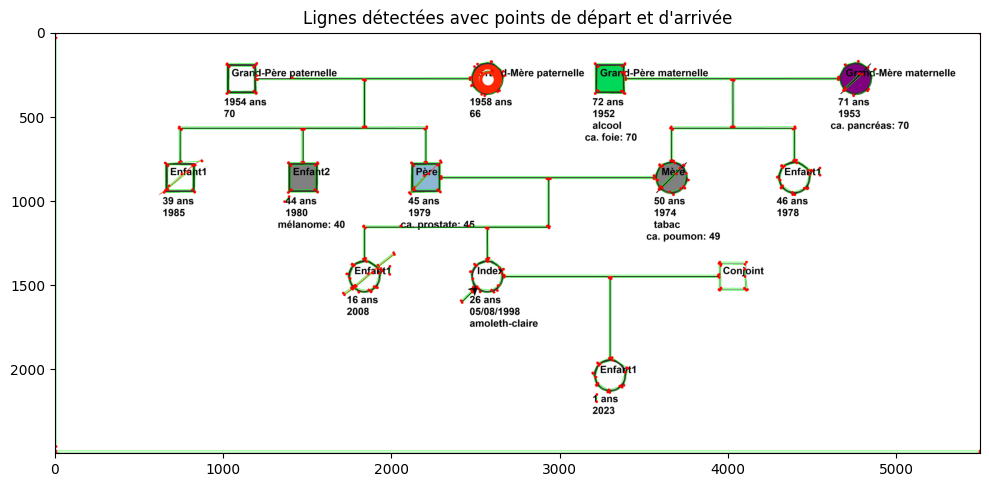

In [15]:
def est_dans_bounding_box(bbox, point):
    """
    Vérifie si un point est à l'intérieur d'une bounding box.
    """
    (x_min, y_min), (x_max, y_max) = bbox
    x, y = point
    return x_min <= x <= x_max and y_min <= y <= y_max

# filtrer les lignes dont les deux extrémités sont dans une des bounding boxes
lignes_reduites = []
for ligne in lignes_orig:
    (x1, y1), (x2, y2) = (ligne[:2], ligne[2:])
    
    # verif si la ligne est dans une des bounding boxes
    ligne_incluse = any(est_dans_bounding_box(bbox, (x1, y1)) and est_dans_bounding_box(bbox, (x2, y2)) 
                        for bbox in bounding_boxes_texts)
    
    # conserver la ligne si elle n'est pas entièrement dans une bounding box
    if not ligne_incluse:
        lignes_reduites.append(ligne)

print(f"Nombre de lignes originales : {len(lignes_orig)}")
print(f"Nombre de lignes après filtrage : {len(lignes_reduites)}")
afficher_lignes_sur_image_originale(image, lignes_reduites)

## Trier la liste de lignes par proximités pour debug :

In [16]:
lignes_reduites = regrouper_et_trier_lignes_par_proximite(lignes_reduites, seuil_proximite=50)
navigator = LineNavigator(image, lignes_reduites, seuil_proximite=50)

Output()

## Uniformiser les lignes et supprimer les lignes doublons

**Idée : rassembler les lignes qui ont un startingPoint et un endingPoint similaires**

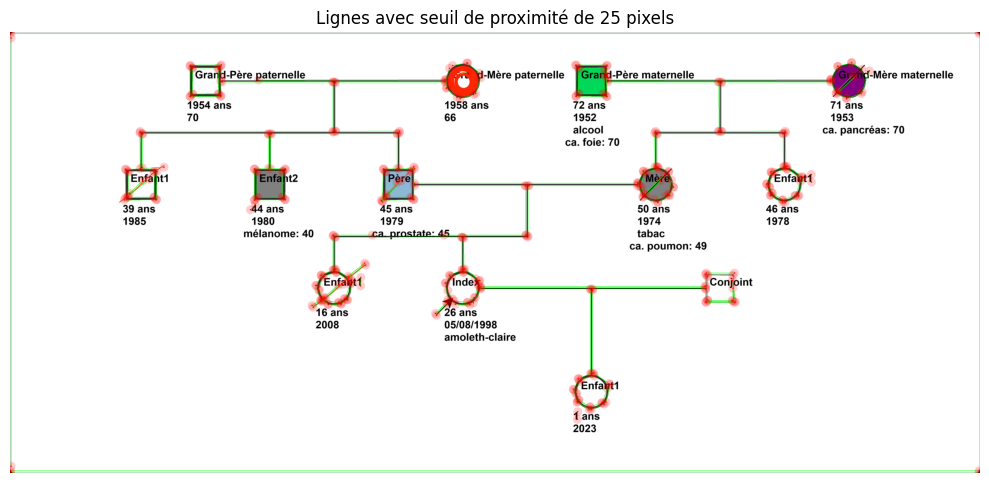

In [17]:
def afficher_lignes_avec_cercles_proximite(image_originale, lignes, seuil_proximite=10):
    """
    Affiche l'image originale avec les lignes détectées, en ajoutant des cercles de proximité autour de chaque point.
    Les cercles représentent le seuil de proximité pour uniformiser les points proches.
    """
    image_avec_lignes = image_originale.copy()

    for ligne in lignes:
        x1, y1, x2, y2 = map(int, ligne)
        
        # dessiner la ligne en vert
        cv2.line(image_avec_lignes, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # dessiner le point de départ et d'arrivée en rouge avec cercle de proximité translucide
        for (x, y) in [(x1, y1), (x2, y2)]:
            cv2.circle(image_avec_lignes, (x, y), radius=4, color=(0, 0, 255), thickness=-1)
            
            # add le cercle de proximité
            overlay = image_avec_lignes.copy()
            cv2.circle(overlay, (x, y), radius=seuil_proximite, color=(0, 0, 255), thickness=-1)
            cv2.addWeighted(overlay, 0.2, image_avec_lignes, 0.8, 0, image_avec_lignes)

    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(image_avec_lignes, cv2.COLOR_BGR2RGB))
    plt.title(f'Lignes avec seuil de proximité de {seuil_proximite} pixels')
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# afficher les lignes avec les cercles de proximité
afficher_lignes_avec_cercles_proximite(image, lignes_reduites, seuil_proximite=25)

[4034.03203125, 283.2462804079056, 4652.66953125, 283.26345534324645]
[3389.619017601013, 283.20026206970215, 4016.8487051010134, 283.02300624847413]
[4034.03203125, 283.2462804079056, 4654.033561992645, 275.42788274288176]
[3389.614297771454, 272.4651408433914, 4034.03203125, 283.2462804079056]

Nombre de lignes avant uniformisation : 204
Nombre de lignes après uniformisation : 147


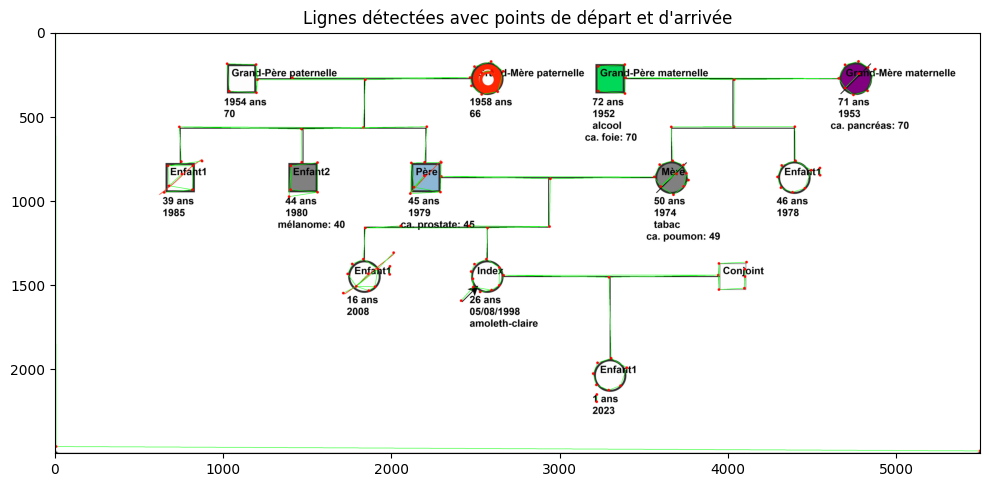

Output()

In [18]:
def uniformiser_lignes(lignes, seuil_proximite=25):
    """
    Uniformise les points de départ et de fin des lignes en rendant identiques
    les points très proches les uns des autres.
    """
    points = []

    # on collecte tous les points de début et de fin des lignes
    for ligne in lignes:
        points.append([ligne[0], ligne[1]])  # Starting point
        points.append([ligne[2], ligne[3]])  # Ending point

    # pour vérifier si deux points sont proches
    def points_proches(p1, p2, seuil):
        return np.linalg.norm(np.array(p1) - np.array(p2)) < seuil

    # uniformiser les points en les rendant identiques lorsqu'ils sont proches
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            if points_proches(points[i], points[j], seuil_proximite):
                # replace directement le point j par le point i
                points[j] = points[i]

    # Replace les points dans les lignes
    lignes_uniformisees = []
    for i in range(0, len(points), 2):
        lignes_uniformisees.append([points[i][0], points[i][1], points[i + 1][0], points[i + 1][1]])

    return lignes_uniformisees

def supprimer_doublons_lignes(lignes):
    """
    Supprime les lignes strictement superposées, c'est-à-dire celles ayant les mêmes points de départ et de fin.
    """
    lignes_uniques = []
    lignes_vues = set()

    for ligne in lignes:
        # trier les points pour ne pas distinguer entre les deux ordres de points
        point1 = (min(ligne[0], ligne[2]), min(ligne[1], ligne[3]))
        point2 = (max(ligne[0], ligne[2]), max(ligne[1], ligne[3]))
        identifiant_ligne = (point1, point2)

        if identifiant_ligne not in lignes_vues:
            lignes_vues.add(identifiant_ligne)
            lignes_uniques.append(ligne)

    return lignes_uniques

# apply la suppression des doublons stricts
lignes_uniformisees = uniformiser_lignes(lignes_reduites, seuil_proximite=40)
lignes_sans_doublons = supprimer_doublons_lignes(lignes_uniformisees)

print(lignes_reduites[5])
print(lignes_reduites[8])
print(lignes_uniformisees[5])
print(lignes_uniformisees[8])
print()
print("Nombre de lignes avant uniformisation :", len(lignes_reduites))
print("Nombre de lignes après uniformisation :", len(lignes_sans_doublons))
# affichage des lignes uniformisées
afficher_lignes_sur_image_originale(image, lignes_sans_doublons)
navigator = LineNavigator(image, lignes_sans_doublons, seuil_proximite=50)

## Supprimer les lignes sur les figures et prolonger les lignes 

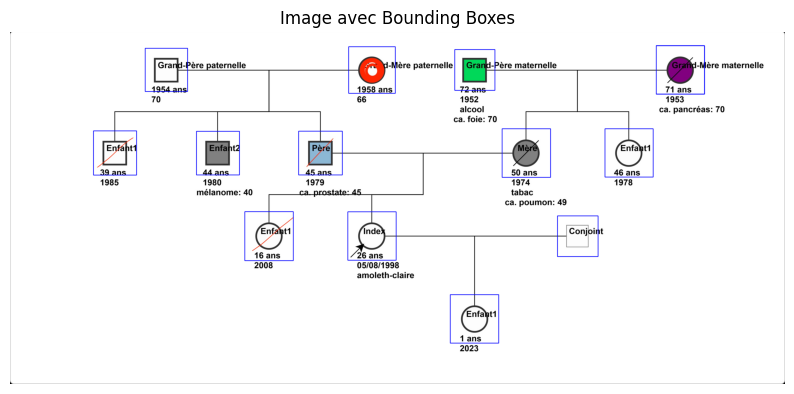

Nombre de lignes originales : 147
Nombre de lignes après filtrage : 38
Ligne filtrée : [4654.033561992645, 275.42788274288176, 3389.614297771454, 272.4651408433914]
Ligne filtrée : [4034.03203125, 283.2462804079056, 4654.033561992645, 275.42788274288176]
Ligne filtrée : [3389.614297771454, 272.4651408433914, 4034.03203125, 283.2462804079056]
Ligne filtrée : [4033.335856389999, 562.7944432497025, 4034.03203125, 283.2462804079056]
Ligne filtrée : [4033.335856389999, 562.7944432497025, 3660.2679418087005, 563.0303036212921]
Ligne filtrée : [4394.911248207092, 562.8744181394577, 4033.335856389999, 562.7944432497025]
Ligne filtrée : [3668.039927816391, 764.7115050315857, 3660.2679418087005, 563.0303036212921]
Ligne filtrée : [3660.2679418087005, 563.0303036212921, 4394.911248207092, 562.8744181394577]
Ligne filtrée : [4398.61369228363, 764.7067852020264, 4394.911248207092, 562.8744181394577]
Ligne filtrée : [2942.8281519412994, 871.7370490550995, 3559.28981051445, 860.6118863582611]
Ligne f

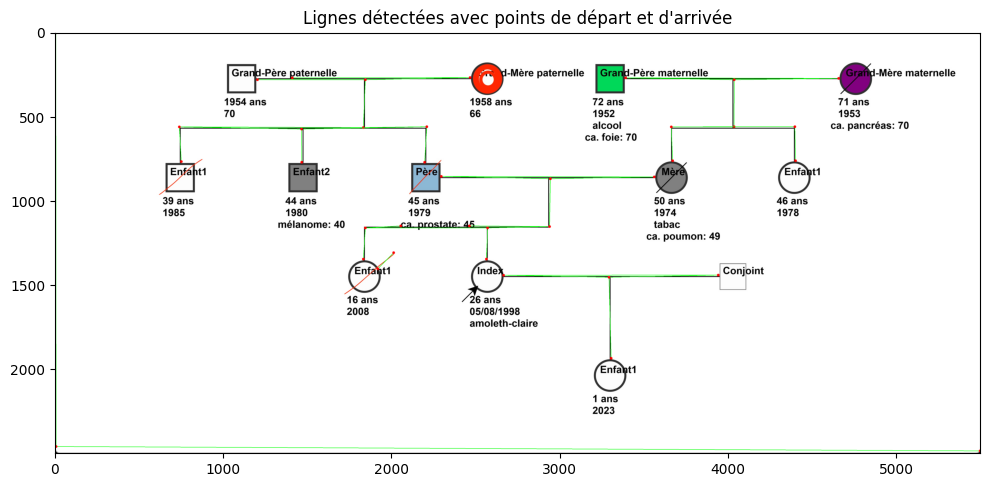

In [19]:
def est_dans_bounding_box(bbox, point):
    """
    Vérifie si un point est à l'intérieur d'une bounding box.
    """
    x_min, y_min, x_max, y_max = bbox
    x, y = point
    return x_min <= x <= x_max and y_min <= y <= y_max

def augmenter_bounding_boxes(bounding_boxes, pourcentage=10):
    """
    Augmente les dimensions des bounding boxes de manière proportionnelle.
    """
    bounding_boxes_etendues = []
    for bbox in bounding_boxes:
        x_min, y_min, x_max, y_max = bbox
        largeur = x_max - x_min
        hauteur = y_max - y_min
        marge_x = int(largeur * pourcentage / 100)
        marge_y = int(hauteur * pourcentage / 100)
        
        bbox_etendue = (x_min - marge_x, y_min - marge_y, x_max + marge_x, y_max + marge_y)
        bounding_boxes_etendues.append(bbox_etendue)
    return bounding_boxes_etendues

def afficher_bounding_boxes(image, bounding_boxes):
    """
    Affiche les bounding boxes sur l'image pour validation visuelle.
    """
    img_copie = image.copy()
    for bbox in bounding_boxes:
        x_min, y_min, x_max, y_max = bbox
        cv2.rectangle(img_copie, (x_min, y_min), (x_max, y_max), (255, 0, 0), 3)  # Bounding boxes en bleu
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(img_copie, cv2.COLOR_BGR2RGB))
    plt.title("Image avec Bounding Boxes")
    plt.axis("off")
    plt.show()

def filtrer_lignes_dans_bbox(lignes, bounding_boxes):
    """
    Supprime les lignes qui se trouvent entièrement dans une des bounding boxes.
    """
    lignes_filtrees = []
    for ligne in lignes:
        x1, y1, x2, y2 = ligne
        # verif si les deux points de la ligne sont dans la même bounding box
        if not any(est_dans_bounding_box(bbox, (x1, y1)) and est_dans_bounding_box(bbox, (x2, y2)) for bbox in bounding_boxes):
            lignes_filtrees.append(ligne)
    return lignes_filtrees

# etendre les bounding boxes de YOLO
bounding_boxes_etendues = augmenter_bounding_boxes(bounding_boxes_yolo, pourcentage=45)

# les bounding boxes sur l'image pour validation
afficher_bounding_boxes(image, bounding_boxes_etendues)

# filtrer les lignes avec les nouvelles bounding boxes
lignes_filtrees = filtrer_lignes_dans_bbox(lignes_sans_doublons, bounding_boxes_etendues)

# print les lignes restantes sur l'image
print(f"Nombre de lignes originales : {len(lignes_sans_doublons)}")
print(f"Nombre de lignes après filtrage : {len(lignes_filtrees)}")
for ligne in lignes_filtrees:
    print(f"Ligne filtrée : {ligne}")

afficher_lignes_sur_image_originale(image, lignes_filtrees)


** Assignation : Ligne line_1 assignée à Bounding Box (3155, 130, 3441, 420), endpoints_in_bbox: [False, True]
** Assignation : Ligne line_1 assignée à Bounding Box (4586, 102, 4928, 447), endpoints_in_bbox: [True, False]
** Assignation : Ligne line_1 assignée à Bounding Box (4585, 104, 4929, 446), endpoints_in_bbox: [True, False]
** Assignation : Ligne line_2 assignée à Bounding Box (4586, 102, 4928, 447), endpoints_in_bbox: [False, True]
** Assignation : Ligne line_2 assignée à Bounding Box (4585, 104, 4929, 446), endpoints_in_bbox: [False, True]
** Assignation : Ligne line_3 assignée à Bounding Box (3155, 130, 3441, 420), endpoints_in_bbox: [True, False]
** Assignation : Ligne line_4 non assignée à aucune Bounding Box
** Assignation : Ligne line_5 non assignée à aucune Bounding Box
** Assignation : Ligne line_6 non assignée à aucune Bounding Box
** Assignation : Ligne line_7 assignée à Bounding Box (3491, 691, 3836, 1036), endpoints_in_bbox: [True, False]
** Assignation : Ligne line

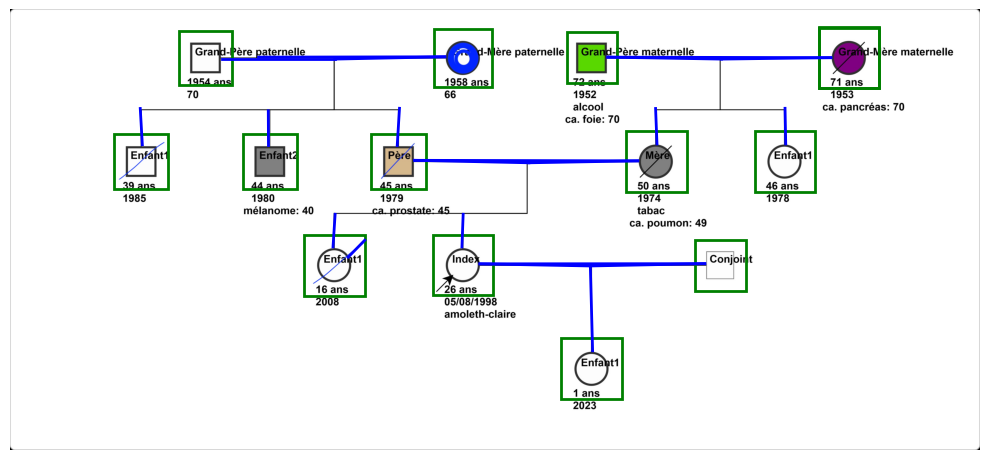


Dictionnaire des lignes avec leurs attributs :
{'id': 'line_1', 'coords': [4654.033561992645, 275.42788274288176, 3389.614297771454, 272.4651408433914], 'IsInBoundingboxes': [(3155, 130, 3441, 420), (4586, 102, 4928, 447), (4585, 104, 4929, 446)]}
{'id': 'line_2', 'coords': [4034.03203125, 283.2462804079056, 4654.033561992645, 275.42788274288176], 'IsInBoundingboxes': [(4586, 102, 4928, 447), (4585, 104, 4929, 446)]}
{'id': 'line_3', 'coords': [3389.614297771454, 272.4651408433914, 4034.03203125, 283.2462804079056], 'IsInBoundingboxes': [(3155, 130, 3441, 420)]}
{'id': 'line_4', 'coords': [4033.335856389999, 562.7944432497025, 4034.03203125, 283.2462804079056], 'IsInBoundingboxes': []}
{'id': 'line_5', 'coords': [4033.335856389999, 562.7944432497025, 3660.2679418087005, 563.0303036212921], 'IsInBoundingboxes': []}
{'id': 'line_6', 'coords': [4394.911248207092, 562.8744181394577, 4033.335856389999, 562.7944432497025], 'IsInBoundingboxes': []}
{'id': 'line_7', 'coords': [3668.0399278163

In [20]:


def est_dans_bounding_box(bbox, point):
    """
    Vérifie si un point est à l'intérieur d'une bounding box.
    
    :param bbox: Tuple (x_min, y_min, x_max, y_max).
    :param point: Tuple (x, y).
    :return: True si le point est dans la bounding box, sinon False.
    """
    x_min, y_min, x_max, y_max = bbox
    x, y = point
    return x_min <= x <= x_max and y_min <= y <= y_max

def augmenter_bounding_boxes(bounding_boxes, pourcentage):
    """
    Augmente la taille des bounding boxes de manière proportionnelle.
    
    :param bounding_boxes: Liste de bounding boxes [(x_min, y_min, x_max, y_max)].
    :param pourcentage: Pourcentage d'augmentation (ex : 45 pour 45%).
    :return: Liste de bounding boxes augmentées.
    """
    bounding_boxes_etendues = []
    for x_min, y_min, x_max, y_max in bounding_boxes:
        largeur = x_max - x_min
        hauteur = y_max - y_min
        delta_x = largeur * (pourcentage / 100)
        delta_y = hauteur * (pourcentage / 100)
        bounding_boxes_etendues.append((
            int(x_min - delta_x), int(y_min - delta_y),
            int(x_max + delta_x), int(y_max + delta_y)
        ))
    return bounding_boxes_etendues

def assigner_bounding_boxes_aux_lignes(lignes, bounding_boxes):
    """
    Assigne une ou plusieurs bounding boxes à chaque ligne si ses points sont dans ces bounding boxes.

    :param lignes: Liste des lignes [[x1, y1, x2, y2], ...].
    :param bounding_boxes: Liste des bounding boxes [(x_min, y_min, x_max, y_max), ...].
    :return: Liste de dictionnaires pour chaque ligne avec 'id', 'coords', et 'IsInBoundingboxes'.
    """
    lignes_dict = []
    for idx, ligne in enumerate(lignes):
        x1, y1, x2, y2 = ligne
        ligne_dict = {
            'id': f'line_{idx+1}',
            'coords': [x1, y1, x2, y2],
            'IsInBoundingboxes': []  # Liste de bounding boxes
        }
        for bbox in bounding_boxes:
            start_in_bbox = est_dans_bounding_box(bbox, (x1, y1))
            end_in_bbox = est_dans_bounding_box(bbox, (x2, y2))
            if start_in_bbox or end_in_bbox:
                ligne_dict['IsInBoundingboxes'].append(bbox)
                print(f"** Assignation : Ligne {ligne_dict['id']} assignée à Bounding Box {bbox}, endpoints_in_bbox: [{start_in_bbox}, {end_in_bbox}]")
        if not ligne_dict['IsInBoundingboxes']:
            print(f"** Assignation : Ligne {ligne_dict['id']} non assignée à aucune Bounding Box")
        lignes_dict.append(ligne_dict)
    return lignes_dict

def afficher_resultats(image, lignes_dict, bounding_boxes):
    """
    Affiche les lignes et les bounding boxes sur l'image en utilisant Matplotlib.
    
    :param image: Image d'origine (numpy array au format HxWxC).
    :param lignes_dict: Liste de dictionnaires des lignes avec 'coords' et 'IsInBoundingboxes'.
    :param bounding_boxes: Liste des bounding boxes [(x_min, y_min, x_max, y_max)].
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image)
    
    # dessiner les bounding boxes
    for bbox in bounding_boxes:
        x_min, y_min, x_max, y_max = bbox
        largeur = x_max - x_min
        hauteur = y_max - y_min
        rectangle = patches.Rectangle(
            (x_min, y_min), largeur, hauteur, linewidth=2, edgecolor='green', facecolor='none'
        )
        ax.add_patch(rectangle)
    
    # dessiner uniquement les lignes qui sont dans des bounding boxes
    for ligne in lignes_dict:
        if ligne['IsInBoundingboxes']:  # verif si la liste n'est pas vide
            try:
                x1, y1, x2, y2 = map(int, ligne['coords'])
                ax.plot([x1, x2], [y1, y2], color='blue', linewidth=2)
            except Exception as e:
                print(f"Erreur lors du dessin de la ligne {ligne['coords']}: {e}")
    
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# etendre les bounding boxes de YOLO de 45 %
bounding_boxes_etendues = augmenter_bounding_boxes(bounding_boxes_yolo, pourcentage=45)

# assigner les bounding boxes aux lignes
lignes_dict = assigner_bounding_boxes_aux_lignes(lignes_filtrees, bounding_boxes_etendues)

print(f"Nombre de lignes traitées : {len(lignes_dict)}")
for ligne in lignes_dict:
    print(f"Ligne ID: {ligne['id']}, Coordonnées: {ligne['coords']}, IsInBoundingboxes: {ligne['IsInBoundingboxes']}")

print("Affichage des lignes avec attribut IsInBoundingbox :")
afficher_resultats(image, lignes_dict, bounding_boxes_etendues)

print("\nDictionnaire des lignes avec leurs attributs :")
for ligne in lignes_dict:
    print(ligne)

Nombre de lignes traitées : 38
Ligne ID: line_1, Coordonnées: [4654.033561992645, 275.42788274288176, 3389.614297771454, 272.4651408433914], IsInBoundingboxes: [(3155, 130, 3441, 420), (4586, 102, 4928, 447), (4585, 104, 4929, 446)]
Ligne ID: line_2, Coordonnées: [4034.03203125, 283.2462804079056, 4654.033561992645, 275.42788274288176], IsInBoundingboxes: [(4586, 102, 4928, 447), (4585, 104, 4929, 446)]
Ligne ID: line_3, Coordonnées: [3389.614297771454, 272.4651408433914, 4034.03203125, 283.2462804079056], IsInBoundingboxes: [(3155, 130, 3441, 420)]
Ligne ID: line_4, Coordonnées: [4033.335856389999, 562.7944432497025, 4034.03203125, 283.2462804079056], IsInBoundingboxes: []
Ligne ID: line_5, Coordonnées: [4033.335856389999, 562.7944432497025, 3660.2679418087005, 563.0303036212921], IsInBoundingboxes: []
Ligne ID: line_6, Coordonnées: [4394.911248207092, 562.8744181394577, 4033.335856389999, 562.7944432497025], IsInBoundingboxes: []
Ligne ID: line_7, Coordonnées: [3668.039927816391, 764

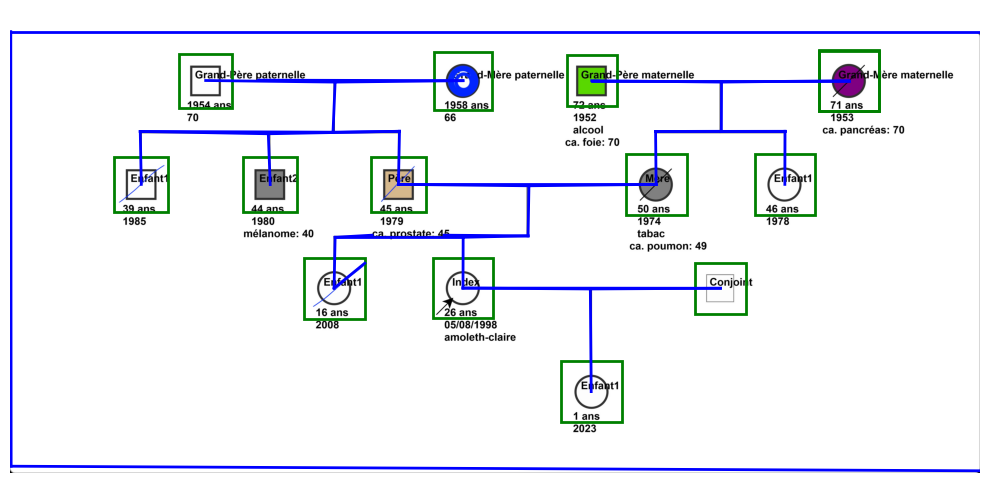


Dictionnaire des lignes avec leurs attributs après ajustement :
{'id': 'line_1', 'coords': [4757.0, 275.0, 3298.0, 275.0], 'IsInBoundingboxes': [(3155, 130, 3441, 420), (4586, 102, 4928, 447), (4585, 104, 4929, 446)]}
{'id': 'line_2', 'coords': [4034.03203125, 283.2462804079056, 4757.0, 275.0], 'IsInBoundingboxes': [(4586, 102, 4928, 447), (4585, 104, 4929, 446)]}
{'id': 'line_3', 'coords': [3298.0, 275.0, 4034.03203125, 283.2462804079056], 'IsInBoundingboxes': [(3155, 130, 3441, 420)]}
{'id': 'line_4', 'coords': [4033.335856389999, 562.7944432497025, 4034.03203125, 283.2462804079056], 'IsInBoundingboxes': []}
{'id': 'line_5', 'coords': [4033.335856389999, 562.7944432497025, 3660.2679418087005, 563.0303036212921], 'IsInBoundingboxes': []}
{'id': 'line_6', 'coords': [4394.911248207092, 562.8744181394577, 4033.335856389999, 562.7944432497025], 'IsInBoundingboxes': []}
{'id': 'line_7', 'coords': [3663.5, 863.5, 3660.2679418087005, 563.0303036212921], 'IsInBoundingboxes': [(3491, 691, 383

In [21]:
def est_dans_bounding_box(bbox, point):
    """
    Vérifie si un point est à l'intérieur d'une bounding box.
    
    :param bbox: Tuple (x_min, y_min, x_max, y_max).
    :param point: Tuple (x, y).
    :return: True si le point est dans la bounding box, sinon False.
    """
    x_min, y_min, x_max, y_max = bbox
    x, y = point
    return x_min <= x <= x_max and y_min <= y <= y_max

def augmenter_bounding_boxes(bounding_boxes, pourcentage):
    """
    Augmente la taille des bounding boxes de manière proportionnelle.
    
    :param bounding_boxes: Liste de bounding boxes [(x_min, y_min, x_max, y_max)].
    :param pourcentage: Pourcentage d'augmentation (ex : 45 pour 45%).
    :return: Liste de bounding boxes augmentées.
    """
    bounding_boxes_etendues = []
    for x_min, y_min, x_max, y_max in bounding_boxes:
        largeur = x_max - x_min
        hauteur = y_max - y_min
        delta_x = largeur * (pourcentage / 100)
        delta_y = hauteur * (pourcentage / 100)
        bounding_boxes_etendues.append((
            int(x_min - delta_x), int(y_min - delta_y),
            int(x_max + delta_x), int(y_max + delta_y)
        ))
    return bounding_boxes_etendues

def calculer_distance(point1, point2):
    """
    Calcule la distance euclidienne entre deux points.
    
    :param point1: Tuple (x, y).
    :param point2: Tuple (x, y).
    :return: Distance euclidienne.
    """
    return np.sqrt((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)

def calculer_moyenne_points(points):
    """
    Calcule la moyenne des points donnés.
    
    :param points: Liste de tuples [(x1, y1), (x2, y2), ...].
    :return: Tuple (x_moyen, y_moyen).
    """
    if not points:
        return None
    x_moyen = int(np.mean([p[0] for p in points]))
    y_moyen = int(np.mean([p[1] for p in points]))
    return (x_moyen, y_moyen)

def calculer_moyennes_bounding_boxes(lignes_dict, bounding_boxes):
    """
    Calcule la moyenne des points des extrémités des lignes dans chaque bounding box.

    :param lignes_dict: Liste de dictionnaires des lignes avec 'coords' et 'IsInBoundingboxes'.
    :param bounding_boxes: Liste des bounding boxes [(x_min, y_min, x_max, y_max)].
    :return: Dictionnaire {bounding_box: (x_moyen, y_moyen), ...}.
    """
    moyennes = {}

    for bbox in bounding_boxes:
        points_proches = []

        for ligne in lignes_dict:
            if bbox in ligne['IsInBoundingboxes']:
                x1, y1, x2, y2 = ligne['coords']
                # verif quels points de la ligne sont dans la bounding box
                if est_dans_bounding_box(bbox, (x1, y1)):
                    points_proches.append((x1, y1))
                    print(f"** Bounding Box {bbox} : Ligne {ligne['id']} start point {x1, y1} ajouté")
                if est_dans_bounding_box(bbox, (x2, y2)):
                    points_proches.append((x2, y2))
                    print(f"** Bounding Box {bbox} : Ligne {ligne['id']} end point {x2, y2} ajouté")

        # calcul de la moyenne
        moyenne = calculer_moyenne_points(points_proches)
        moyennes[bbox] = moyenne
        print(f"** Bounding Box {bbox} : Moyenne calculée {moyenne}")

    return moyennes

def calculer_centres_bounding_boxes(bounding_boxes):
    """
    Calcule le centre de chaque bounding box.

    :param bounding_boxes: Liste des bounding boxes [(x_min, y_min, x_max, y_max)].
    :return: Dictionnaire {bounding_box: (x_center, y_center), ...}.
    """
    centres = {}

    for bbox in bounding_boxes:
        # calcul du centre de la bounding box
        center_x = (bbox[0] + bbox[2]) / 2  # Le centre en x
        center_y = (bbox[1] + bbox[3]) / 2  # Le centre en y
        centres[bbox] = (center_x, center_y)

    return centres

def mettre_a_jour_lignes_avec_moyenne(lignes_dict, moyennes):
    """
    Met à jour les lignes en remplaçant les points dans les bounding boxes par les moyennes calculées.

    :param lignes_dict: Liste de dictionnaires des lignes avec 'coords' et 'IsInBoundingboxes'.
    :param moyennes: Dictionnaire {bounding_box: (x_moyen, y_moyen), ...}.
    :return: Liste de lignes ajustées [[x1, y1, x2, y2], ...].
    """
    lignes_ajustees = []

    for ligne in lignes_dict:
        x1, y1, x2, y2 = ligne['coords']
        updated = False  # Flag pour vérifier si la ligne a été mise à jour

        for bbox in ligne['IsInBoundingboxes']:
            if moyennes.get(bbox):
                moyenne = moyennes[bbox]
                # replace les points qui sont dans la bounding box par la moyenne
                if est_dans_bounding_box(bbox, (x1, y1)):
                    print(f"** Mise à jour : Ligne {ligne['id']} - Remplacement du point de départ ({x1}, {y1}) par {moyenne}")
                    x1, y1 = moyenne
                    updated = True
                if est_dans_bounding_box(bbox, (x2, y2)):
                    print(f"** Mise à jour : Ligne {ligne['id']} - Remplacement du point d'arrivée ({x2}, {y2}) par {moyenne}")
                    x2, y2 = moyenne
                    updated = True

        if updated:
            lignes_ajustees.append([x1, y1, x2, y2])
        else:
            # si la ligne n'est pas dans une bounding box, la garder inchangée
            lignes_ajustees.append(ligne['coords'])

    return lignes_ajustees

def afficher_resultats(image, lignes_dict, bounding_boxes):
    """
    Affiche les lignes et les bounding boxes sur l'image en utilisant Matplotlib.
    
    :param image: Image d'origine (numpy array au format HxWxC).
    :param lignes_dict: Liste de dictionnaires des lignes avec 'coords' et 'IsInBoundingbox'.
    :param bounding_boxes: Liste des bounding boxes [(x_min, y_min, x_max, y_max)].
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image)
    
    # dessinner les bounding boxes
    for bbox in bounding_boxes:
        x_min, y_min, x_max, y_max = bbox
        largeur = x_max - x_min
        hauteur = y_max - y_min
        rectangle = patches.Rectangle(
            (x_min, y_min), largeur, hauteur, linewidth=2, edgecolor='green', facecolor='none'
        )
        ax.add_patch(rectangle)
    
    # dessiner uniquement les lignes qui sont dans des bounding boxes
    for ligne in lignes_dict:
        try:
            x1, y1, x2, y2 = map(int, ligne['coords'])
            ax.plot([x1, x2], [y1, y2], color='blue', linewidth=2)
        except Exception as e:
            print(f"Erreur lors du dessin de la ligne {ligne['coords']}: {e}")
    
    # config et afficher l'image
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# les lignes traitées avec leurs attributs
print(f"Nombre de lignes traitées : {len(lignes_dict)}")
for ligne in lignes_dict:
    print(f"Ligne ID: {ligne['id']}, Coordonnées: {ligne['coords']}, IsInBoundingboxes: {ligne['IsInBoundingboxes']}")

# calculer les moyennes des points les plus proches pour chaque bounding box
#moyennes = calculer_moyennes_bounding_boxes(lignes_dict, bounding_boxes_etendues)
moyennes = calculer_centres_bounding_boxes(bounding_boxes_etendues)
# les moyennes calculées
print("\nMoyennes des points les plus proches pour chaque bounding box :")
for bbox, moyenne in moyennes.items():
    print(f"BoundingBox: {bbox}, Moyenne: {moyenne}")

# update les lignes avec les moyennes
lignes_ajustees = mettre_a_jour_lignes_avec_moyenne(lignes_dict, moyennes)

# les lignes ajustées
print(f"\nNombre de lignes ajustées : {len(lignes_ajustees)}")
for idx, ligne in enumerate(lignes_ajustees, start=1):
    print(f"Ligne ajustée {idx}: {ligne}")

# update les lignes_dict avec les nouvelles coordonnées
for i, ligne in enumerate(lignes_dict):
    if ligne['IsInBoundingboxes']:  
        lignes_dict[i]['coords'] = lignes_ajustees[i]

# les résultats graphiques après ajustement
print("\nAffichage des lignes ajustées dans des bounding boxes :")
afficher_resultats(image, lignes_dict, bounding_boxes_etendues)

# le dictionnaire complet des lignes
print("\nDictionnaire des lignes avec leurs attributs après ajustement :")
for ligne in lignes_dict:
    print(ligne)

## Pour debug isInBoundingbox :

In [22]:
class LineNavigatorDict:
    def __init__(self, image, lignes_dict):
        """
        Initialise le navigateur de lignes.

        :param image: Image d'origine (numpy array au format HxWxC).
        :param lignes_dict: Liste de dictionnaires des lignes avec 'id', 'coords', et 'IsInBoundingbox'.
        """
        self.image = image.copy()
        self.lignes_dict = lignes_dict
        self.index = 0

        # widgets interactifs
        self.out_plot = Output()
        self.out_info = Output()
        self.button_prev = Button(description="⬅️ Précédent")
        self.button_next = Button(description="➡️ Suivant")
        self.button_prev.on_click(self.prev_line)
        self.button_next.on_click(self.next_line)

        # draw initial
        self.display_line()
        display(VBox([
            HBox([self.button_prev, self.button_next]),
            self.out_plot,
            self.out_info
        ]))

    def display_line(self):
        with self.out_plot:
            self.out_plot.clear_output(wait=True)
            ligne = self.lignes_dict[self.index]
            img_with_line = self.image.copy()

            x1, y1, x2, y2 = map(int, ligne['coords'])
            # dessiner la ligne en bleu
            cv2.line(img_with_line, (x1, y1), (x2, y2), (0, 0, 255), 2)

            # convertir l'image de BGR à RGB pour l'affichage avec matplotlib
            img_rgb = cv2.cvtColor(img_with_line, cv2.COLOR_BGR2RGB)

            # l'image avec la ligne
            plt.figure(figsize=(8, 8))
            plt.imshow(img_rgb)
            plt.title(f"Ligne {ligne['id']}")
            plt.axis("off")
            plt.show()

        with self.out_info:
            self.out_info.clear_output(wait=True)
            ligne = self.lignes_dict[self.index]
            id_label = f"Ligne ID: {ligne['id']}"
            coords_label = f"Coordonnées: {ligne['coords']}"
            bbox_label = f"IsInBoundingbox: {ligne['IsInBoundingbox']}"
            display(VBox([
                Label(id_label),
                Label(coords_label),
                Label(bbox_label)
            ]))

    def prev_line(self, _):
        if self.index > 0:
            self.index -= 1
            self.display_line()

    def next_line(self, _):
        if self.index < len(self.lignes_dict) - 1:
            self.index += 1
            self.display_line()


navigator = LineNavigatorDict(image, lignes_dict)

# Virer les lignes non connexes au sous graphe le plus grand  -> concession sur les arbres détachés par contre ! Donc à partir de là le programme ne marchera pas pour les forêts en théorie des graphes d'arbres généalogiques


Plus grand composant connexe contient 31 nodes.

Nombre de lignes dans le plus grand composant connexe : 35
Ligne ID: line_1, Coordonnées: [4757.0, 275.0, 3298.0, 275.0], IsInBoundingbox: (3155, 130, 3441, 420)
Ligne ID: line_2, Coordonnées: [4034.03203125, 283.2462804079056, 4757.0, 275.0], IsInBoundingbox: (4586, 102, 4928, 447)
Ligne ID: line_3, Coordonnées: [3298.0, 275.0, 4034.03203125, 283.2462804079056], IsInBoundingbox: (3155, 130, 3441, 420)
Ligne ID: line_4, Coordonnées: [4033.335856389999, 562.7944432497025, 4034.03203125, 283.2462804079056], IsInBoundingbox: None
Ligne ID: line_5, Coordonnées: [4033.335856389999, 562.7944432497025, 3660.2679418087005, 563.0303036212921], IsInBoundingbox: None
Ligne ID: line_6, Coordonnées: [4394.911248207092, 562.8744181394577, 4033.335856389999, 562.7944432497025], IsInBoundingbox: None
Ligne ID: line_7, Coordonnées: [3663.5, 863.5, 3660.2679418087005, 563.0303036212921], IsInBoundingbox: (3491, 691, 3836, 1036)
Ligne ID: line_8, Coordonn

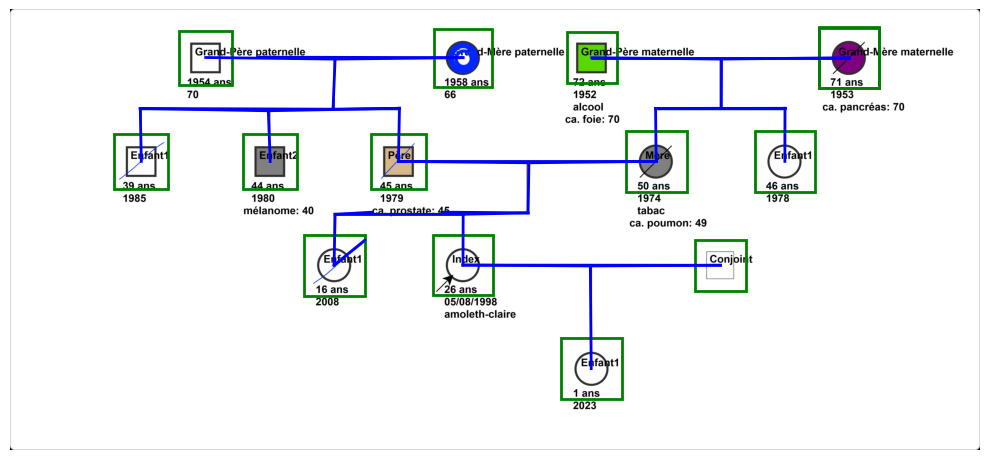


Dictionnaire des lignes dans le plus grand composant connexe :
{'id': 'line_1', 'coords': [4757.0, 275.0, 3298.0, 275.0], 'IsInBoundingbox': (3155, 130, 3441, 420)}
{'id': 'line_2', 'coords': [4034.03203125, 283.2462804079056, 4757.0, 275.0], 'IsInBoundingbox': (4586, 102, 4928, 447)}
{'id': 'line_3', 'coords': [3298.0, 275.0, 4034.03203125, 283.2462804079056], 'IsInBoundingbox': (3155, 130, 3441, 420)}
{'id': 'line_4', 'coords': [4033.335856389999, 562.7944432497025, 4034.03203125, 283.2462804079056], 'IsInBoundingbox': None}
{'id': 'line_5', 'coords': [4033.335856389999, 562.7944432497025, 3660.2679418087005, 563.0303036212921], 'IsInBoundingbox': None}
{'id': 'line_6', 'coords': [4394.911248207092, 562.8744181394577, 4033.335856389999, 562.7944432497025], 'IsInBoundingbox': None}
{'id': 'line_7', 'coords': [3663.5, 863.5, 3660.2679418087005, 563.0303036212921], 'IsInBoundingbox': (3491, 691, 3836, 1036)}
{'id': 'line_8', 'coords': [3660.2679418087005, 563.0303036212921, 4394.911248

In [23]:
def construire_graphe(lignes):
    """
    Construit un graphe à partir des lignes.
    
    :param lignes: Liste de lignes [[x1, y1, x2, y2], ...].
    :return: Graphe NetworkX.
    """
    G = nx.Graph()
    for ligne in lignes:
        x1, y1, x2, y2 = ligne
        point1 = (x1, y1)
        point2 = (x2, y2)
        G.add_node(point1)
        G.add_node(point2)
        G.add_edge(point1, point2)
    return G

def obtenir_plus_grand_composant(G):
    """
    Obtient le plus grand composant connexe du graphe.
    
    :param G: Graphe NetworkX.
    :return: Ensemble de nodes dans le plus grand composant connexe.
    """
    composants = list(nx.connected_components(G))
    if not composants:
        return set()
    # trier les composants par taille décroissante et retourner le premier
    composants.sort(key=lambda x: len(x), reverse=True)
    return composants[0]

def filtrer_lignes_graphe(lignes, plus_grand_composant):
    """
    Filtre les lignes pour ne conserver que celles appartenant au plus grand composant connexe.
    
    :param lignes: Liste de lignes [[x1, y1, x2, y2], ...].
    :param plus_grand_composant: Ensemble de nodes dans le plus grand composant connexe.
    :return: Liste de lignes filtrées.
    """
    lignes_filtrees = []
    for ligne in lignes:
        x1, y1, x2, y2 = ligne
        point1 = (x1, y1)
        point2 = (x2, y2)
        if point1 in plus_grand_composant and point2 in plus_grand_composant:
            lignes_filtrees.append(ligne)
    return lignes_filtrees

# build le graphe à partir des lignes ajustées
G = construire_graphe(lignes_ajustees)

# get le plus grand composant connexe
plus_grand_composant = obtenir_plus_grand_composant(G)
print(f"\nPlus grand composant connexe contient {len(plus_grand_composant)} nodes.")

# filtrer les lignes pour ne conserver que celles du plus grand composant connexe
lignes_filtrees_graphe = filtrer_lignes_graphe(lignes_ajustees, plus_grand_composant)

# update le dictionnaire des lignes pour refléter le filtrage
lignes_dict_filtrees = []
for idx, ligne in enumerate(lignes_filtrees_graphe):
    x1, y1, x2, y2 = ligne
    # identifier la bounding box correspondante
    bbox_associee = None
    for bbox in bounding_boxes_etendues:
        if est_dans_bounding_box(bbox, (x1, y1)) or est_dans_bounding_box(bbox, (x2, y2)):
            bbox_associee = bbox
            break
    ligne_dict = {
        'id': f'line_{idx+1}',
        'coords': [x1, y1, x2, y2],
        'IsInBoundingbox': bbox_associee
    }
    lignes_dict_filtrees.append(ligne_dict)

# les lignes filtrées
print(f"\nNombre de lignes dans le plus grand composant connexe : {len(lignes_filtrees_graphe)}")
for ligne in lignes_dict_filtrees:
    print(f"Ligne ID: {ligne['id']}, Coordonnées: {ligne['coords']}, IsInBoundingbox: {ligne['IsInBoundingbox']}")

# les résultats graphiques après filtrage
print("\nAffichage des lignes dans le plus grand composant connexe :")
afficher_resultats(image, lignes_dict_filtrees, bounding_boxes_etendues)

# le dictionnaire complet des lignes filtrées
print("\nDictionnaire des lignes dans le plus grand composant connexe :")
for ligne in lignes_dict_filtrees:
    print(ligne)

## Encoder les relations de hierarchie

Nombre de nodes dans le graphe final : 31
Nombre d'arêtes dans le graphe final : 35

Affichage des lignes dans le plus grand composant connexe avec coloration des nodes :


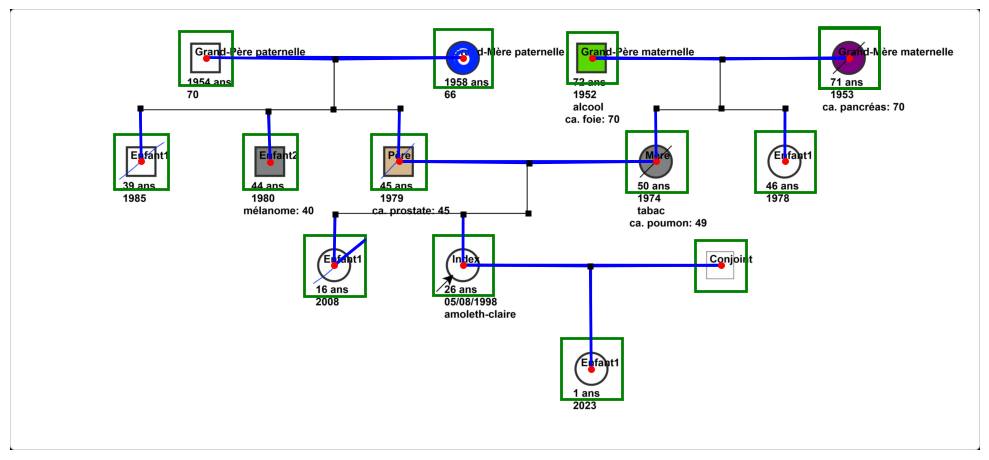


Visualisation du graphe avec les couleurs des nodes :


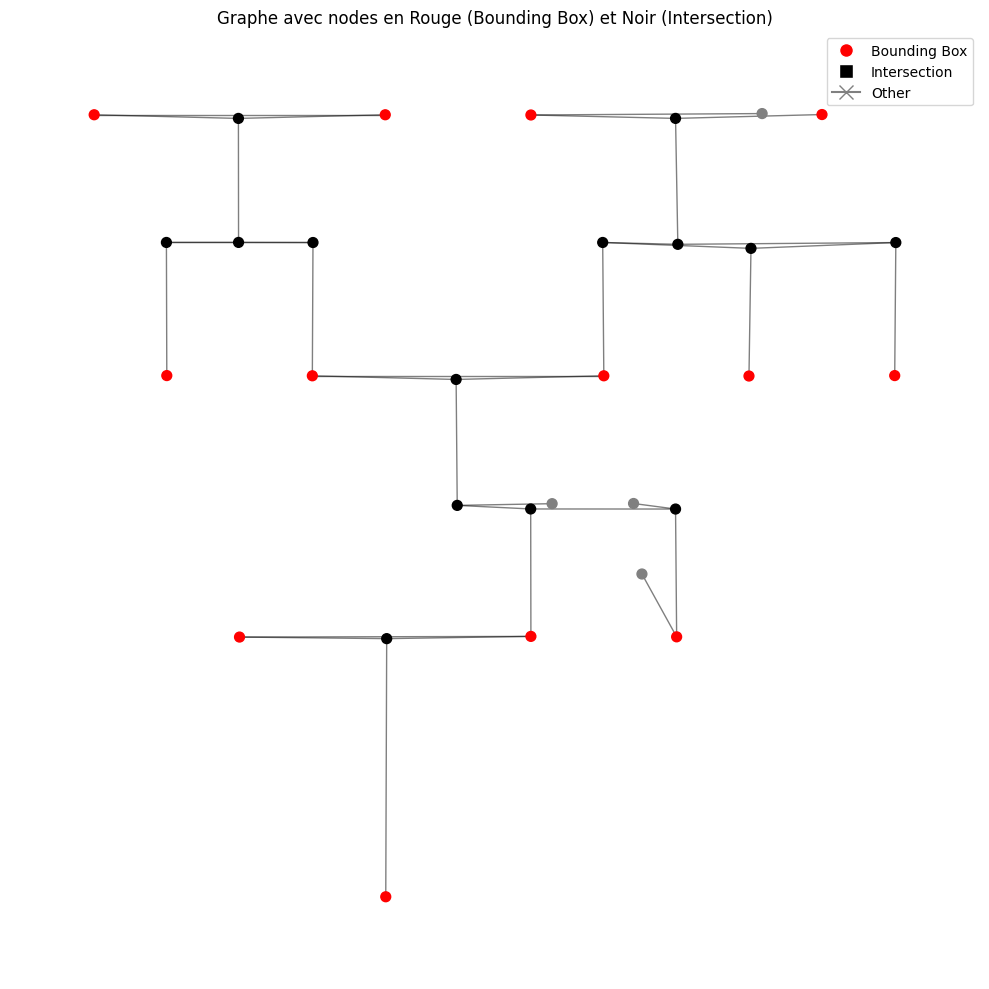


Dictionnaire des lignes dans le plus grand composant connexe :
{'id': 'line_1', 'coords': [4757.0, 275.0, 3298.0, 275.0], 'IsInBoundingbox': (3155, 130, 3441, 420)}
{'id': 'line_2', 'coords': [4034.03203125, 283.2462804079056, 4757.0, 275.0], 'IsInBoundingbox': (4586, 102, 4928, 447)}
{'id': 'line_3', 'coords': [3298.0, 275.0, 4034.03203125, 283.2462804079056], 'IsInBoundingbox': (3155, 130, 3441, 420)}
{'id': 'line_4', 'coords': [4033.335856389999, 562.7944432497025, 4034.03203125, 283.2462804079056], 'IsInBoundingbox': None}
{'id': 'line_5', 'coords': [4033.335856389999, 562.7944432497025, 3660.2679418087005, 563.0303036212921], 'IsInBoundingbox': None}
{'id': 'line_6', 'coords': [4394.911248207092, 562.8744181394577, 4033.335856389999, 562.7944432497025], 'IsInBoundingbox': None}
{'id': 'line_7', 'coords': [3663.5, 863.5, 3660.2679418087005, 563.0303036212921], 'IsInBoundingbox': (3491, 691, 3836, 1036)}
{'id': 'line_8', 'coords': [3660.2679418087005, 563.0303036212921, 4394.911248

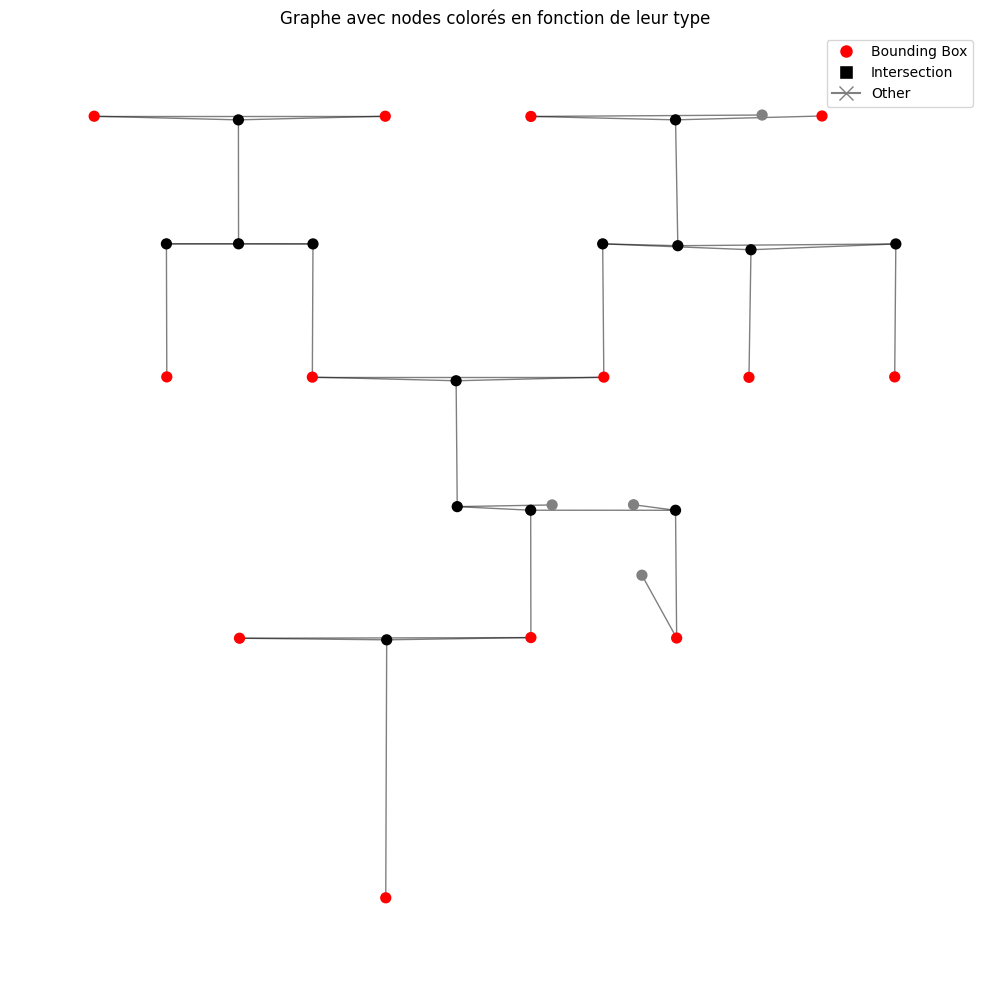

In [ ]:
def est_dans_bounding_box(bbox, point):
    """
    Vérifie si un point est à l'intérieur d'une bounding box.

    :param bbox: Tuple (x_min, y_min, x_max, y_max).
    :param point: Tuple (x, y).
    :return: True si le point est dans la bounding box, sinon False.
    """
    x_min, y_min, x_max, y_max = bbox
    x, y = point
    return x_min <= x <= x_max and y_min <= y <= y_max

def augmenter_bounding_boxes(bounding_boxes, pourcentage):
    """
    Augmente la taille des bounding boxes de manière proportionnelle.

    :param bounding_boxes: Liste de bounding boxes [(x_min, y_min, x_max, y_max)].
    :param pourcentage: Pourcentage d'augmentation (ex : 45 pour 45%).
    :return: Liste de bounding boxes augmentées.
    """
    bounding_boxes_etendues = []
    for x_min, y_min, x_max, y_max in bounding_boxes:
        largeur = x_max - x_min
        hauteur = y_max - y_min
        delta_x = largeur * (pourcentage / 100)
        delta_y = hauteur * (pourcentage / 100)
        bounding_boxes_etendues.append((
            int(x_min - delta_x), int(y_min - delta_y),
            int(x_max + delta_x), int(y_max + delta_y)
        ))
    return bounding_boxes_etendues

def calculer_distance(point1, point2):
    """
    Calcule la distance euclidienne entre deux points.

    :param point1: Tuple (x, y).
    :param point2: Tuple (x, y).
    :return: Distance euclidienne.
    """
    return np.sqrt((point1[0] - point2[0])**2 + (point1[1] - point2[1])**2)

def calculer_moyenne_points(points):
    """
    Calcule la moyenne des points donnés.

    :param points: Liste de tuples [(x1, y1), (x2, y2), ...].
    :return: Tuple (x_moyen, y_moyen).
    """
    if not points:
        return None
    x_moyen = int(np.mean([p[0] for p in points]))
    y_moyen = int(np.mean([p[1] for p in points]))
    return (x_moyen, y_moyen)

def calculer_moyennes_bounding_boxes(lignes_dict, bounding_boxes):
    """
    Calcule la moyenne des points les plus proches des lignes dans chaque bounding box.

    :param lignes_dict: Liste de dictionnaires des lignes avec 'coords' et 'IsInBoundingbox'.
    :param bounding_boxes: Liste des bounding boxes [(x_min, y_min, x_max, y_max)].
    :return: Dictionnaire {bounding_box: (x_moyen, y_moyen), ...}.
    """
    moyennes = {}

    for bbox in bounding_boxes:
        center_x = (bbox[0] + bbox[2]) / 2
        center_y = (bbox[1] + bbox[3]) / 2
        center = (center_x, center_y)

        points_proches = []

        for ligne in lignes_dict:
            if ligne['IsInBoundingbox'] == bbox:
                x1, y1, x2, y2 = ligne['coords']
                start = (x1, y1)
                end = (x2, y2)

                distance_start = calculer_distance(start, center)
                distance_end = calculer_distance(end, center)

                if distance_start < distance_end:
                    points_proches.append(start)
                else:
                    points_proches.append(end)

        moyenne = calculer_moyenne_points(points_proches)
        moyennes[bbox] = moyenne

    return moyennes

def mettre_a_jour_lignes_avec_moyenne(lignes_dict, moyennes):
    """
    Met à jour les lignes en remplaçant le point le plus proche par la moyenne calculée.

    :param lignes_dict: Liste de dictionnaires des lignes avec 'coords' et 'IsInBoundingbox'.
    :param moyennes: Dictionnaire {bounding_box: (x_moyen, y_moyen), ...}.
    :return: Liste de lignes ajustées [[x1, y1, x2, y2], ...].
    """
    lignes_ajustees = []

    for ligne in lignes_dict:
        bbox = ligne['IsInBoundingbox']
        if bbox is not None and moyennes[bbox] is not None:
            x1, y1, x2, y2 = ligne['coords']
            center = moyennes[bbox]

            # calculer les distances
            distance_start = calculer_distance((x1, y1), center)
            distance_end = calculer_distance((x2, y2), center)

            # identifier le point le plus proche
            if distance_start < distance_end:
                x1, y1 = center
            else:
                x2, y2 = center

            lignes_ajustees.append([x1, y1, x2, y2])
        else:
            # si la ligne n'est pas dans une bounding box, la garder inchangée
            lignes_ajustees.append(ligne['coords'])

    return lignes_ajustees

def construire_graphe(lignes):
    """
    Construit un graphe à partir des lignes.

    :param lignes: Liste de lignes [[x1, y1, x2, y2], ...].
    :return: Graphe NetworkX.
    """
    G = nx.Graph()
    i = 0
    for ligne in lignes:
        x1, y1, x2, y2 = ligne
        point1 = (x1, y1)
        point2 = (x2, y2)
        G.add_node(point1)
        G.add_node(point2)
        G.add_edge(point1, point2)
    return G

def obtenir_plus_grand_composant(G):
    """
    Obtient le plus grand composant connexe du graphe.

    :param G: Graphe NetworkX.
    :return: Ensemble de nodes dans le plus grand composant connexe.
    """
    composants = list(nx.connected_components(G))
    if not composants:
        return set()
    # trier les composants par taille décroissante et retourner le premier
    composants.sort(key=lambda x: len(x), reverse=True)
    return composants[0]

def ajouter_connexions_proches(G, radius=25):
    """
    Ajoute des arêtes entre les nodes qui sont à une distance inférieure ou égale à 'radius'.

    :param G: Graphe NetworkX.
    :param radius: Rayon de tolérance pour la connexité.
    :return: Graphe NetworkX mis à jour.
    """
    # extraire les coordonnées des noeuds
    points = list(G.nodes())
    if not points:
        return G

    # build un KDTree pour une recherche efficace
    tree = KDTree(points)

    # trouver toutes les paires de points dans le rayon spécifié
    pairs = tree.query_pairs(r=radius)

    print(f"Nombre de paires trouvées dans le rayon de {radius} : {len(pairs)}")

    # ajouter des arêtes entre ces paires
    for i, j in pairs:
        point1 = points[i]
        point2 = points[j]
        G.add_edge(point1, point2)

    print(f"Nombre total d'arêtes après ajout des connexions proches : {G.number_of_edges()}")
    return G

def filtrer_lignes_graphe(lignes, plus_grand_composant):
    """
    Filtre les lignes pour ne conserver que celles appartenant au plus grand composant connexe.

    :param lignes: Liste de lignes [[x1, y1, x2, y2], ...].
    :param plus_grand_composant: Ensemble de nodes dans le plus grand composant connexe.
    :return: Liste de lignes filtrées.
    """
    lignes_filtrees = []
    for ligne in lignes:
        x1, y1, x2, y2 = ligne
        point1 = (x1, y1)
        point2 = (x2, y2)
        if point1 in plus_grand_composant and point2 in plus_grand_composant:
            lignes_filtrees.append(ligne)

    return lignes_filtrees

def afficher_resultats(image, lignes_dict, bounding_boxes, node_types=None):
    """
    Affiche les lignes, les bounding boxes, et les noeuds colorés sur l'image en utilisant Matplotlib.

    :param image: Image d'origine (numpy array au format HxWxC).
    :param lignes_dict: Liste de dictionnaires des lignes avec 'coords' et 'IsInBoundingbox'.
    :param bounding_boxes: Liste des bounding boxes [(x_min, y_min, x_max, y_max)].
    :param node_types: Dictionnaire {node: type}, où type peut être 'bounding_box', 'intersection', etc.
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image)

    # dessiner les bounding boxes étendues
    for bbox in bounding_boxes:
        x_min, y_min, x_max, y_max = bbox
        largeur = x_max - x_min
        hauteur = y_max - y_min
        rectangle = patches.Rectangle(
            (x_min, y_min), largeur, hauteur, linewidth=2, edgecolor='green', facecolor='none'
        )
        ax.add_patch(rectangle)

    # dessiner les lignes
    for ligne in lignes_dict:
        if ligne['IsInBoundingbox'] is not None:
            try:
                x1, y1, x2, y2 = map(int, ligne['coords'])
                ax.plot([x1, x2], [y1, y2], color='blue', linewidth=2)
            except Exception as e:
                print(f"Erreur lors du dessin de la ligne {ligne['coords']}: {e}")

    # dessiner les noeuds colorés
    if node_types:
        for node, node_type in node_types.items():
            x, y = node
            if node_type == 'bounding_box':
                color = 'red'
                marker = 'o'
            elif node_type == 'intersection':
                color = 'black'
                marker = 's'
            else:
                color = 'grey'  
                marker = 'x'
            ax.plot(x, y, marker=marker, markersize=5, markeredgecolor='none', markerfacecolor=color)

    # config et afficher l'image
    ax.axis('off')
    plt.tight_layout()
    plt.show()


def visualiser_graphe(G, bounding_boxes_etendues):
    """
    Visualise le graphe avec les nodes colorés en fonction de leur type.

    :param G: Graphe NetworkX.
    :param bounding_boxes_etendues: Liste des bounding boxes étendues [(x_min, y_min, x_max, y_max)].
    """ 
    # identifier les types des nodes
    node_types = {}
    for node in G.nodes():
        # verif si le node est dans une bounding box étendue
        in_bbox = False
        for bbox in bounding_boxes_etendues:
            if est_dans_bounding_box(bbox, node):
                node_types[node] = 'bounding_box'
                in_bbox = True
                break
        if not in_bbox:
            # verif si c'est un noeud d'intersection
            degree = G.degree[node]
            if degree >= 2:
                node_types[node] = 'intersection'
            else:
                node_types[node] = 'other'

    # assigner colors
    node_colors = []
    for node in G.nodes():
        if node_types.get(node) == 'bounding_box':
            node_colors.append('red')
        elif node_types.get(node) == 'intersection':
            node_colors.append('black')
        else:
            node_colors.append('grey')  # pr les autres types de nodes

    # pos des noeuds
    #pos = {node: node for node in G.nodes()}
    # important influence la tronche de l'arbre pour le rendu
    pos = {node: (-node[0], -node[1]) for node in G.nodes}  # Rotation 180° en inversant x et y
    plt.figure(figsize=(10, 10))
    nx.draw_networkx_edges(G, pos, alpha=0.5)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=50)

    # creer une légende
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Bounding Box', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='s', color='w', label='Intersection', markerfacecolor='black', markersize=10),
        Line2D([0], [0], marker='x', color='grey', label='Other', markersize=10)
    ]
    plt.legend(handles=legend_elements, loc='best')

    plt.title('Graphe avec nodes en Rouge (Bounding Box) et Noir (Intersection)')
    plt.axis('off')
    plt.show()


def assigner_et_afficher_noeuds(G, bounding_boxes_etendues):
    """
    Assigne un type à chaque nœud dans le graphe (bounding_box, intersection, other),
    puis affiche le graphe avec ces informations visuelles. Le graphe est retourné après l'assignation des types.
    
    :param G: Graphe NetworkX.
    :param bounding_boxes_etendues: Liste des bounding boxes étendues [(x_min, y_min, x_max, y_max)].
    :return: Graphe NetworkX mis à jour avec les attributs 'type' des nodes.
    """
    # dict pour stocker les types des noeuds
    node_types = {}
    
    for node in G.nodes():
        # verif si le nœud est dans une bounding box étendue
        in_bbox = False
        for bbox in bounding_boxes_etendues:
            if est_dans_bounding_box(bbox, node):
                node_types[node] = 'bounding_box'
                in_bbox = True
                break
        
        if not in_bbox:
            # verif si le nœud est une intersection (avec un degré >= 2)
            degree = G.degree[node]
            if degree >= 2:
                node_types[node] = 'intersection'
            else:
                node_types[node] = 'other'

        # assigner le type dans les attributs des nodes
        G.nodes[node]['type'] = node_types[node]
    
    # def les couleurs des nodes en fonction de leur type
    node_colors = []
    for node in G.nodes():
        if G.nodes[node]['type'] == 'bounding_box':
            node_colors.append('red')
        elif G.nodes[node]['type'] == 'intersection':
            node_colors.append('black')
        else:
            node_colors.append('grey')  # pour les autres types de nodes

    # pos des nodes : rotation 180° en inversant x et y
    pos = {node: (-node[0], -node[1]) for node in G.nodes()}
    
    # visu du graphe avec les nodes colorés
    plt.figure(figsize=(10, 10))
    nx.draw_networkx_edges(G, pos, alpha=0.5)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=50)

    # creer une légende
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Bounding Box', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='s', color='w', label='Intersection', markerfacecolor='black', markersize=10),
        Line2D([0], [0], marker='x', color='grey', label='Other', markersize=10)
    ]
    plt.legend(handles=legend_elements, loc='best')

    plt.title('Graphe avec nodes en Rouge (Bounding Box) et Noir (Intersection)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return G  # return le graphe mis à jour

# build le graphe final à partir des lignes filtrées
G_final = construire_graphe(lignes_filtrees_graphe)
print(f"Nombre de nodes dans le graphe final : {G_final.number_of_nodes()}")
print(f"Nombre d'arêtes dans le graphe final : {G_final.number_of_edges()}")

# identifier les types des nodes pour la coloration en utilisant bounding_boxes_etendues
node_types = {}
for node in G_final.nodes():
    # verif si le node est dans une bounding box étendue
    in_bbox = False
    for bbox in bounding_boxes_etendues:
        if est_dans_bounding_box(bbox, node):
            node_types[node] = 'bounding_box'
            in_bbox = True
            break
    if not in_bbox:
        # verif si c'est un noeud d'intersection
        degree = G_final.degree[node]
        if degree >= 2:
            node_types[node] = 'intersection'
        else:
            node_types[node] = 'other'

# les résultats graphiques avec node coloring
print("\nAffichage des lignes dans le plus grand composant connexe avec coloration des nodes :")
afficher_resultats(image, lignes_dict_filtrees, bounding_boxes_etendues, node_types)

# le graphe avec les couleurs des noeuds
print("\nVisualisation du graphe avec les couleurs des nodes :")
G_final = assigner_et_afficher_noeuds(G_final, bounding_boxes_etendues)

# le dictionnaire complet des lignes filtrées
print("\nDictionnaire des lignes dans le plus grand composant connexe :")
for ligne in lignes_dict_filtrees:
    print(ligne)

#### test du typage des noeuds :
def visualiser_graphe_avec_types(G):
    """
    Affiche le graphe avec des couleurs de nodes basées sur leur type.
    
    :param G: Graphe NetworkX avec les attributs 'type' déjà assignés aux nodes.
    """
    # def les couleurs des nodes en fonction de leur type
    node_colors = []
    for node in G.nodes():
        if G.nodes[node].get('type') == 'bounding_box':
            node_colors.append('red')  # node de type 'bounding_box' en rouge
        elif G.nodes[node].get('type') == 'intersection':
            node_colors.append('black')  # node de type 'intersection' en noir
        else:
            node_colors.append('grey')  # node de type 'other' en gris

    # si les positions ne sont pas définies, on les initialise avec une disposition par défaut
    pos = {node: (-node[0], -node[1]) for node in G.nodes()}

    # visu du graphe avec les nodes colorés
    plt.figure(figsize=(10, 10))
    nx.draw_networkx_edges(G, pos, alpha=0.5)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=50)

    # creer une légende
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Bounding Box', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='s', color='w', label='Intersection', markerfacecolor='black', markersize=10),
        Line2D([0], [0], marker='x', color='grey', label='Other', markersize=10)
    ]
    plt.legend(handles=legend_elements, loc='best')

    plt.title('Graphe avec nodes colorés en fonction de leur type')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

visualiser_graphe_avec_types(G_final)

In [25]:
def afficher_composantes_connexes(G):
    """
    Affiche le nombre de composantes connexes et leurs tailles dans le graphe.
    
    :param G: Graphe NetworkX.
    :return: Le nombre de composantes connexes et une liste des tailles des composantes.
    """
    # recup les composantes connexes
    composants = list(nx.connected_components(G))
    
    # draw le nombre de composantes et leurs tailles
    print(f"Le graphe contient {len(composants)} composantes connexes.")
    print("Tailles des composantes connexes :")
    for i, composant in enumerate(composants, 1):
        print(f"Composante {i} : {len(composant)} nodes")
    
    return len(composants), composants

# verif le nombre de composantes connexes dans le graphe
num_composantes, composants = afficher_composantes_connexes(G_final)

# si le graphe n'est pas connexe, vous aurez plusieurs composantes.
if num_composantes > 1:
    print("Le graphe est non connexe.")
else:
    print("Le graphe est connexe.")

Le graphe contient 1 composantes connexes.
Tailles des composantes connexes :
Composante 1 : 31 nodes
Le graphe est connexe.


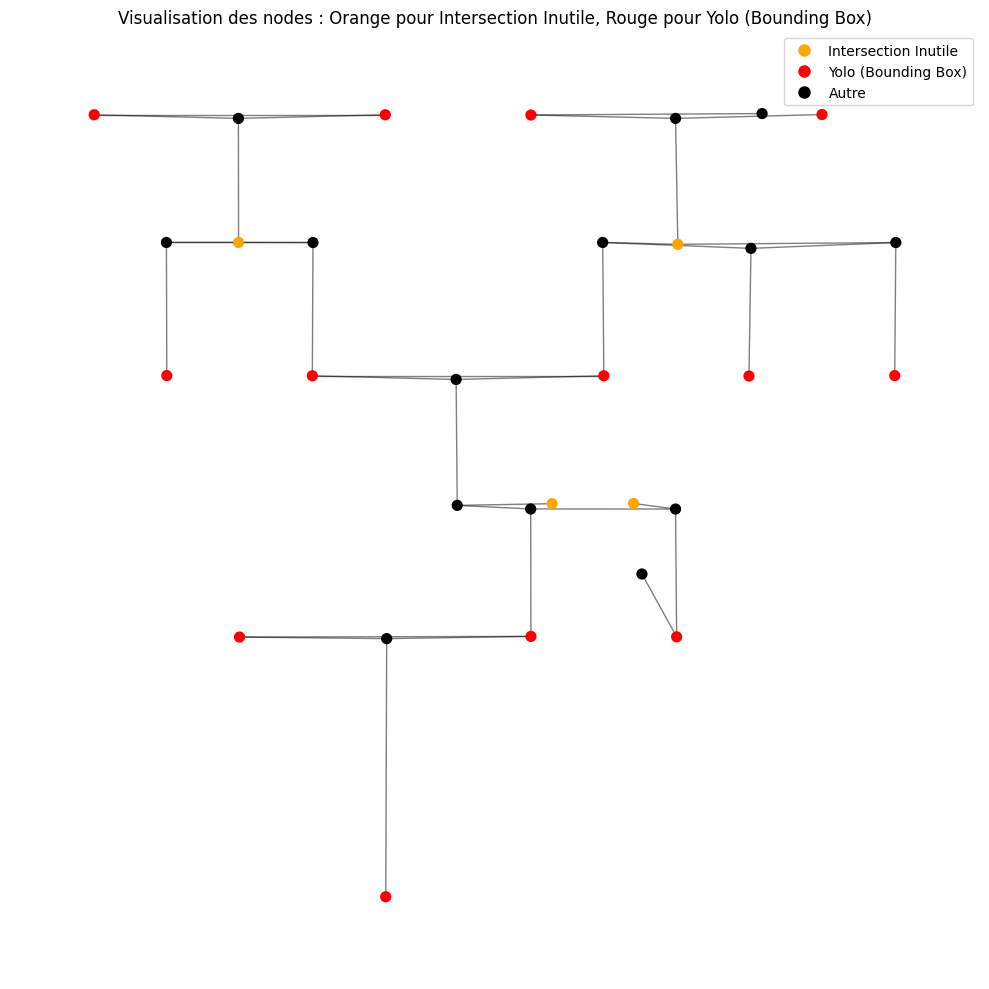

In [ ]:
def visualiser_nodes_useless_et_yolos(G, node_types, bounding_boxes_etendues):
    """
    Affiche les nodes et arêtes du graphe, en mettant en évidence les intersections inutiles en orange
    et les nodes Yolo associés à des figures en rouge.
    
    :param G: Graphe NetworkX.
    :param node_types: Dictionnaire {node: type} où type peut être 'bounding_box', 'intersection', etc.
    :param bounding_boxes_etendues: Liste des bounding boxes étendues [(x_min, y_min, x_max, y_max)].
    """
    # identifier les nodes inutiles (intersection inutile avec voisins intersections)
    nodes_useless = []
    for node in G.nodes():
        # ignore les nodes 'bounding_box' ou 'other'
        if node_types.get(node) == 'bounding_box':
            continue
        
        # Vérifier si tous les voisins du nœud sont des intersections
        neighbors = list(G.neighbors(node))
        if all(node_types.get(neighbor) == 'intersection' for neighbor in neighbors):
            nodes_useless.append(node)

    # identifier les nodes 'Yolo' associés à des bounding boxes (les nodes de figures)
    nodes_yolos = []
    for node in G.nodes():
        if node_types.get(node) == 'bounding_box':
            nodes_yolos.append(node)

    #  graphe avec des nodes colorés
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # dessiner les arêtes du graphe
    nx.draw_networkx_edges(G, pos={node: (-node[0], -node[1]) for node in G.nodes()}, alpha=0.5)
    
    # dessiner les nodes avec couleur par défaut
    node_colors = []
    for node in G.nodes():
        if node in nodes_useless:
            node_colors.append('orange')  # intersection inutile en orange
        elif node in nodes_yolos:
            node_colors.append('red')  # node Yolo en rouge (bounding box)
        else:
            node_colors.append('black')  # Autres nodes en noir

    # dessiner les nodes
    nx.draw_networkx_nodes(G, pos={node: (-node[0], -node[1]) for node in G.nodes()}, 
                           node_color=node_colors, node_size=50)
    
    # add une légende
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Intersection Inutile', markerfacecolor='orange', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Yolo (Bounding Box)', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Autre', markerfacecolor='black', markersize=10)
    ]
    plt.legend(handles=legend_elements, loc='best')
    
    # Afficher l'image
    plt.title("Visualisation des nodes : Orange pour Intersection Inutile, Rouge pour Yolo (Bounding Box)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()


# les nodes inutiles et Yolos associés à des figures
visualiser_nodes_useless_et_yolos(G_final, node_types, bounding_boxes_etendues)


Le noeud d'intersection inutile est le noeud (4033.335856389999, 562.7944432497025)
Fusion avec les voisins : (4034.03203125, 283.2462804079056) et (3660.2679418087005, 563.0303036212921)
Le noeud (4033.335856389999, 562.7944432497025) a été supprimé et les coordonnées des voisins (4034.03203125, 283.2462804079056) et (3660.2679418087005, 563.0303036212921) ont été mises à jour.

Le noeud d'intersection inutile est le noeud (2461.661980962753, 1151.7920691490174), mais il n'a pas 2 voisins.
Voisin : (2937.285498762131, 1155.6547252178193)

Le noeud d'intersection inutile est le noeud (2053.5328125, 1151.4032076358794), mais il n'a pas 2 voisins.
Voisin : (1843.0328717708587, 1163.8758816719055)

Le noeud d'intersection inutile est le noeud (1831.5651281118394, 567.0804418087006)
Fusion avec les voisins : (1843.0238254308701, 283.19921321868895) et (738.9273383617401, 563.1021499156952)
Le noeud (1831.5651281118394, 567.0804418087006) a été supprimé et les coordonnées des voisins (1843

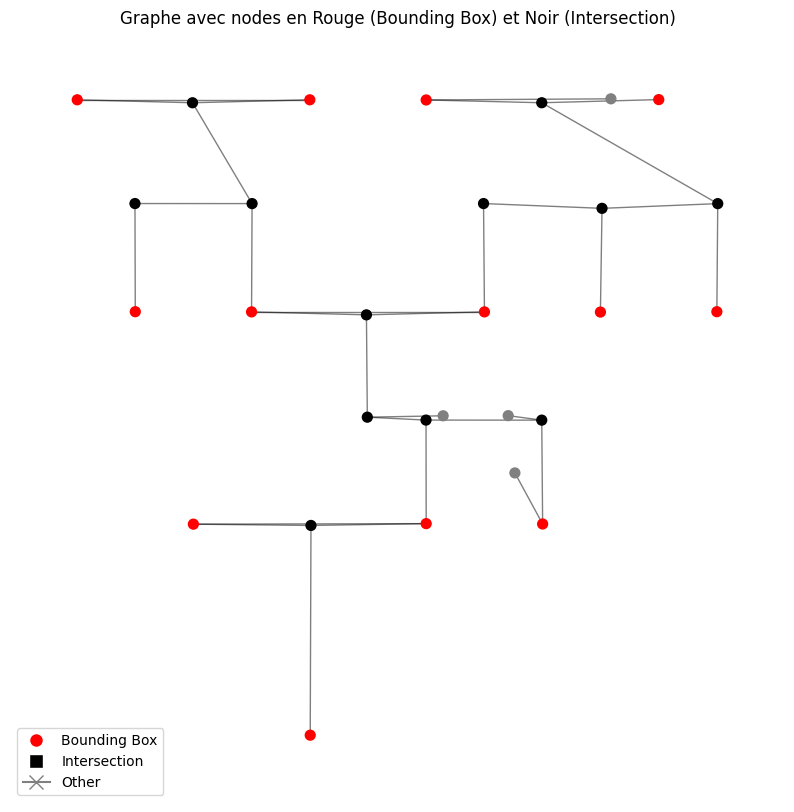

In [27]:
def fusiontmp(G, node_types, bounding_boxes_etendues):
    """
    Affiche les nodes et arêtes du graphe, en mettant en évidence les intersections inutiles en orange
    et les nodes Yolo associés à des figures en rouge.
    
    :param G: Graphe NetworkX.
    :param node_types: Dictionnaire {node: type} où type peut être 'bounding_box', 'intersection', etc.
    :param bounding_boxes_etendues: Liste des bounding boxes étendues [(x_min, y_min, x_max, y_max)].
    """
    # identifier les nodes inutiles (intersection inutile avec voisins intersections)
    nodes_useless = []
    for node in G.nodes():
        # ignorer les nodes 'bounding_box' ou 'other'
        if node_types.get(node) == 'bounding_box':
            continue
        
        # verif si tous les voisins du node sont des intersections
        neighbors = list(G.neighbors(node))
        if all(node_types.get(neighbor) == 'intersection' for neighbor in neighbors):
            nodes_useless.append(node)

            # verif si le node a au moins deux voisins avant d'essayer de les afficher
            if len(neighbors) >= 2:
                print(f"\nLe noeud d'intersection inutile est le noeud {node}")
                print(f"Fils gauche : {neighbors[0]}")
                print(f"Fils droit : {neighbors[1]}")
            else:
                print(f"\nLe noeud d'intersection inutile est le noeud {node}, mais il n'a pas 2 voisins.")
                for neighbor in neighbors:
                    print(f"Voisin : {neighbor}")

def fusionreal(G, node_types):
    """
    Fusionne les intersections inutiles dans le graphe en mettant à jour les coordonnées des nodes voisins.
    Le node inutile est fusionné avec ses voisins (gauche et droite).
    
    :param G: Graphe NetworkX.
    :param node_types: Dictionnaire {node: type} où type peut être 'bounding_box', 'intersection', etc.
    """
    # identifier les nodes inutiles (intersection inutile avec voisins intersections)
    nodes_useless = []
    for node in G.nodes():
        # ignorer les nodes 'bounding_box' ou 'other'
        if node_types.get(node) == 'bounding_box':
            continue
        
        # verif si tous les voisins du node sont des intersections
        neighbors = list(G.neighbors(node))
        if all(node_types.get(neighbor) == 'intersection' for neighbor in neighbors):
            nodes_useless.append(node)

    # fusionner les nodes inutiles
    for node in nodes_useless:
        neighbors = list(G.neighbors(node))

        # verif si le node a au moins deux voisins avant de les fusionner
        if len(neighbors) >= 2:
            # fusio les voisins
            neighbor_left = neighbors[0]
            neighbor_right = neighbors[1]

            print(f"\nLe noeud d'intersection inutile est le noeud {node}")
            print(f"Fusion avec les voisins : {neighbor_left} et {neighbor_right}")
            
            # fusio les coordonnées des voisins pour créer une nouvelle coordonnée (moyenne)
            x_new = (neighbor_left[0] + neighbor_right[0]) / 2
            y_new = (neighbor_left[1] + neighbor_right[1]) / 2
            new_coords = (x_new, y_new)

            # update les voisins avec les nouvelles coordonnées
            G.nodes[neighbor_left]['coords'] = new_coords
            G.nodes[neighbor_right]['coords'] = new_coords

            # add une arête entre les deux voisins
            G.add_edge(neighbor_left, neighbor_right)

            # delete le node inutile
            G.remove_node(node)

            print(f"Le noeud {node} a été supprimé et les coordonnées des voisins {neighbor_left} et {neighbor_right} ont été mises à jour.")

        else:
            print(f"\nLe noeud d'intersection inutile est le noeud {node}, mais il n'a pas 2 voisins.")
            for neighbor in neighbors:
                print(f"Voisin : {neighbor}")

fusionreal(G_final, node_types)
visualiser_graphe(G_final, bounding_boxes_etendues)

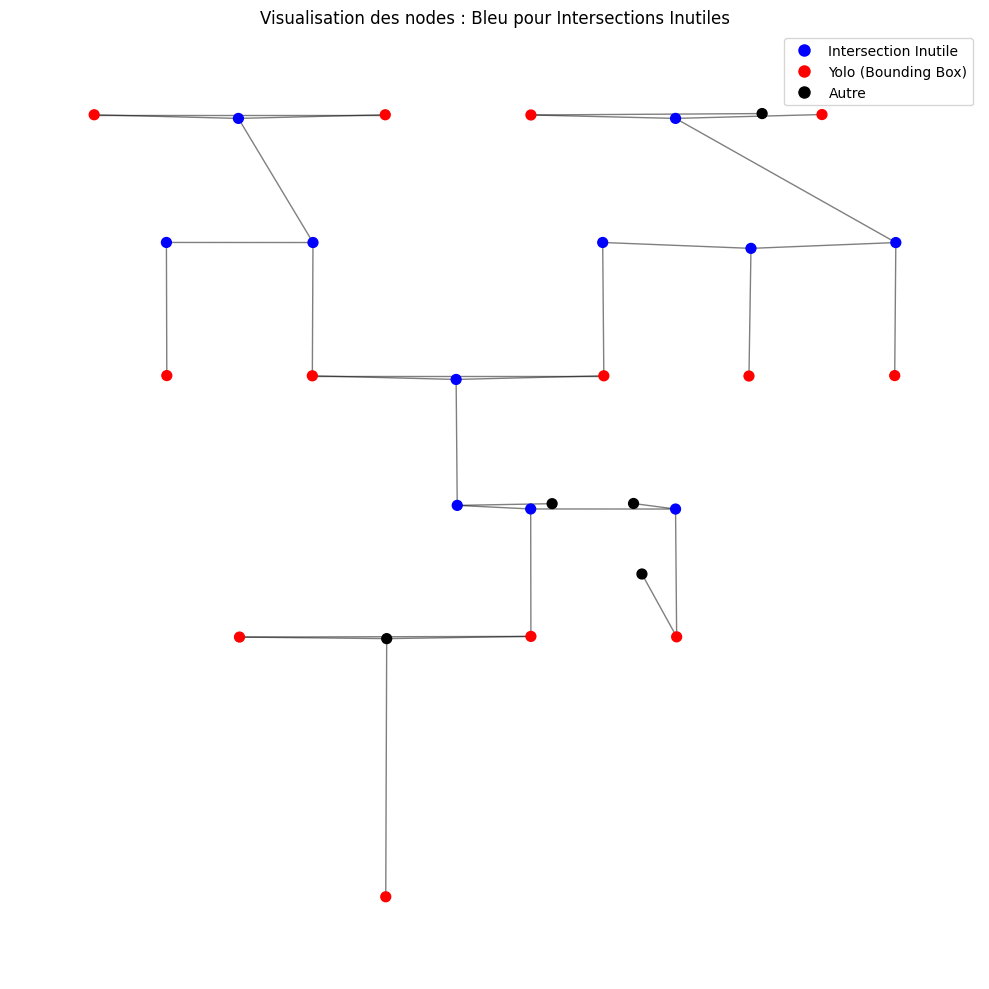

In [ ]:
def colorier_noeuds_inutiles(G, node_types):
    """
    Colore en bleu les nodes inutiles qui sont situés entre une figure (bounding box) et une intersection.
    
    :param G: Graphe NetworkX.
    :param node_types: Dictionnaire {node: type} où type peut être 'bounding_box', 'intersection', etc.
    """
    # identifier les nodes inutiles (intersections entre une figure et une autre intersection)
    nodes_inutiles = []
    
    # parcourir les nodes du graphe
    for node in G.nodes():
        # Si le node est une intersection
        if node_types.get(node) == 'intersection':
            # identifier les voisins de ce node
            neighbors = list(G.neighbors(node))
            
            # verif si ce node a un voisin qui est une figure (bounding box)
            has_bounding_box_neighbor = any(node_types.get(neighbor) == 'bounding_box' for neighbor in neighbors)
            
            # verif si ce node a un autre voisin qui est aussi une intersection
            has_intersection_neighbor = any(node_types.get(neighbor) == 'intersection' for neighbor in neighbors if neighbor != node)
            
            # si le node est connecté à une figure et une autre intersection, il est inutile
            if has_bounding_box_neighbor and has_intersection_neighbor:
                nodes_inutiles.append(node)
            if has_intersection_neighbor and not has_bounding_box_neighbor:
                nodes_inutiles.append(node)

    # graphe avec les nodes inutiles en bleu
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # dessiner les arêtes du graphe
    nx.draw_networkx_edges(G, pos={node: (-node[0], -node[1]) for node in G.nodes()}, alpha=0.5)
    
    # dessiner les nodes
    node_colors = []
    for node in G.nodes():
        if node in nodes_inutiles:
            node_colors.append('blue')  # Nœud inutile en bleu
        elif node_types.get(node) == 'bounding_box':
            node_colors.append('red')  # Nœud Yolo (Bounding Box) en rouge
        else:
            node_colors.append('black')  # Autres nodes en noir

    # Dessiner les nodes avec leurs couleurs
    nx.draw_networkx_nodes(G, pos={node: (-node[0], -node[1]) for node in G.nodes()}, 
                           node_color=node_colors, node_size=50)
    
    # add une légende
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Intersection Inutile', markerfacecolor='blue', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Yolo (Bounding Box)', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Autre', markerfacecolor='black', markersize=10)
    ]
    plt.legend(handles=legend_elements, loc='best')
    
    plt.title("Visualisation des nodes : Bleu pour Intersections Inutiles")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    return nodes_inutiles

# apply la coloration des nodes inutiles dans le graphe
nodes_inutiles = colorier_noeuds_inutiles(G_final, node_types)

In [29]:
nodes_inutiles

[(4034.03203125, 283.2462804079056),
 (3660.2679418087005, 563.0303036212921),
 (4394.911248207092, 562.8744181394577),
 (2942.8281519412994, 871.7370490550995),
 (2937.285498762131, 1155.6547252178193),
 (2569.0635380744934, 1163.7130475521087),
 (1843.0328717708587, 1163.8758816719055),
 (1843.0238254308701, 283.19921321868895),
 (738.9273383617401, 563.1021499156952),
 (2208.198218393326, 562.9195187330246),
 (1464.969017601013, 576.2032168149948)]


Le noeud d'intersection inutile est le noeud (4034.03203125, 283.2462804079056), mais il n'a pas 2 voisins inutiles.
Voisin : (4757.0, 275.0)
Voisin : (3298.0, 275.0)
Voisin : (3660.2679418087005, 563.0303036212921)

Le noeud d'intersection inutile est le noeud (3660.2679418087005, 563.0303036212921)
Fusion avec les voisins inutiles : (4394.911248207092, 562.8744181394577) et (4034.03203125, 283.2462804079056)
Relier le voisin non inutile (3663.5, 863.5) au nouveau point fusionné (4394.911248207092, 562.8744181394577)
Le noeud (3660.2679418087005, 563.0303036212921) a été supprimé et les coordonnées des voisins (4394.911248207092, 562.8744181394577) et (4034.03203125, 283.2462804079056) ont été mises à jour.

Le noeud d'intersection inutile est le noeud (4394.911248207092, 562.8744181394577), mais il n'a pas 2 voisins inutiles.
Voisin : (4393.0, 863.0)
Voisin : (4034.03203125, 283.2462804079056)
Voisin : (3663.5, 863.5)

Le noeud d'intersection inutile est le noeud (2942.8281519412994

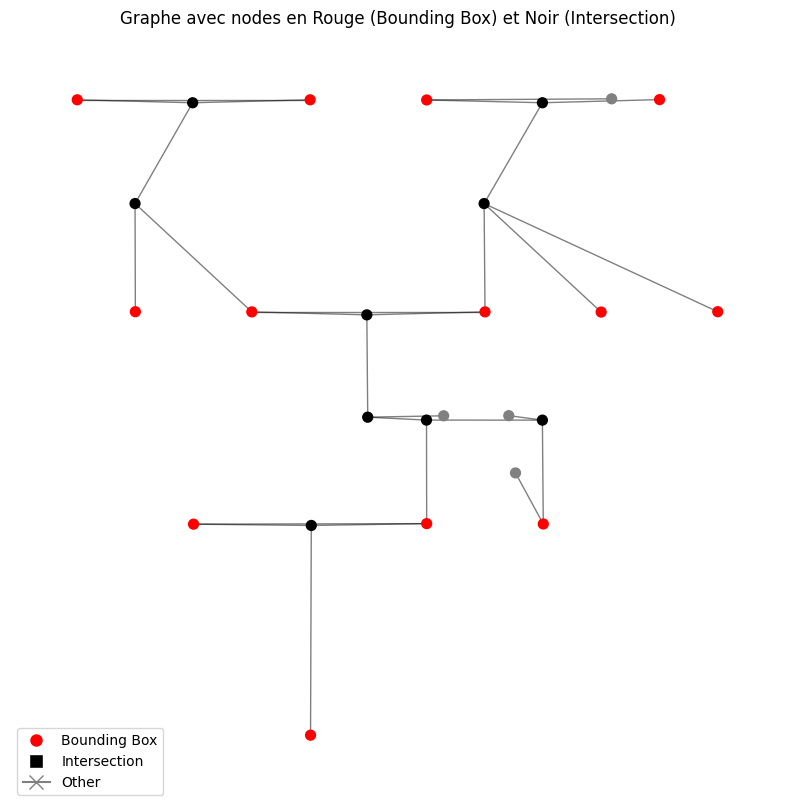

In [30]:
def fusionrealsuite(G, node_types):
    """
    Fusionne les intersections inutiles dans le graphe en mettant à jour les coordonnées des nodes voisins.
    Le node inutile est fusionné avec ses voisins (gauche et droite), tout en maintenant les connexions avec les voisins non inutiles.
    
    :param G: Graphe NetworkX.
    :param node_types: Dictionnaire {node: type} où type peut être 'bounding_box', 'intersection', etc.
    """
    nodes_inutiles = []
    
    # identifier les nodes inutiles
    for node in G.nodes():
        if node_types.get(node) == 'intersection':
            neighbors = list(G.neighbors(node))
            
            # verif si ce node est connecté à une figure et à une autre intersection
            has_bounding_box_neighbor = any(node_types.get(neighbor) == 'bounding_box' for neighbor in neighbors)
            has_intersection_neighbor = any(node_types.get(neighbor) == 'intersection' for neighbor in neighbors if neighbor != node)
            
            if has_bounding_box_neighbor and has_intersection_neighbor:
                nodes_inutiles.append(node)

    # fusio les nodes inutiles
    for node in nodes_inutiles:
        neighbors = list(G.neighbors(node))

        # identifier les voisins inutiles
        neighbors_inutiles = [neighbor for neighbor in neighbors if neighbor in nodes_inutiles]
        
        if len(neighbors_inutiles) >= 2:  # si on a 2 voisins inutiles à fusionner
            neighbor_left = neighbors_inutiles[0]
            neighbor_right = neighbors_inutiles[1]

            print(f"\nLe noeud d'intersection inutile est le noeud {node}")
            print(f"Fusion avec les voisins inutiles : {neighbor_left} et {neighbor_right}")
            
            # fusio les coordonnées des voisins
            x_new = (neighbor_left[0] + neighbor_right[0]) / 2
            y_new = (neighbor_left[1] + neighbor_right[1]) / 2
            new_coords = (x_new, y_new)

            # update les coordonnées des voisins inutiles fusionnés
            G.nodes[neighbor_left]['coords'] = new_coords
            G.nodes[neighbor_right]['coords'] = new_coords

            # add une arête entre les voisins fusionnés
            G.add_edge(neighbor_left, neighbor_right)

            # raccorder les voisins non inutiles au nouveau point fusionné
            for neighbor in neighbors:
                if neighbor not in nodes_inutiles:
                    # update l'arête entre le voisin non inutile et l'un des voisins fusionnés
                    G.add_edge(neighbor, neighbor_left)
                    print(f"Relier le voisin non inutile {neighbor} au nouveau point fusionné {neighbor_left}")

            # delete le node inutile
            G.remove_node(node)

            print(f"Le noeud {node} a été supprimé et les coordonnées des voisins {neighbor_left} et {neighbor_right} ont été mises à jour.")
        else:
            print(f"\nLe noeud d'intersection inutile est le noeud {node}, mais il n'a pas 2 voisins inutiles.")
            for neighbor in neighbors:
                print(f"Voisin : {neighbor}")

    return G

# la fusion des nodes inutiles
G_final = fusionrealsuite(G_final, node_types)

visualiser_graphe(G_final, bounding_boxes_etendues)

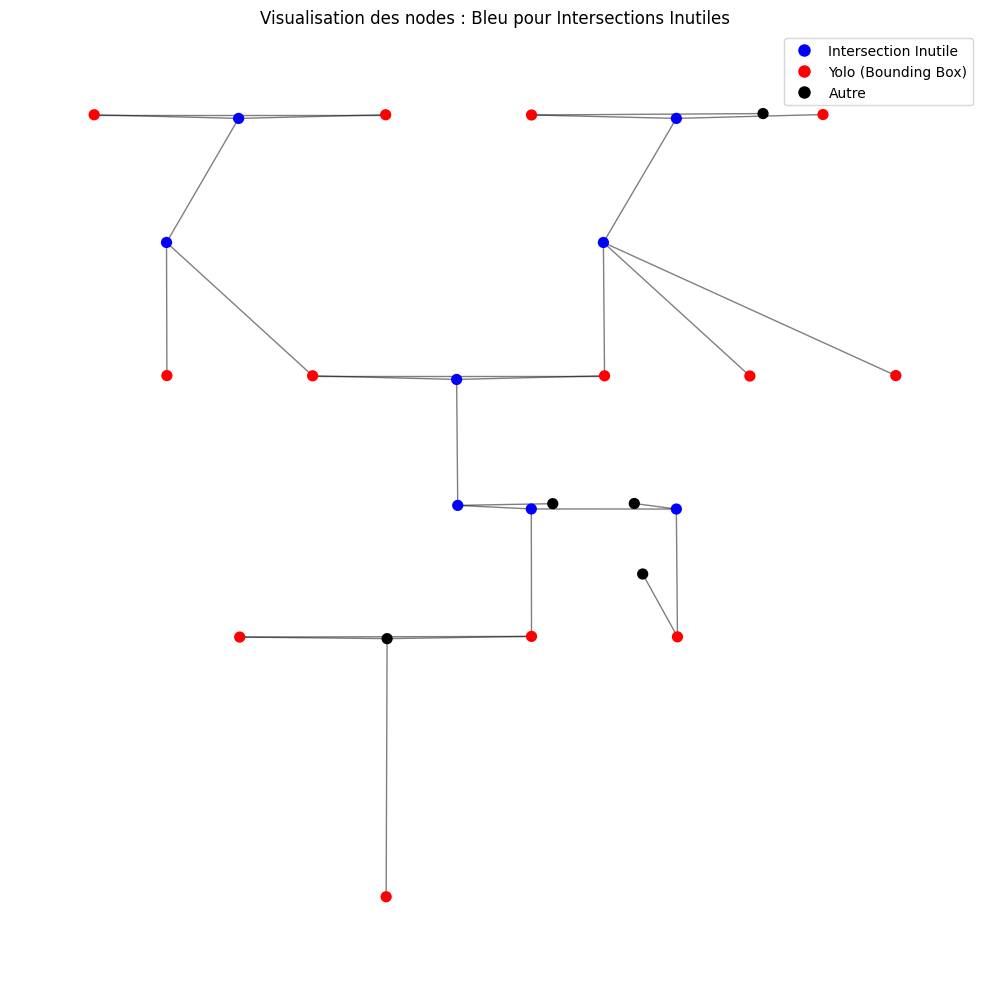

In [31]:
nodes_inutiles = colorier_noeuds_inutiles(G_final, node_types)

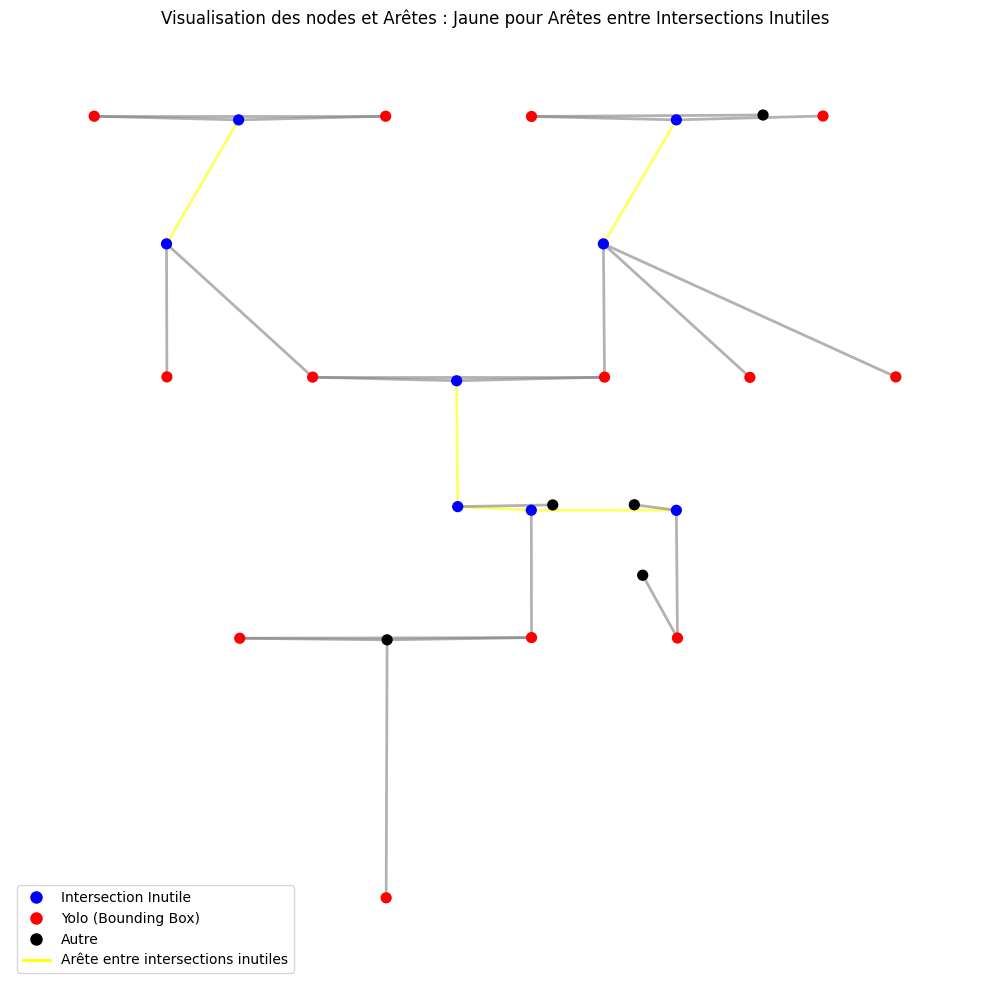

[(4034.03203125, 283.2462804079056), (4394.911248207092, 562.8744181394577), (2942.8281519412994, 871.7370490550995), (2937.285498762131, 1155.6547252178193), (2569.0635380744934, 1163.7130475521087), (1843.0328717708587, 1163.8758816719055), (1843.0238254308701, 283.19921321868895), (2208.198218393326, 562.9195187330246)]


In [ ]:
def colorier_arêtes_inutiles(G, node_types):
    """
    Colore en jaune les arêtes entre deux points d'intersection inutiles.
    
    :param G: Graphe NetworkX.
    :param node_types: Dictionnaire {node: type} où type peut être 'bounding_box', 'intersection', etc.
    """
    # identifier les nodes inutiles (intersections entre une figure et une autre intersection)
    nodes_inutiles = []
    # parcourir les nodes du graphe
    for node in G.nodes():
        # si le node est une intersection
        if node_types.get(node) == 'intersection':
            # identifier les voisins de ce node
            neighbors = list(G.neighbors(node))

            # verif si ce node a un voisin qui est une figure (bounding box)
            has_bounding_box_neighbor = any(node_types.get(neighbor) == 'bounding_box' for neighbor in neighbors)

            # verif si ce node a un autre voisin qui est aussi une intersection
            has_intersection_neighbor = any(node_types.get(neighbor) == 'intersection' for neighbor in neighbors if neighbor != node)

            # si le node est connecté à une figure et une autre intersection, il est inutile
            if has_bounding_box_neighbor and has_intersection_neighbor:
                nodes_inutiles.append(node)
            if has_intersection_neighbor and not has_bounding_box_neighbor:
                nodes_inutiles.append(node)
    # graphe avec les nodes inutiles en bleu et les arêtes inutiles en jaune
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # dessiner les arêtes du graphe
    edge_colors = []
    for node1, node2 in G.edges():
        # colorier en jaune les arêtes entre deux points d'intersection inutiles
        if node1 in nodes_inutiles and node2 in nodes_inutiles:
            edge_colors.append('yellow')
        elif ((node1 in nodes_inutiles and node_types.get(node2) == 'intersection') or (node2 in nodes_inutiles and node_types.get(node1) == 'intersection')):
            edge_colors.append('yellow')
        else:
            edge_colors.append('gray')  # couleur par défaut pour les autres arêtes

    # dessiner les arêtes
    nx.draw_networkx_edges(G, pos={node: (-node[0], -node[1]) for node in G.nodes()}, edge_color=edge_colors, width=2, alpha=0.6)
    
    # dessiner les nodes
    node_colors = []
    for node in G.nodes():
        if node in nodes_inutiles:
            node_colors.append('blue')  # node inutile en bleu
        elif node_types.get(node) == 'bounding_box':
            node_colors.append('red')  # node Yolo (Bounding Box) en rouge
        else:
            node_colors.append('black')  # autres nodes en noir
    

    # dessiner les nodes avec leurs couleurs
    nx.draw_networkx_nodes(G, pos={node: (-node[0], -node[1]) for node in G.nodes()}, 
                           node_color=node_colors, node_size=50)
    
    # add une légende

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Intersection Inutile', markerfacecolor='blue', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Yolo (Bounding Box)', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Autre', markerfacecolor='black', markersize=10),
        Line2D([0], [0], color='yellow', lw=2, label='Arête entre intersections inutiles')
    ]
    plt.legend(handles=legend_elements, loc='best')
    
    plt.title("Visualisation des nodes et Arêtes : Jaune pour Arêtes entre Intersections Inutiles")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return nodes_inutiles

# la coloration des arêtes inutiles dans le graphe
nodes_inutiles = colorier_arêtes_inutiles(G_final, node_types)
print(nodes_inutiles)

Fusion de (4034.03203125, 283.2462804079056) et (4394.911248207092, 562.8744181394577), garder (4394.911248207092, 562.8744181394577) et supprimer (4034.03203125, 283.2462804079056)
Fusion de (2569.0635380744934, 1163.7130475521087) et (1843.0328717708587, 1163.8758816719055), garder (1843.0328717708587, 1163.8758816719055) et supprimer (2569.0635380744934, 1163.7130475521087)
Fusion de (1843.0238254308701, 283.19921321868895) et (2208.198218393326, 562.9195187330246), garder (2208.198218393326, 562.9195187330246) et supprimer (1843.0238254308701, 283.19921321868895)
Ajout de l'arête ((4394.911248207092, 562.8744181394577), (4757.0, 275.0))
Ajout de l'arête ((4394.911248207092, 562.8744181394577), (3298.0, 275.0))
Ajout de l'arête ((1843.0328717708587, 1163.8758816719055), (2937.285498762131, 1155.6547252178193))
Ajout de l'arête ((1843.0328717708587, 1163.8758816719055), (2568.0, 1451.0))
Ajout de l'arête ((2208.198218393326, 562.9195187330246), (2568.0, 275.5))
Ajout de l'arête ((220

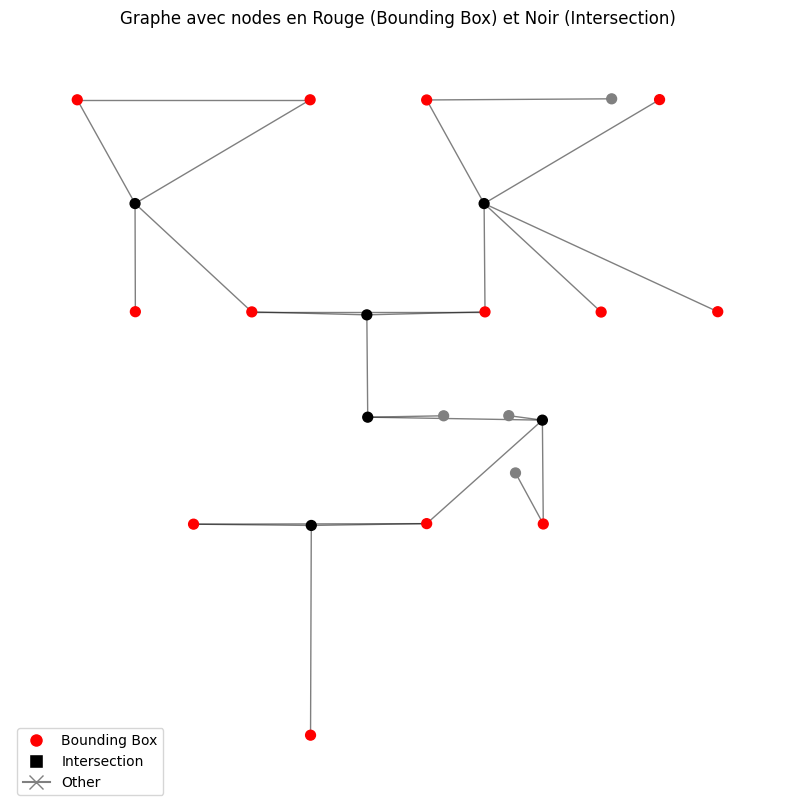

In [33]:
def virer_arêtes_inutiles(G, node_types):
    """
    Fusionne les intersections inutiles et les arêtes qui les relient, en gardant le point avec le plus de voisins.
    
    :param G: Graphe NetworkX.
    :param node_types: Dictionnaire {node: type} où type peut être 'bounding_box', 'intersection', etc.
    """
    # identifier les nodes inutiles (intersections entre une figure et une autre intersection)
    nodes_inutiles = []

    for node in G.nodes():
        if node_types.get(node) == 'intersection':
            neighbors = list(G.neighbors(node))

            has_bounding_box_neighbor = any(node_types.get(neighbor) == 'bounding_box' for neighbor in neighbors)
            has_intersection_neighbor = any(node_types.get(neighbor) == 'intersection' for neighbor in neighbors if neighbor != node)

            if has_bounding_box_neighbor and has_intersection_neighbor:
                nodes_inutiles.append(node)
            for neighbor in neighbors:
                if node_types.get(neighbor) == 'intersection':
                    nodes_inutiles.append

    # setup des listes pour collecter les nodes à supprimer et les nouvelles arêtes à ajouter
    node_to_removes = []
    edges_to_add = []

    # parcourir les arêtes du graphe
    for node1, node2 in G.edges():
        if node1 in nodes_inutiles and node2 in nodes_inutiles:
            node_to_keep = node1 if len(list(G.neighbors(node1))) > len(list(G.neighbors(node2))) else node2
            node_to_remove = node2 if node_to_keep == node1 else node1

            # add des arêtes entre le nœud à garder et les voisins du nœud à supprimer
            print(f"Fusion de {node1} et {node2}, garder {node_to_keep} et supprimer {node_to_remove}")
            
            # ne pas créer d'arête entre un nœud et lui-même
            for neighbor in G.neighbors(node_to_remove):
                if neighbor != node_to_keep:  # évite l'auto-référence
                    edges_to_add.append((node_to_keep, neighbor))

            node_to_removes.append(node_to_remove)  # add à la liste des nodes à supprimer

    # apply les nouvelles arêtes
    for edge in edges_to_add:
        if not G.has_edge(*edge):  # verif que l'arête n'existe pas déjà
            G.add_edge(*edge)
            print(f"Ajout de l'arête {edge}")
    
    # delete les nodes inutiles
    for node in node_to_removes:
        G.remove_node(node)
        print(f"Suppression du nœud {node}")

    return G

G_final = virer_arêtes_inutiles(G_final, node_types)
visualiser_graphe(G_final, bounding_boxes_etendues)

In [34]:
# verif le nombre de composantes connexes dans le graphe
num_composantes, composants = afficher_composantes_connexes(G_final)

# si le graphe n'est pas connexe, vous aurez plusieurs composantes.
if num_composantes > 1:
    print("Le graphe est non connexe.")
else:
    print("Le graphe est connexe.")

Le graphe contient 1 composantes connexes.
Tailles des composantes connexes :
Composante 1 : 23 nodes
Le graphe est connexe.


Composantes supprimées : set()
Arêtes supprimées : [((2937.285498762131, 1155.6547252178193), (2461.661980962753, 1151.7920691490174)), ((1843.0328717708587, 1163.8758816719055), (2053.5328125, 1151.4032076358794)), ((1837.5, 1452.0), (2011.487259721756, 1310.334290599823)), ((2568.0, 275.5), (1409.114292383194, 272.3083376169205))]
nodes 'other' supprimés : {(2011.487259721756, 1310.334290599823), (2053.5328125, 1151.4032076358794), (1409.114292383194, 272.3083376169205), (2461.661980962753, 1151.7920691490174)}


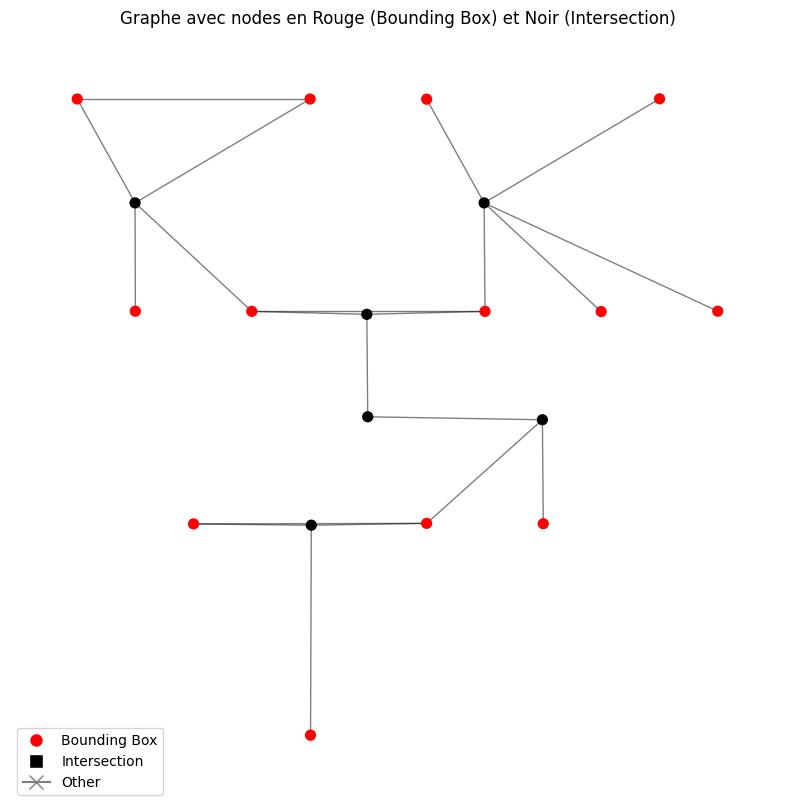

In [ ]:
def virer_composantes_non_connexes_et_arêtes_other(G, node_types):
    """
    Supprime les sous-composantes non connexes plus petites que la plus grande composante du graphe,
    supprime les arêtes allant vers un nœud de type 'other', et supprime les nodes de type 'other'.
    
    :param G: Graphe NetworkX.
    :param node_types: Dictionnaire {node: type} où type peut être 'bounding_box', 'intersection', 'other', etc.
    """
    
    # trouver toutes les composantes connexes du graphe
    composants_connexes = list(nx.connected_components(G))

    # identifier la plus grande composante
    largest_component = max(composants_connexes, key=len)
    largest_component_size = len(largest_component)

    # delete les sous-composantes plus petites que la plus grande composante
    nodes_to_remove = set()
    for component in composants_connexes:
        if len(component) < largest_component_size:
            nodes_to_remove.update(component)
    
    # delete les nodes des sous-composantes non connexes
    G.remove_nodes_from(nodes_to_remove)
    print(f"Composantes supprimées : {nodes_to_remove}")
    
    # delete les arêtes vers les nodes de type 'other' et collecter les nodes 'other'
    edges_to_remove = []
    nodes_other_to_remove = set()
    
    for node1, node2 in G.edges():
        if node_types.get(node1) == 'other' or node_types.get(node2) == 'other':
            edges_to_remove.append((node1, node2))
            # add les nodes 'other' à la liste pour suppression
            if node_types.get(node1) == 'other':
                nodes_other_to_remove.add(node1)
            if node_types.get(node2) == 'other':
                nodes_other_to_remove.add(node2)

    # delete les arêtes vers les nodes 'other'
    G.remove_edges_from(edges_to_remove)
    print(f"Arêtes supprimées : {edges_to_remove}")

    # delete les nodes 'other'
    G.remove_nodes_from(nodes_other_to_remove)
    print(f"nodes 'other' supprimés : {nodes_other_to_remove}")

    return G

# la suppression des sous-composantes non connexes, des arêtes vers 'other', et des nodes 'other'
G_final = virer_composantes_non_connexes_et_arêtes_other(G_final, node_types)
# le graphe après les modifications
visualiser_graphe(G_final, bounding_boxes_etendues)


Le noeud d'intersection inutile est le noeud (2937.285498762131, 1155.6547252178193)
Fusion avec les voisins : (2942.8281519412994, 871.7370490550995) et (1843.0328717708587, 1163.8758816719055)
Le noeud (2937.285498762131, 1155.6547252178193) a été supprimé et les coordonnées des voisins (2942.8281519412994, 871.7370490550995) et (1843.0328717708587, 1163.8758816719055) ont été mises à jour.


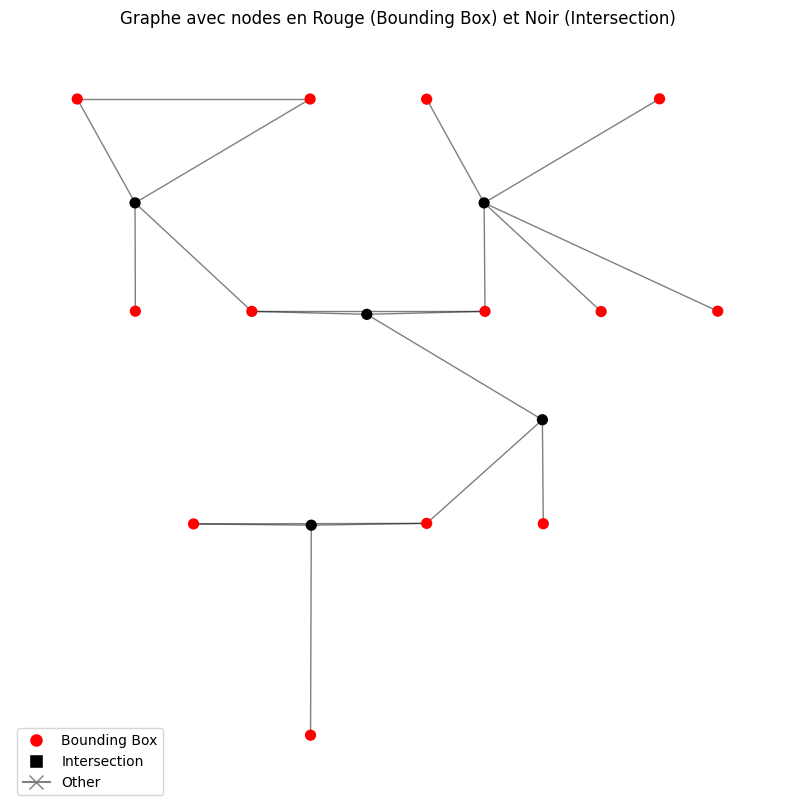

In [36]:
fusionreal(G_final, node_types)
visualiser_graphe(G_final, bounding_boxes_etendues)

Arête supprimée: ((2942.8281519412994, 871.7370490550995), (1843.0328717708587, 1163.8758816719055))
node supprimé: (1843.0328717708587, 1163.8758816719055)
Arête ajoutée: ((2942.8281519412994, 871.7370490550995), (1837.5, 1452.0))
Arête ajoutée: ((2942.8281519412994, 871.7370490550995), (2568.0, 1451.0))


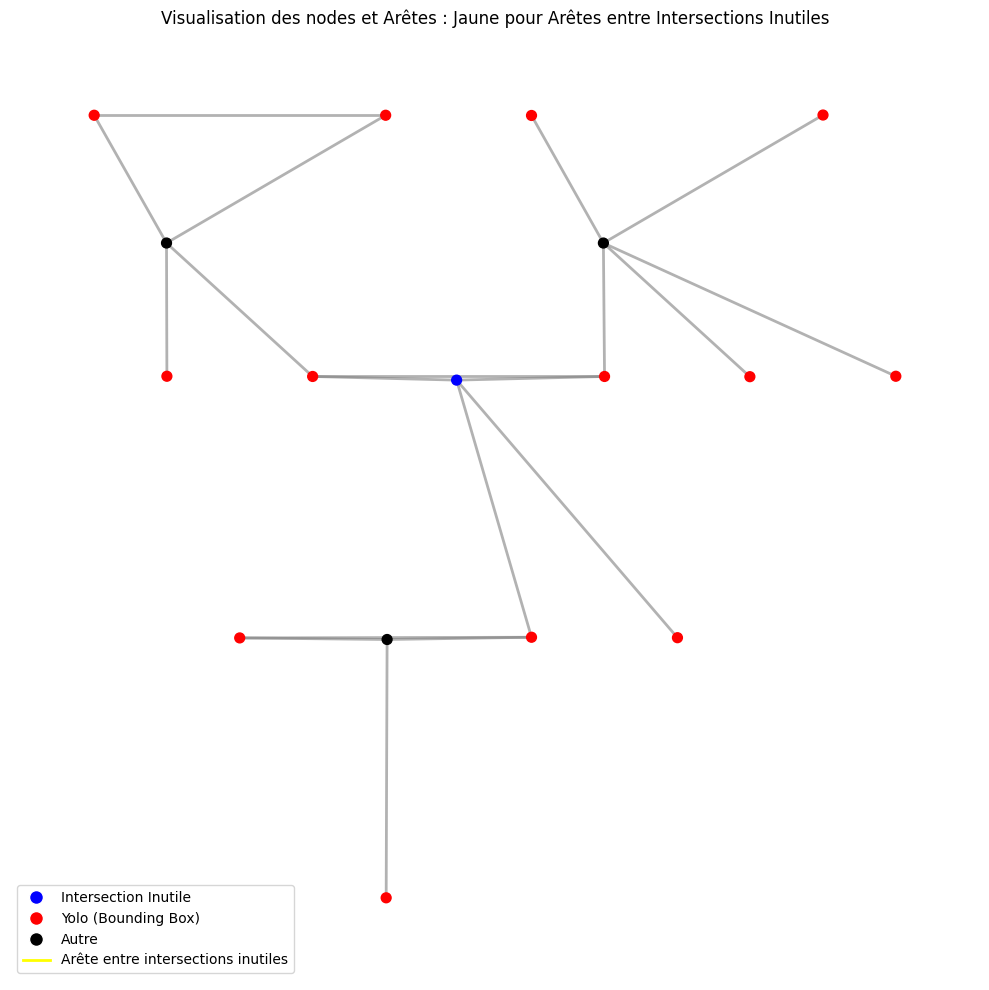

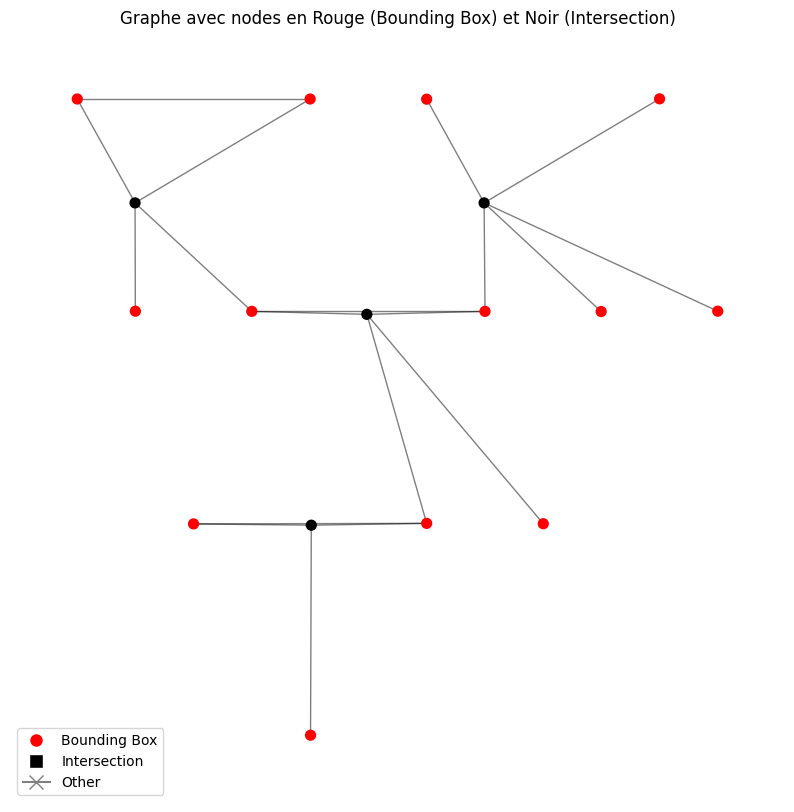

In [37]:
def virer2inter_redondantes(G, node_types):
    """
    Supprime les intersections redondantes et relie les voisins des intersections fusionnées.
    
    :param G: Graphe NetworkX.
    :param node_types: Dictionnaire {node: type} où type peut être 'bounding_box', 'intersection', 'other', etc.
    :return: Graphe NetworkX modifié.
    """
    # identifier les nodes inutiles (intersections directement reliées à une autre intersection)
    nodes_inutiles = []

    # liste pour les arêtes et nodes à supprimer ou modifier
    edges_to_remove = []
    edges_to_add = []
    nodes_to_remove = []

    # parcourir les nodes du graphe pour identifier les intersections inutiles
    for node in G.nodes():
        if node_types.get(node) == 'intersection':
            neighbors = list(G.neighbors(node))
            
            # si ce node est relié à un autre node d'intersection, il est inutil
            intersections = [n for n in neighbors if node_types.get(n) == 'intersection']
            if len(intersections) >= 1:  # Si le node est relié à une autre intersection
                nodes_inutiles.append(node)

    # parcourir les arêtes du graphe
    for node1, node2 in G.edges():
        # Colorier en jaune les arêtes entre deux points d'intersection inutiles
        if node1 in nodes_inutiles and node2 in nodes_inutiles:
            # link les voisins de node2 (qui sont des figures) à node1
            voisins_de_node2_qui_sont_des_figures = [voisin for voisin in G.neighbors(node2) if node_types.get(voisin) == 'bounding_box']
            edges_to_remove.append((node1, node2))  # Marquer l'arête à supprimer
            nodes_to_remove.append(node2)  # Marquer le node à supprimer
            # add des arêtes entre node1 et ses voisins de type 'bounding_box'
            for voisin in voisins_de_node2_qui_sont_des_figures:
                edges_to_add.append((node1, voisin))

        # colorier en jaune les arêtes entre un node d'intersection et un autre node d'intersection inutile
        elif ((node1 in nodes_inutiles and node_types.get(node2) == 'intersection') or 
              (node2 in nodes_inutiles and node_types.get(node1) == 'intersection')):
            voisins_de_node2_qui_sont_des_figures = [voisin for voisin in G.neighbors(node2) if node_types.get(voisin) == 'bounding_box']
            edges_to_remove.append((node1, node2))  # marquer l'arête à supprimer
            nodes_to_remove.append(node2)  # marquer le node à supprimer
            # add des arêtes entre node1 et ses voisins de type 'bounding_box'
            for voisin in voisins_de_node2_qui_sont_des_figures:
                edges_to_add.append((node1, voisin))

    # apply les modifications (supprimer et ajouter des arêtes/nodes)
    for edge in edges_to_remove:
        G.remove_edge(*edge)
        print(f"Arête supprimée: {edge}")
    
    for node in nodes_to_remove:
        G.remove_node(node)
        print(f"node supprimé: {node}")
    
    for edge in edges_to_add:
        if not G.has_edge(*edge):  # add une arête uniquement si elle n'existe pas déjà
            G.add_edge(*edge)
            print(f"Arête ajoutée: {edge}")

    # Visualisation
    # dessiner le graphe avec les nodes et les arêtes
    fig, ax = plt.subplots(figsize=(10, 10))
    edge_colors = []
    for node1, node2 in G.edges():
        if node1 in nodes_inutiles and node2 in nodes_inutiles:
            edge_colors.append('yellow')  # edges entre intersections inutiles
        else:
            edge_colors.append('gray')  # color par défaut pour les autres arêtes

    # draw les arêtes
    nx.draw_networkx_edges(G, pos={node: (-node[0], -node[1]) for node in G.nodes()}, edge_color=edge_colors, width=2, alpha=0.6)

    # draw les nodes
    node_colors = []
    for node in G.nodes():
        if node in nodes_inutiles:
            node_colors.append('blue')  # intersection inutile en bleu
        elif node_types.get(node) == 'bounding_box':
            node_colors.append('red')  # node Yolo (Bounding Box) en rouge
        else:
            node_colors.append('black')  # Autres nodes en noir

    # draw les nodes avec leurs couleurs
    nx.draw_networkx_nodes(G, pos={node: (-node[0], -node[1]) for node in G.nodes()}, node_color=node_colors, node_size=50)

    # add une légende
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Intersection Inutile', markerfacecolor='blue', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Yolo (Bounding Box)', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Autre', markerfacecolor='black', markersize=10),
        Line2D([0], [0], color='yellow', lw=2, label='Arête entre intersections inutiles')
    ]
    plt.legend(handles=legend_elements, loc='best')

    plt.title("Visualisation des nodes et Arêtes : Jaune pour Arêtes entre Intersections Inutiles")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return nodes_inutiles

# apply la fusion des intersections redondantes et relier les voisins
virer2inter_redondantes(G_final, node_types)
visualiser_graphe(G_final, bounding_boxes_etendues)

## bon ca marche sur ce cas mais j'ai peur que cela soit random pour le conjoint, faudrait plutôt parcourir chaque noeud au lieu de chaque arête, pour chaque noeud on regarde ses arêtes

Figure id était : 13
coord était : (4757.0, 275.0)
Figure id était : 7
coord était : (3298.0, 275.0)
Figure id était : 1
coord était : (3663.5, 863.5)
Figure id était : 3
coord était : (4393.0, 863.0)
Figure id était : 10
coord était : (2202.5, 863.5)
Figure id était : 6
coord était : (2568.0, 1451.0)
Figure id était : 4
coord était : (1837.5, 1452.0)
Figure id était : 12
coord était : (4028.5, 1452.5)
Figure id était : 2
coord était : (3295.5, 2038.0)
Figure id était : 11
coord était : (2568.0, 275.5)
Figure id était : 5
coord était : (1109.0, 274.5)
Figure id était : 8
coord était : (744.5, 863.0)
Figure id était : 9
coord était : (1475.0, 864.0)


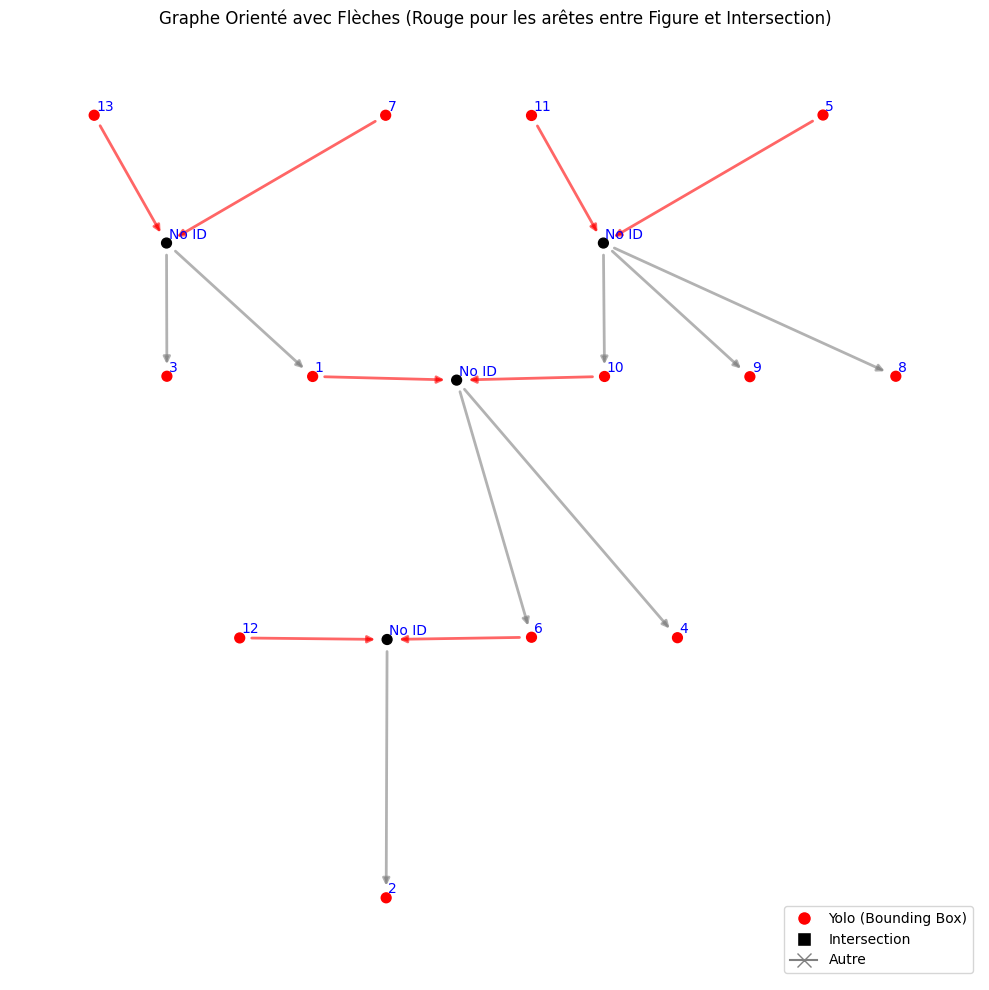

In [38]:
# pour trouver l'ID associé à un node
def trouver_id_associee_au_noeud(node, figure_data, seuil = 5):
    """
    Trouve l'ID de la figure associée à un node en fonction de la position (x, y).
    
    :param node: Coordonnée du node.
    :param figure_data: Dictionnaire {figure_id: figure_info} contenant les coordonnées des figures.
    :return: L'ID de la figure associée.
    """
    node_x, node_y = int(node[0]), int(node[1])
    for figure_id, figure_info in figure_data.items():
        # si le node correspond à la position de la figure, on renvoie l'ID
        figure_x, figure_y = int(figure_info['coordinates'][0]), int(figure_info['coordinates'][1])
        
        # comparer les coordonnées
        # verif si les coordonnées du node sont suffisamment proches de celles de la figure
        if abs(node_x - figure_x) <= seuil and abs(node_y - figure_y) <= seuil:
            return figure_id
    return 'Unknown'  # Retourner 'Unknown' si aucune correspondance n'est trouvée

def orienter_graphe_et_afficher_flèches(G, node_types):
    """
    Oriente les arêtes du graphe en fonction de la relation figure-intersection et affiche le graphe avec des flèches.
    
    :param G: Graphe NetworkX.
    :param node_types: Dictionnaire {node: type} où type peut être 'bounding_box', 'intersection', 'other', etc.
    :return: Graphe NetworkX orienté avec des flèches.
    """
    # creer un graphe dirigé pour l'orientation des arêtes
    G_oriente = nx.DiGraph()

    # copy les nodes du graphe initial dans le graphe orienté et transférer les attributs
    for node in G.nodes():
        G_oriente.add_node(node, type=node_types.get(node, 'other'))  # Ajouter le type du node

    # ajouter un id à chaque node dans le graphe orienté pour se reperer
        # copy les nodes du graphe initial dans le graphe orienté et ajouter les attributs
    for node in G.nodes():
        # verif si le node est dans la bounding box ou autre
        node_type = node_types.get(node, 'other')  # 'other' si non spécifié
        G_oriente.add_node(node, type=node_type)

        # add l'ID de la figure associée à ce node si c'est une bounding box
        if node_type == 'bounding_box':
            # Trouver l'ID de la figure correspondant à cette bounding box
            figure_id = trouver_id_associee_au_noeud(node, final_text_associations) # Fonction à créer pour associer
            print("Figure id était :", figure_id)
            print("coord était :", node)
            G_oriente.nodes[node]['id'] = figure_id

    # recup les positions des nodes avant inversion pour l'affichage
    pos = {node: (node[0], node[1]) for node in G.nodes()}  # Garder les positions originales

    # pour toutes les arêtes :
    for node1, node2 in G.edges():
        # si node1 est une figure et node2 est une intersection
        if node_types.get(node1) == 'bounding_box' and node_types.get(node2) == 'intersection':
            # link la figure à l'intersection si la figure est en bas de l'intersection
            if pos[node1][1] < pos[node2][1]:
                G_oriente.add_edge(node1, node2)
            else:
                G_oriente.add_edge(node2, node1)
        # si node1 est une intersection et node2 est une figure
        elif node_types.get(node1) == 'intersection' and node_types.get(node2) == 'bounding_box':
            # link l'intersection à la figure si l'intersection est en haut de la figure
            if pos[node1][1] < pos[node2][1]:
                G_oriente.add_edge(node1, node2)
            else:
                G_oriente.add_edge(node2, node1)
        # si les deux sont des intersections :
        elif node_types.get(node1) == 'intersection' and node_types.get(node2) == 'intersection':
            # si les deux sont des intersections, relier node1 à node2
            G_oriente.add_edge(node1, node2)

    # rotation des positions des nodes pour l'affichage (180 degrés)
    pos = {node: (-coord[0], -coord[1]) for node, coord in pos.items()}
    # visu du graphe orienté avec des flèches
    fig, ax = plt.subplots(figsize=(10, 10))
    node_colors = []

    # Colorier les nodes
    for node in G_oriente.nodes():
        if node_types.get(node) == 'bounding_box':
            node_colors.append('red')  # Nœud Yolo (Bounding Box) en rouge
        elif node_types.get(node) == 'intersection':
            node_colors.append('black')  # Intersection en noir
        else:
            node_colors.append('grey')  # Autres nodes en gris

    # draw les nodes
    nx.draw_networkx_nodes(G_oriente, pos, node_color=node_colors, node_size=50)

    # draw les arêtes orientées avec des flèches
    edge_colors = ['red' if node_types.get(node1) == 'bounding_box' and node_types.get(node2) == 'intersection' else 'gray' for node1, node2 in G_oriente.edges()]
    nx.draw_networkx_edges(G_oriente, pos, edge_color=edge_colors, width=2, alpha=0.6, arrows=True)

    # add l'ID à chaque node
    for node in G_oriente.nodes():
        x, y = pos[node]
        id_text = G_oriente.nodes[node].get('id', 'No ID')
        ax.text(x + 10, y + 10, id_text, fontsize=10, color='blue')  # Placer l'ID légèrement à droite et en bas du node

    # add une légende
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Yolo (Bounding Box)', markerfacecolor='red', markersize=10),
        Line2D([0], [0], marker='s', color='w', label='Intersection', markerfacecolor='black', markersize=10),
        Line2D([0], [0], marker='x', color='grey', label='Autre', markersize=10)
    ]
    plt.legend(handles=legend_elements, loc='best')

    # add un titre et désactiver les axes
    plt.title("Graphe Orienté avec Flèches (Rouge pour les arêtes entre Figure et Intersection)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return G_oriente

G_oriente = orienter_graphe_et_afficher_flèches(G_final, node_types)

In [39]:
for figure, data in figure_data.items():
    print(f"\n{figure}:")
    print(data)

print()


1:
{'Name': 'Person_Unknown', 'Class': 'femme decede', 'Age': '50', 'Yob': '1974', 'Diseases': ['sain'], 'Dead': 1, 'Sex': 'F', 'Father ID': None, 'Mother ID': None}

2:
{'Name': 'Person_Unknown', 'Class': 'femme', 'Age': '1', 'Yob': '2023', 'Diseases': ['sain'], 'Dead': 0, 'Sex': 'F', 'Father ID': None, 'Mother ID': None}

3:
{'Name': 'Person_Unknown', 'Class': 'femme', 'Age': '46', 'Yob': '1978', 'Diseases': ['sain'], 'Dead': 0, 'Sex': 'F', 'Father ID': None, 'Mother ID': None}

4:
{'Name': 'Person_Unknown', 'Class': 'femme decede', 'Age': '16', 'Yob': '2008', 'Diseases': ['sain'], 'Dead': 1, 'Sex': 'F', 'Father ID': None, 'Mother ID': None}

5:
{'Name': 'grand-pere paternelle', 'Class': 'homme', 'Age': '54', 'Yob': '1954', 'Diseases': ['sain'], 'Dead': 0, 'Sex': 'M', 'Father ID': None, 'Mother ID': None}

6:
{'Name': 'Person_Unknown', 'Class': 'femme', 'Age': '26', 'Yob': '1998', 'Diseases': ['sain'], 'Dead': 0, 'Sex': 'F', 'Father ID': None, 'Mother ID': None}

7:
{'Name': 'grand-

In [40]:
for figure, data in final_text_associations.items():
    print(f"Figure {figure}: Coordonnée {data['coordinates']}")

def trouver_figure_associee(coord, final_text_associations):
    """
    Trouve l'ID de la figure correspondant exactement à la coordonnée donnée.
    Retourne l'ID de la figure associée ou None si aucune correspondance n'est trouvée.

    :param coord: Coordonnée du point sous forme de tuple (x, y).
    :param final_text_associations: Dictionnaire des figures avec leurs coordonnées.
    :return: L'ID de la figure associée ou None si aucune figure n'est trouvée.
    """
    for figure, data in final_text_associations.items():
        # comparer directement les coordonnées
        if data['coordinates'] == coord:
            return figure  # Si la coordonnée correspond, retourner l'ID de la figure

    # si aucune correspondance n'est trouvée, retourner None
    return None

# test de la fonction
print(trouver_figure_associee((1838, 1453), final_text_associations))
print(trouver_figure_associee((0, 0), final_text_associations))

Figure 1: Coordonnée (3664, 864)
Figure 2: Coordonnée (3296, 2038)
Figure 3: Coordonnée (4393, 863)
Figure 4: Coordonnée (1838, 1453)
Figure 5: Coordonnée (1110, 275)
Figure 6: Coordonnée (2569, 1452)
Figure 7: Coordonnée (3299, 275)
Figure 8: Coordonnée (745, 864)
Figure 9: Coordonnée (1476, 865)
Figure 10: Coordonnée (2203, 864)
Figure 11: Coordonnée (2569, 276)
Figure 12: Coordonnée (4029, 1453)
Figure 13: Coordonnée (4757, 275)
4
None


In [41]:
def afficher_et_assigner_parents_dans_figure_data(G_oriente, figure_data):
    for node, data in G_oriente.nodes(data=True):  # data=True permet d'obtenir les attributs des nodes
        
        if data.get('type') == 'bounding_box':
            print(f"Les parents de {data.get('id', 'Unknown')} sont :")
            parents_list = list(G_oriente.predecessors(node))

            # si la personne n'a pas de parents, on assigne une liste vide
            if len(parents_list) == 0:
                print("Cette personne n'a pas de parents")
                figure_data[data.get('id', 'Unknown')]["Father ID"] = []
                figure_data[data.get('id', 'Unknown')]["Mother ID"] = []
                continue

            # si un parent n'a pas d'ID, c'est probablement une intersection
            if len(parents_list) == 1 and not G_oriente.nodes[parents_list[0]].get('id'):
                parents = {'Father ID': [], 'Mother ID': []}
                print("Cette personne a une intersection en parent !!!")
                
                # trouver les parents de cette intersection
                parents_list_of_this_intersection = list(G_oriente.predecessors(parents_list[0]))
                print(f"Les parents de {data.get('id', 'Unknown')} (via intersection) sont :")
                for parent in parents_list_of_this_intersection:
                    parent_id = G_oriente.nodes[parent].get('id', 'Unknown')
                    print(parent_id)
                    
                    # add les pères et mères en fonction du sexe du parent
                    sexe_parent = figure_data.get(parent_id, {}).get('Sex', 'Unknown')  # Récupère le sexe du parent
                    if sexe_parent == 'M':
                        parents['Father ID'].append(parent_id)  # Ajouter aux pères si c'est un homme
                    elif sexe_parent == 'F':
                        parents['Mother ID'].append(parent_id)  # Ajouter aux mères si c'est une femme

                # assigner les pères et mères à la figure (pas à l'intersection)
                figure_data[data.get('id', 'Unknown')]["Father ID"] = parents['Father ID']
                figure_data[data.get('id', 'Unknown')]["Mother ID"] = parents['Mother ID']
                continue

            # si plusieurs parents existent, les ajouter aux pères et mères
            parents = {'Father ID': [], 'Mother ID': []}
            for parent in parents_list:
                parent_id = G_oriente.nodes[parent].get('id', 'Unknown')
                # ne pas ajouter la figure comme son propre parent
                if parent_id != data.get('id', 'Unknown'):
                    print(f"Parent: {parent_id}")
                    sexe_parent = figure_data.get(parent_id, {}).get('Sex', 'Unknown')  # Récupère le sexe du parent
                    if sexe_parent == 'M':
                        parents['Father ID'].append(parent_id)  # add aux pères si c'est un homme
                    elif sexe_parent == 'F':
                        parents['Mother ID'].append(parent_id)  # add aux mères si c'est une femme

            # assigner les pères et mères à la figure actuelle, éviter l'auto-référence
            figure_data[data.get('id', 'Unknown')]["Father ID"] = parents['Father ID']
            figure_data[data.get('id', 'Unknown')]["Mother ID"] = parents['Mother ID']
        
        print("---------------")
    
    return figure_data
print("avant :")
print(figure_data)
figure_data = afficher_et_assigner_parents_dans_figure_data(G_oriente, figure_data)

avant :
{'1': {'Name': 'Person_Unknown', 'Class': 'femme decede', 'Age': '50', 'Yob': '1974', 'Diseases': ['sain'], 'Dead': 1, 'Sex': 'F', 'Father ID': None, 'Mother ID': None}, '2': {'Name': 'Person_Unknown', 'Class': 'femme', 'Age': '1', 'Yob': '2023', 'Diseases': ['sain'], 'Dead': 0, 'Sex': 'F', 'Father ID': None, 'Mother ID': None}, '3': {'Name': 'Person_Unknown', 'Class': 'femme', 'Age': '46', 'Yob': '1978', 'Diseases': ['sain'], 'Dead': 0, 'Sex': 'F', 'Father ID': None, 'Mother ID': None}, '4': {'Name': 'Person_Unknown', 'Class': 'femme decede', 'Age': '16', 'Yob': '2008', 'Diseases': ['sain'], 'Dead': 1, 'Sex': 'F', 'Father ID': None, 'Mother ID': None}, '5': {'Name': 'grand-pere paternelle', 'Class': 'homme', 'Age': '54', 'Yob': '1954', 'Diseases': ['sain'], 'Dead': 0, 'Sex': 'M', 'Father ID': None, 'Mother ID': None}, '6': {'Name': 'Person_Unknown', 'Class': 'femme', 'Age': '26', 'Yob': '1998', 'Diseases': ['sain'], 'Dead': 0, 'Sex': 'F', 'Father ID': None, 'Mother ID': None},

In [42]:
for figure, data in figure_data.items():
    print(f"\n{figure}:")
    print(data)


1:
{'Name': 'Person_Unknown', 'Class': 'femme decede', 'Age': '50', 'Yob': '1974', 'Diseases': ['sain'], 'Dead': 1, 'Sex': 'F', 'Father ID': ['7'], 'Mother ID': ['13']}

2:
{'Name': 'Person_Unknown', 'Class': 'femme', 'Age': '1', 'Yob': '2023', 'Diseases': ['sain'], 'Dead': 0, 'Sex': 'F', 'Father ID': ['12'], 'Mother ID': ['6']}

3:
{'Name': 'Person_Unknown', 'Class': 'femme', 'Age': '46', 'Yob': '1978', 'Diseases': ['sain'], 'Dead': 0, 'Sex': 'F', 'Father ID': ['7'], 'Mother ID': ['13']}

4:
{'Name': 'Person_Unknown', 'Class': 'femme decede', 'Age': '16', 'Yob': '2008', 'Diseases': ['sain'], 'Dead': 1, 'Sex': 'F', 'Father ID': ['10'], 'Mother ID': ['1']}

5:
{'Name': 'grand-pere paternelle', 'Class': 'homme', 'Age': '54', 'Yob': '1954', 'Diseases': ['sain'], 'Dead': 0, 'Sex': 'M', 'Father ID': [], 'Mother ID': []}

6:
{'Name': 'Person_Unknown', 'Class': 'femme', 'Age': '26', 'Yob': '1998', 'Diseases': ['sain'], 'Dead': 0, 'Sex': 'F', 'Father ID': ['10'], 'Mother ID': ['1']}

7:
{'Nam

In [ ]:
# Création d'un dataframe panda et d'un csv : 
# Créer un DataFrame à partir des données des figures
df_figures = pd.DataFrame.from_dict(figure_data, orient='index')
df_figures.head(len(df_figures))

,Name,Class,Age,Yob,Diseases,Dead,Sex,Father ID,Mother ID
1,Person_Unknown,femme decede,50,1974,[sain],1,F,[7],[13]
2,Person_Unknown,femme,1,2023,[sain],0,F,[12],[6]
3,Person_Unknown,femme,46,1978,[sain],0,F,[7],[13]
4,Person_Unknown,femme decede,16,2008,[sain],1,F,[10],[1]
5,grand-pere paternelle,homme,54,1954,[sain],0,M,[],[]
6,Person_Unknown,femme,26,1998,[sain],0,F,[10],[1]
7,grand-pere maternelle,homme atteint,72,1952,[maladie inconnue],0,M,[],[]
8,enfant,homme decede,39,1985,[sain],1,M,[5],[11]
9,enfant,homme,44,1980,[sain],0,M,[5],[11]
10,Person_Unknown,homme atteint decede,45,1979,[cancer de la prostate],1,M,[5],[11]


In [ ]:
# creation d'un dataframe panda et d'un csv : 

# creer un DataFrame à partir des données des figures
df_figures = pd.DataFrame.from_dict(figure_data, orient='index')
df_figures.head(30)

,Name,Class,Age,Yob,Diseases,Dead,Sex,Father ID,Mother ID
1,Person_Unknown,femme decede,50,1974,[sain],1,F,[7],[13]
2,Person_Unknown,femme,1,2023,[sain],0,F,[12],[6]
3,Person_Unknown,femme,46,1978,[sain],0,F,[7],[13]
4,Person_Unknown,femme decede,16,2008,[sain],1,F,[10],[1]
5,grand-pere paternelle,homme,54,1954,[sain],0,M,[],[]
6,Person_Unknown,femme,26,1998,[sain],0,F,[10],[1]
7,grand-pere maternelle,homme atteint,72,1952,[maladie inconnue],0,M,[],[]
8,enfant,homme decede,39,1985,[sain],1,M,[5],[11]
9,enfant,homme,44,1980,[sain],0,M,[5],[11]
10,Person_Unknown,homme atteint decede,45,1979,[cancer de la prostate],1,M,[5],[11]
